In [2]:
!python --version
import os
import warnings


#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.19


# Cosmetic settings

In [3]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}



period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

# 1. Workbook setups

## 1.1 Import packages

In [4]:
import numpy as np
np.random.seed(42) ### for reproducibility

from numpy.linalg import inv, LinAlgError, pinv

import xarray as xr
xr.set_options(file_cache_maxsize=10)

import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.2f}".format)  # Reduce memory usage
import geopandas as gpd
import math
import scipy as scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.neighbors import BallTree
### import curve_fit
from scipy.optimize import curve_fit

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import cmocean.cm as cmo
import seaborn as sns

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *
from TEXAS.models import predict_sst_from_tex86, predict_tex86_from_sst
from TEXAS.data import MahalanobisOutlierDetector

## 1.2 Miscellaneous codes

### 1.2.2 Miscellaneous math and distance calculations

In [5]:
def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

def count_decimal_places(number):
    s = str(number)
    if '.' in s:
        return len(s.split('.')[-1])
    else:
        return 0

def round_up_to_next5(n):
    # This formula calculates the remainder (n % 5) 
    # and determines how much to add to reach the next multiple of 5.
    return n + (5 - n) % 5

def round_down_to_nearest_5(x):
    # Convert to string to determine decimal places
    str_x = str(x)
    if '.' in str_x:
        decimal_places = len(str_x.split('.')[1])
    else:
        decimal_places = 0
    
    # Step size is 5 * 10^(-decimal_places)
    step = 5 * 10**(-decimal_places)
    
    # Round down to nearest step
    return math.floor(x / step) * step

def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

### 1.2.3 Oceanographic calculations

In [6]:
def integrate_profile_to_depth(temp_profile, depths, max_depth):
    """
    Integrate temperature from surface to max_depth
    Returns integrated value (°C·m) or NaN
    """
    # Handle invalid inputs
    if np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Get valid (non-NaN) data
    valid = ~np.isnan(temp_profile)
    if valid.sum() < 2:
        return np.nan
    
    temp_valid = temp_profile[valid]
    depth_valid = depths[valid]
    
    # Only use depths from surface to max_depth
    mask = depth_valid <= max_depth
    if mask.sum() < 2:
        # Not enough points - return single point or NaN
        if mask.sum() == 1:
            # Single point: assume constant from 0 to that depth
            return temp_valid[mask][0] * depth_valid[mask][0]
        return np.nan
    
    temp_subset = temp_valid[mask]
    depth_subset = depth_valid[mask]
    
    # If max_depth is deeper than our deepest valid point, 
    # interpolate value at max_depth
    if depth_subset[-1] < max_depth:
        # Find next deeper point for interpolation
        deeper_mask = depth_valid > depth_subset[-1]
        if deeper_mask.any():
            next_idx = np.where(deeper_mask)[0][0]
            # Interpolate
            temp_at_max = np.interp(
                max_depth,
                [depth_subset[-1], depth_valid[next_idx]],
                [temp_subset[-1], temp_valid[next_idx]]
            )
            # Add interpolated point
            depth_subset = np.append(depth_subset, max_depth)
            temp_subset = np.append(temp_subset, temp_at_max)
    
    # Trapezoidal integration
    integrated = np.trapz(temp_subset, depth_subset)
    
    return integrated


def depth_average_profile_to_depth(temp_profile, depths, max_depth):
    """
    Calculate depth-averaged temperature from surface to max_depth
    Returns mean temperature (°C) or NaN
    """
    # Get integrated value
    integrated = integrate_profile_to_depth(temp_profile, depths, max_depth)
    
    if np.isnan(integrated) or np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Divide by depth range to get average
    # Assuming integration starts from surface (depth = 0)
    # If your first depth is not 0, adjust accordingly
    first_depth = 0  # or depths[0] if integration doesn't start at surface
    depth_range = max_depth - first_depth
    
    if depth_range <= 0:
        return np.nan
    
    return integrated / depth_range




## 1.3  Functional forms

In [7]:
def generalized_logistic_model(x, x0, b, a, k, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - x: Independent variable (e.g., temperature)
    - x0: Inflection point (the value of x at which the function changes from concave down to concave up)
    
    - b: Lower asymptote (left asymptote)
    - a: the right horizontal asymptote when C = 1. If b = 0 and C = 1, then a is the carrying capacity.
    - k: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is b + (a - b) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + (a - b) / np.power(C + Q * np.exp(-k * (x - x0)), 1/v)
    return Y

def generalized_logistic_inflection_point(x0, k, v):
    """
    Calculate the inflection point of a generalized logistic function.

    Parameters:
    - x0 (float or array): center/shift parameter
    - k (float or array): growth rate
    - v (float or array): shape/asymmetry parameter (nu)

    Returns:
    - Inflection point (same shape as input)
    """
    return x0 + np.log(v) / k

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def linear_model(x, m, b):
    return m * x + b

## 1.4 Dictionaries

In [8]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


## 1.5 Set local paths

In [9]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app


# 2. Import data

## 2.1 Ocean products

### 2.1.1 WOA23 - Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [10]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

### 2.1.3 WOA23 and CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

### 2.1.4 Depth-integrated calculations

In [11]:
from scipy.stats import gamma
def gamma_weighted_mean_temperature(temp_da, depths, a=4.5, scale=15, max_depth=200):
    """
    Calculate gamma-weighted mean temperature
    
    The gamma distribution gives more weight to shallower depths
    with peak weight at depth = (a-1)*scale
    
    Parameters
    ----------
    temp_da : xarray.DataArray
        Temperature data
    depths : array
        Depth values
    a : float
        Gamma distribution shape parameter (alpha)
    scale : float
        Gamma distribution scale parameter (beta)
    max_depth : float
        Maximum depth for integration
    
    Returns
    -------
    xarray.DataArray
        Gamma-weighted mean temperature
    """
    # Select depth range
    temp_subset = temp_da.sel(depth=slice(0, max_depth))
    depths_subset = temp_subset['depth'].values
    
    # Calculate gamma weights at each depth
    weights = gamma.pdf(depths_subset, a=a, scale=scale)
    
    # Create DataArray for weights
    weights_da = xr.DataArray(weights, dims=['depth'], coords={'depth': depths_subset})
    
    # Multiply temperature by weights
    weighted_temp = temp_subset * weights_da
    
    # Integrate over depth (sum of weighted values * depth spacing)
    integrated_weighted = weighted_temp.integrate('depth')
    
    # Integrate weights to normalize
    integrated_weights = weights_da.integrate('depth')
    
    # Weighted mean = integral(T*w) / integral(w)
    gamma_weighted_mean = integrated_weighted / integrated_weights
    
    return gamma_weighted_mean

#### 2.1.4.1 Temperature integration calculations

In [12]:

mean_temp_0_200m = T_da.sel(depth=slice(0,200)).mean('depth')

weighted_temp_0_200m = gamma_weighted_mean_temperature(T_da, T_da['depth'].values, 
                                                        a=4.5, scale=15, max_depth=200)



### 2.1.6 Processed ocean properties --- Rattanasriampaipong et al. 2025

In [13]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

## 2.2 Coretop compilation

In [14]:
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'ds01_updated_global_coretop_tex_revised_011226.csv'


coretop_df = pd.read_csv(os.path.join(fpath,fname))
coretop_df = coretop_df.rename(columns={
    'latitude':'Latitude',
    'longitude':'Longitude',
    'depth':'modernWaterDepth',
    'tex86':'TEX86',
    'bit':'BIT'
})
coretop_df = coretop_df[coretop_df['exclude_data']!='yes']
coretop_df['TEX86L'] = (coretop_df['fGDGT_2']) / (coretop_df['fGDGT_1'] + coretop_df['fGDGT_2'] + coretop_df['fGDGT_3'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,publicationYear,reference_name,remark,exclude_data,exclusion_remark,reference_link,dataset_DOI,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L
0,JET_RR_00001,GeoB7702-3,GC,5.00,6.00,31.65,34.07,562.00,NaN,NaN,...,2010,Castaneda2010,Data published in Tierney & Tingley (2015),NaN,NaN,http://dx.doi.org/10.1029/2009PA001740,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.25,21.64,0.47
2,JET_RR_00003,KNR195-5-6 MC12,MC,0.00,1.00,-3.71,-81.12,378.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
3,JET_RR_00004,KNR195-5-7 MC16,MC,0.00,1.00,-3.75,-81.14,379.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.30,19.29,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.14,27.14,0.46
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.42,26.12,0.44
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.90,25.55,0.46
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.48,24.25,0.43


### 2.2.1 calculate GDGT indices

In [15]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
coretop_df = coretop_df.dropna(subset=features)
coretop_df['ringIndex'] = np.sum(coretop_df[features] * [ringNumbers_dict_zhang16.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
RI_TEX = -0.77*coretop_df['TEX86'] + 3.32*coretop_df['TEX86']**2 + 1.59
coretop_df['deltaRI'] = RI_TEX - coretop_df['ringIndex']
coretop_df['scaledRI'] = coretop_df['ringIndex']/4
coretop_df['gdgt23ratio'] = coretop_df['fGDGT_2']/coretop_df['fGDGT_3']
coretop_df['ZeroOverZeroCren'] = coretop_df['fGDGT_0']/(coretop_df['fGDGT_cren']+coretop_df['fGDGT_0'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,reference_link,dataset_DOI,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L,ringIndex,deltaRI,scaledRI,gdgt23ratio,ZeroOverZeroCren
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.25,21.64,0.47,2.34,-0.01,0.59,13.18,0.40
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.30,19.29,0.42,2.57,-0.25,0.64,4.88,0.33
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.11,22.10,0.44,2.50,-0.12,0.63,4.41,0.35
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.23,19.95,0.43,2.43,-0.09,0.61,6.87,0.37
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.14,22.32,0.45,2.25,0.04,0.56,8.43,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,NaN,NaN,0.14,27.14,0.46,2.79,-0.21,0.70,3.96,0.27
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,NaN,NaN,0.42,26.12,0.44,2.77,-0.24,0.69,3.40,0.27
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,NaN,NaN,0.90,25.55,0.46,3.00,-0.41,0.75,3.06,0.21
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,NaN,NaN,0.48,24.25,0.43,2.67,-0.22,0.67,3.21,0.30


### 2.2.2 match ocean properties

In [16]:
woa23_04deg_lats = T_da['lat'].values
woa23_04deg_lons = T_da['lon'].values

coretop_df['match_lat_04deg'] = coretop_df['Latitude'].apply(lambda x: woa23_04deg_lats[np.abs(woa23_04deg_lats - x).argmin()])
coretop_df['match_lon_04deg'] = coretop_df['Longitude'].apply(lambda x: woa23_04deg_lons[np.abs(woa23_04deg_lons - x).argmin()])

coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L,ringIndex,deltaRI,scaledRI,gdgt23ratio,ZeroOverZeroCren,match_lat_04deg,match_lon_04deg
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,0.25,21.64,0.47,2.34,-0.01,0.59,13.18,0.40,-1.62,-86.88
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,0.30,19.29,0.42,2.57,-0.25,0.64,4.88,0.33,-3.88,-81.38
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,0.11,22.10,0.44,2.50,-0.12,0.63,4.41,0.35,-3.62,-81.12
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,0.23,19.95,0.43,2.43,-0.09,0.61,6.87,0.37,-3.12,-82.88
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,0.14,22.32,0.45,2.25,0.04,0.56,8.43,0.42,-3.62,-83.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.14,27.14,0.46,2.79,-0.21,0.70,3.96,0.27,-27.38,112.12
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.42,26.12,0.44,2.77,-0.24,0.69,3.40,0.27,-28.12,112.62
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.90,25.55,0.46,3.00,-0.41,0.75,3.06,0.21,-28.12,112.88
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.48,24.25,0.43,2.67,-0.22,0.67,3.21,0.30,-28.38,113.12


In [17]:
coretop_df['SST'] = np.array([
    T_da.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').isel(depth=0).values
    for _, row in coretop_df.iterrows()
])


coretop_df['t_sf2tc_avg'] = np.array([
    ocean_prop_ds['t_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])


coretop_df['no3_sf2tc_avg'] = np.array([
    ocean_prop_ds['no3_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])




In [18]:
import numpy as np
from scipy.spatial import cKDTree

def get_nearest_valid_value(ds, target_lats, target_lons, lat_dim='lat', lon_dim='lon'):
    """
    Finds the nearest non-NaN value in an xarray dataset for a set of coordinates.
    Useful for getting ocean data while skipping land pixels.
    """
    # 1. Extract the variable and ensure we only have lat/lon dimensions
    # (If your ds has 'time', this selects the first time step or assumes it's already sliced)
    data_slice = ds
    
    # 2. Stack and remove NaNs (Land)
    # This creates a 1D array of only valid ocean points
    ocean_points = data_slice.stack(grid_point=(lat_dim, lon_dim)).dropna('grid_point')
    
    # 3. Get coordinates of valid ocean points
    ocean_coords = np.column_stack((ocean_points[lat_dim].values, 
                                    ocean_points[lon_dim].values))
    
    # 4. Build the tree
    tree = cKDTree(ocean_coords)
    
    # 5. Format target coordinates
    target_coords = np.column_stack((target_lats, target_lons))
    
    # 6. Query tree for nearest indices
    # distances can be used to filter out points that are "too far" from any ocean
    distances, indices = tree.query(target_coords)
    
    # 7. Return the values
    return ocean_points.isel(grid_point=indices).values

In [19]:
#### handling missing near land data
SST_da = T_da.isel(depth=0)
nan_idx = coretop_df['SST'].isna()
coretop_df.loc[nan_idx,'SST'] = get_nearest_valid_value(
    ds=SST_da,
    target_lats=coretop_df.loc[nan_idx,'Latitude'],
    target_lons=coretop_df.loc[nan_idx,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoT_da = ocean_prop_ds['t_sf2tc_avg']
nan_idx = coretop_df['t_sf2tc_avg'].isna()
coretop_df.loc[nan_idx,'t_sf2tc_avg'] = get_nearest_valid_value(
    ds=SST_da,
    target_lats=coretop_df.loc[nan_idx,'Latitude'],
    target_lons=coretop_df.loc[nan_idx,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoNO3_da = ocean_prop_ds['no3_sf2tc_avg']
nan_idx = coretop_df['no3_sf2tc_avg'].isna()
coretop_df.loc[nan_idx,'no3_sf2tc_avg'] = get_nearest_valid_value(
    ds=SST_da,
    target_lats=coretop_df.loc[nan_idx,'Latitude'],
    target_lons=coretop_df.loc[nan_idx,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

## 2.3 Culture-Mesocosm Data

In [20]:
### Regression dataset compilation
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'culture_mesocosm_combined_rev_092325.xlsx'

culture_meso_df = pd.read_excel(os.path.join(fpath, fname),sheet_name='culture_mesocosm_combined_rev_0')
culture_meso_df

,sampleID,sampleName,Source,TLE_method,MS_method,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,OPTiMAL_Dnearest,OPTiMAL_SST
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,37,0.58,2.79,0.70,0.48,...,0.13,0.44,0.08,culture,0.42,0.17,0,Culture-temperature_Terrestrial thermophile,16.22,15.54
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,46,0.81,3.73,0.93,0.48,...,0.04,0.71,0.17,culture,0.12,0.01,0,Culture-temperature_Terrestrial thermophile,3.03,15.66
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,50,0.76,3.73,0.93,0.65,...,0.03,0.75,0.14,culture,0.11,0.01,0,Culture-temperature_Terrestrial thermophile,2.22,16.33
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NAOA2_18,Elling et al. (2015) GCA,NaN,NaN,18,0.86,2.44,0.61,0.40,...,0.43,0.16,0.02,culture,0.80,0.43,0,Culture-temperature_Marine mesophile,79.57,15.54
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NAOA2_22,Elling et al. (2015) GCA,NaN,NaN,22,0.83,2.24,0.56,1.09,...,0.24,0.20,0.01,culture,0.74,0.45,0,Culture-temperature_Marine mesophile,40.85,15.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,TEXAS_PSM_culture_RR167,meso_017,Schouten2007,NaN,NaN,25,0.45,2.77,0.69,2.63,...,0.01,0.64,0.01,mesocosm,0.16,0.27,0,NaN,0.70,16.22
167,TEXAS_PSM_culture_RR168,meso_018,Schouten2007,NaN,NaN,32,0.68,2.63,0.66,3.55,...,0.02,0.56,0.04,mesocosm,0.17,0.33,0,NaN,0.51,24.19
168,TEXAS_PSM_culture_RR169,meso_019,Schouten2007,NaN,NaN,34,0.61,3.24,0.81,2.32,...,0.02,0.75,0.01,mesocosm,0.13,0.14,0,NaN,1.02,23.32
169,TEXAS_PSM_culture_RR170,meso_020,Schouten2007,NaN,NaN,36,0.81,3.60,0.90,2.40,...,0.02,0.82,0.03,mesocosm,0.11,0.06,0,NaN,1.53,18.86


In [21]:
culture_meso_df['organism_broadClass3'].unique()

array(['Group 1.1a-terrestrial/geothermal', 'Group 1.1a-marine',
       'Group 1.1a-terrestrial', 'Group 1.1b-terrestrial',
       'HWCG-III-Nitrosocaldus', 'Group 1.1b-terrestrial/geothermal',
       'Acidilobaceae', 'Sulfolobaceae', 'Thermoproteaceae',
       'Desulfurococcaceae', 'Group 1.1b-Nitrososphaera',
       'Picrophilaceae', 'NorthSea_mesocosm', 'Seychelles_mesocosm'],
      dtype=object)

## 2.4 Combined dataset --- Coretop, Mesocosm, Culture

## Handling missing SST and nitrate data for coretop near land

In [22]:
coretop_df['lowAbundanceFlag'] = False
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']

## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (((coretop_df[feature]>0) & (coretop_df[feature]<0.001))
                                                                       & coretop_df[feature].notna())


coretop_df['inv_fGDGT0'] = 1-coretop_df['fGDGT_0']
culture_meso_df['inv_fGDGT0'] = 1-culture_meso_df['fGDGT_0']
culture_meso_df['organism_broadClass2'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)
culture_meso_df['organism_broadClass3'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)

In [23]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
temp_df1 = coretop_df[['Latitude','Longitude',
                       'match_lat_04deg','match_lon_04deg',
                       'modernWaterDepth',
                       't_sf2tc_avg','SST','no3_sf2tc_avg',
                       'TEX86','ringIndex','scaledRI','inv_fGDGT0',
                       'BIT','methaneIndex',
                       'OPTiMAL_Dnearest','OPTiMAL_SST',
                       
                       'regionName',
                       'reference_name']+features].copy()
temp_df1['datatype'] = 'coretop'
temp_df1['Strains'] = 'coretop'
temp_df1['organism_commonName'] = 'coretop'
temp_df1['organism_broadClass'] = 'coretop'
temp_df1['organism_broadClass2'] = 'coretop'
temp_df1['organism_broadClass3'] = 'coretop'


temp_df2 = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
        ['TEX86','ringIndex',
         'scaledRI','inv_fGDGT0','BIT','methaneIndex',
         'OPTiMAL_Dnearest','OPTiMAL_SST',
         'datatype','Source',
         'Strains','organism_commonName',
         'organism_broadClass','organism_broadClass2', 'organism_broadClass3']+features].copy().rename(columns={'Source':'reference_name'})

temp_df2['t_sf2tc_avg'] = culture_meso_df['Temperature']
temp_df2['SST'] = culture_meso_df['Temperature']
temp_df2['regionName'] = temp_df2['datatype']
combined_df_raw = pd.concat([temp_df1, temp_df2], ignore_index=True)
combined_df_raw



,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,0.60,2.34,...,0.06,0.00,0.50,0.03,coretop,coretop,coretop,coretop,coretop,coretop
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,0.60,2.57,...,0.05,0.01,0.56,0.03,coretop,coretop,coretop,coretop,coretop,coretop
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,0.62,2.50,...,0.06,0.01,0.54,0.03,coretop,coretop,coretop,coretop,coretop,coretop
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,0.61,2.43,...,0.06,0.01,0.52,0.04,coretop,coretop,coretop,coretop,coretop,coretop
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,0.59,2.25,...,0.07,0.01,0.47,0.03,coretop,coretop,coretop,coretop,coretop,coretop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,0.45,2.77,...,0.04,0.01,0.64,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,0.68,2.63,...,0.06,0.02,0.56,0.04,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,0.61,3.24,...,0.05,0.02,0.75,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,0.81,3.60,...,0.05,0.02,0.82,0.03,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm


### Calculate additional indices for combined dataset

In [24]:
combined_df_raw['TEXRI_Zhang16'] = -0.77*combined_df_raw['TEX86'] + (3.32*np.power(combined_df_raw['TEX86'],2)) + 1.59
combined_df_raw['deltaRI'] = combined_df_raw['TEXRI_Zhang16'] - combined_df_raw['ringIndex']
combined_df_raw['abs_deltaRI'] = abs(combined_df_raw['deltaRI'])
combined_df_raw['ZeroOverZeroCren'] = combined_df_raw['fGDGT_0'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenOverZeroCren'] = combined_df_raw['fGDGT_cren'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenPrimeOverCren'] = combined_df_raw['fGDGT_cren_prime'] / (combined_df_raw['fGDGT_cren_prime'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['inv_fGDGT0'] = 1 - combined_df_raw['fGDGT_0']
combined_df_raw['gdgt23ratio'] = combined_df_raw['fGDGT_2'] / combined_df_raw['fGDGT_3']

In [25]:
combined_df_raw['reference_name'] = ['Rattanasriampaipong2025' if row == 'this study' else row for row in combined_df_raw['reference_name']]
combined_df_raw['reference_name'] = ['Rattanasriampaipong2026' if row == 'Elling et al. Unpublished' else row for row in combined_df_raw['reference_name']]
print(combined_df_raw['reference_name'].unique())
combined_df_raw['publicationYear'] = np.nan
for i in range(len(combined_df_raw)):
    if pd.isna(combined_df_raw['reference_name'].iloc[i]):
        continue
    
    ### find '20' substring in reference name
    if '20' in combined_df_raw['reference_name'].iloc[i]:
        year_str = combined_df_raw['reference_name'].iloc[i].split('20')[1][:2]
        try:
            combined_df_raw['publicationYear'].iloc[i] = int('20' + year_str)
            continue
        except:
            pass



['Rattanasriampaipong2025' 'Fallet2012' 'Ho2011' 'Hu2012' 'Jia2012'
 'Kaiser2015' 'Kim2008' 'Kim2010' 'Leider2010' 'Trommer2009' 'Wei2011'
 'Hernandez-Sanchez2014' 'Tierney2015SciAdv' 'Ho2014' 'Chen2014'
 'Seki2014' 'Kaiser2014' 'Lu2014' 'Zhou2014' 'Zell2014' 'Tierney2015'
 'Richey and Tierney 2016' 'Park2014' 'Lengger2014' 'Harning2019'
 'Chen2018' 'Kim2016' 'Schukies2018' 'Ceccopieri2018' 'Kusch2016'
 'Kim2015' 'Hagemann2023' 'Lamping2021' 'Jaeschke2017' 'Liu2014'
 'SinnigheDamste2022' 'SinnigheDamste2016' 'Lo2018' 'Bale2013' 'Varma2024'
 'Yang2018' 'Pan2016' 'Wei2020' 'Harning2023' 'Tran2026'
 'Bale et al. (2019) AEM' 'Elling et al. (2015) GCA'
 'Elling et al. (2017) Environmnental Microbiology'
 'Qin et al. (2015) PNAS' 'Pitcher et al. (2011) AEM'
 'Sinninghe Damste et al. (2012) AEM' 'Schouten et al. (2008) AEM'
 'Sinninghe Damste et al. (2002) Journal of Lipid Research'
 'Jung et al. (2011) AEM' 'Jung et al. (2014) AEM'
 'Varma et al. (2024) Biogeosciences' 'Rattanasriampaipong20

In [26]:
combined_df_raw['organism_broadClass4'] = combined_df_raw['organism_broadClass3']
combined_df_raw['organism_broadClass4'] = ['Marine Group 1.1a' if '1.1a-marine' in x else
                                    'Non-marine Group 1.1a' if '1.1a' in x else
                                    'Group 1.1b' if '1.1b' in x else
                                    'Coretop' if 'coretop' in x.lower() else
                                    'Mesocosm' if 'mesocosm' in x.lower() else
                                    x for x in combined_df_raw['organism_broadClass3']]
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,organism_broadClass3,TEXRI_Zhang16,deltaRI,abs_deltaRI,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,organism_broadClass4
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,0.60,2.34,...,coretop,2.33,-0.01,0.01,0.40,0.60,0.06,13.18,2025.00,Coretop
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,0.60,2.57,...,coretop,2.32,-0.25,0.25,0.33,0.67,0.05,4.88,2025.00,Coretop
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,0.62,2.50,...,coretop,2.38,-0.12,0.12,0.35,0.65,0.05,4.41,2025.00,Coretop
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,0.61,2.43,...,coretop,2.34,-0.09,0.09,0.37,0.63,0.07,6.87,2025.00,Coretop
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,0.59,2.25,...,coretop,2.29,0.04,0.04,0.42,0.58,0.06,8.43,2025.00,Coretop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,0.45,2.77,...,mesocosm,1.92,-0.86,0.86,0.27,0.73,0.02,2.63,2007.00,Mesocosm
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,0.68,2.63,...,mesocosm,2.61,-0.01,0.01,0.33,0.67,0.07,3.55,2007.00,Mesocosm
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,0.61,3.24,...,mesocosm,2.35,-0.89,0.89,0.14,0.86,0.02,2.32,2007.00,Mesocosm
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,0.81,3.60,...,mesocosm,3.16,-0.44,0.44,0.06,0.94,0.03,2.40,2007.00,Mesocosm


### Data Screening Criteria

In [27]:
coretop_df['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (coretop_df[feature]<0.001)


QC_traditional = (
    (coretop_df['BIT'] < 0.5)
    & (coretop_df['methaneIndex'] < 0.3)
    & (coretop_df['ZeroOverZeroCren'] < 0.67)
    & (abs(coretop_df['deltaRI']) < 0.5)
)

coretop_df['QCflag_manual'] = True
coretop_df['QCflag_manual'] = QC_traditional

######################################################

QC_traditional_skipna = (
    ((coretop_df['BIT'] < 0.5) | (coretop_df['BIT'].isna()))
    & ((coretop_df['methaneIndex'] < 0.3) | (coretop_df['methaneIndex'].isna()))
    & ((coretop_df['ZeroOverZeroCren'] < 0.67) | (coretop_df['ZeroOverZeroCren'].isna()))
    & ((abs(coretop_df['deltaRI']) < 0.5) | (coretop_df['deltaRI'].isna()))
)

coretop_df['QCflag_manual_skipna'] = True
coretop_df['QCflag_manual_skipna'] = QC_traditional_skipna

#######################################################

QC_traditional2 = (
    (coretop_df['BIT'] < 0.5)
    & (coretop_df['methaneIndex'] < 0.3)
    & (coretop_df['ZeroOverZeroCren'] < 0.67)
)

coretop_df['QCflag_manual_noDRI'] = True
coretop_df['QCflag_manual_noDRI'] = QC_traditional2

#######################################################

QC_traditional2_skipna = (
    ((coretop_df['BIT'] < 0.5) | (coretop_df['BIT'].isna()))
    & ((coretop_df['methaneIndex'] < 0.3) | (coretop_df['methaneIndex'].isna()))
    & ((coretop_df['ZeroOverZeroCren'] < 0.67) | (coretop_df['ZeroOverZeroCren'].isna()))
)

coretop_df['QCflag_manual_noDRI_skipna'] = True
coretop_df['QCflag_manual_noDRI_skipna'] = QC_traditional2_skipna

coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,match_lon_04deg,SST,t_sf2tc_avg,no3_sf2tc_avg,lowAbundanceFlag,inv_fGDGT0,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,-86.88,23.41,22.52,5.32,False,0.67,True,True,True,True
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,-81.38,22.39,21.32,4.97,False,0.72,True,True,True,True
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,-81.12,23.42,22.09,4.21,False,0.71,True,True,True,True
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,-82.88,22.13,20.62,6.49,False,0.69,True,True,True,True
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,-83.88,22.48,21.17,6.71,False,0.66,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.12,22.76,19.28,1.47,False,0.78,True,True,True,True
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.62,22.58,18.86,1.63,False,0.77,True,True,True,True
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.88,22.67,19.09,1.46,False,0.83,True,True,True,True
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,113.12,22.57,19.13,1.36,False,0.75,True,True,True,True


In [28]:
coretop_df.columns

Index(['index_column', 'core_name', 'core_type', 'sample_depth_start',
       'sample_depth_end', 'Latitude', 'Longitude', 'modernWaterDepth',
       'regionID', 'regionName', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2',
       'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'methaneIndex',
       'publicationYear', 'reference_name', 'remark', 'exclude_data',
       'exclusion_remark', 'reference_link', 'dataset_DOI', 'OPTiMAL_Dnearest',
       'OPTiMAL_SST', 'TEX86L', 'ringIndex', 'deltaRI', 'scaledRI',
       'gdgt23ratio', 'ZeroOverZeroCren', 'match_lat_04deg', 'match_lon_04deg',
       'SST', 't_sf2tc_avg', 'no3_sf2tc_avg', 'lowAbundanceFlag', 'inv_fGDGT0',
       'QCflag_manual', 'QCflag_manual_skipna', 'QCflag_manual_noDRI',
       'QCflag_manual_noDRI_skipna'],
      dtype='object')

In [29]:
SST_ds = T_da.isel(depth=0)

In [30]:
import numpy as np
from scipy.spatial import cKDTree

plot_data = coretop_df[coretop_df['SST'].isna()]

# 1. Prepare only the valid ocean points (dropping land/NaNs)
# Replace 'sst' with your actual variable name (e.g., 'sea_water_temperature')
ocean_points = SST_ds.stack(grid_point=('lat', 'lon')).dropna('grid_point')

# 2. Build the search tree using the coordinates of valid ocean points
ocean_coords = np.column_stack((ocean_points.lat, ocean_points.lon))
tree = cKDTree(ocean_coords)

# 3. Prepare your target coordinates from the dataframe
target_coords = np.column_stack((plot_data['Latitude'], plot_data['Longitude']))

# 4. Query the tree for the nearest valid ocean index
distances, indices = tree.query(target_coords)

# 5. Extract the SST values using those indices
extracted_sst = ocean_points.isel(grid_point=indices).values

# 6. Add back to your dataframe
plot_data['SST_nearest'] = extracted_sst


In [31]:
plot_data['SST_nearest']

Series([], Name: SST_nearest, dtype: float32)

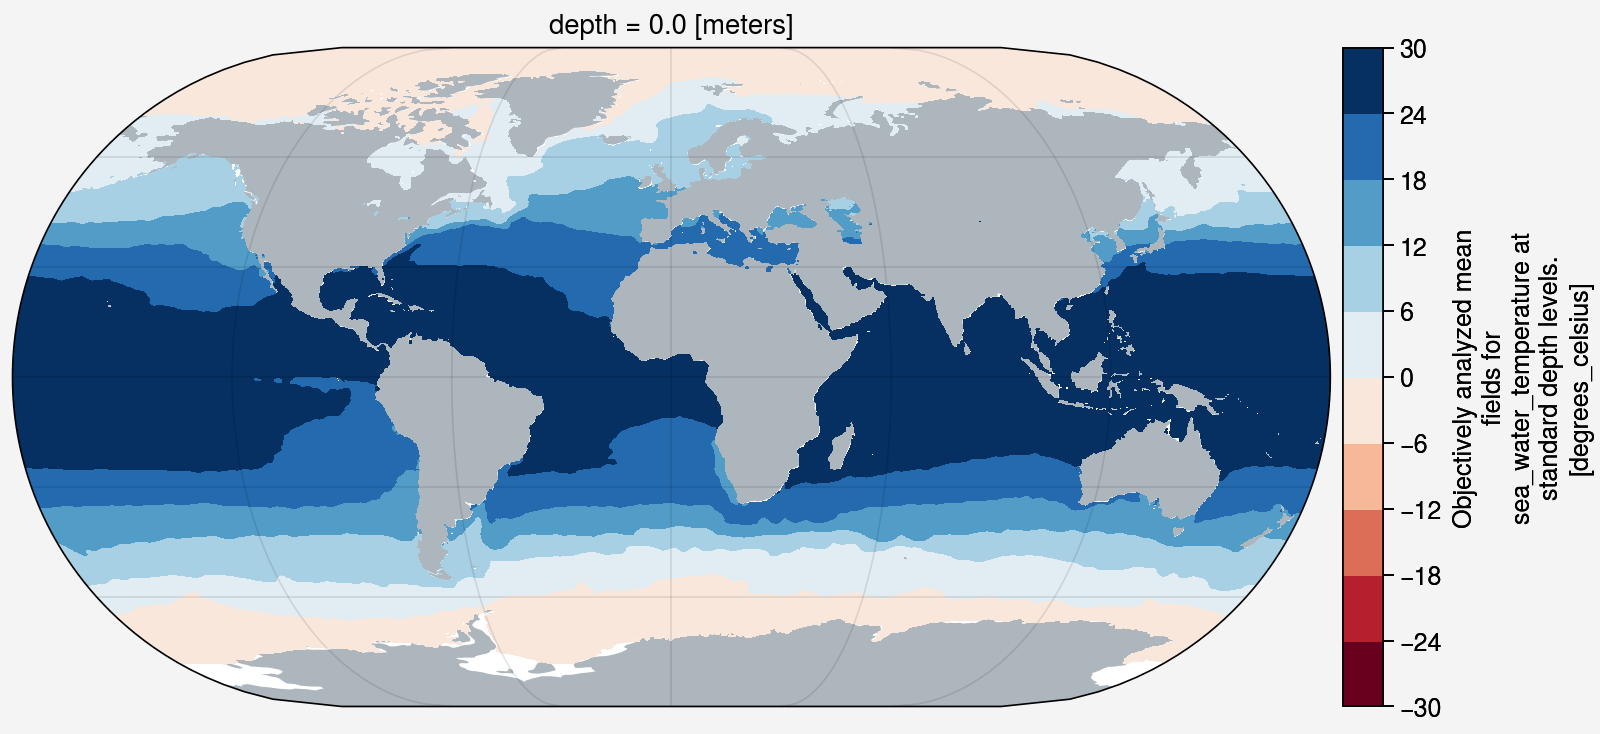

In [32]:


fig, axs = plot.subplots(proj='eck3',width=8)
ax = axs[0]
ax.format(
    land=True,landcolor='gray5',landzorder=0,
    # lonlim=(-90,-60),latlim=(-30,-60)
)

T_da.isel(depth=0).plot(ax=ax,cmap='rdbu')


plot_lat = plot_data['Latitude']
plot_lon = plot_data['Longitude']
ax = axs[0]
ax.scatter(plot_lon,plot_lat,c=plot_data['SST_nearest'],mec='k',
           cmap='rdbu')



In [33]:
combined_df_raw['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    combined_df_raw['lowAbundanceFlag'] = combined_df_raw['lowAbundanceFlag'] | (combined_df_raw[feature]<0.001)
combined_df_raw

coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index
QC_traditional = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
    & (abs(combined_df_raw['deltaRI']) < 0.5)
)

combined_df_raw['QCflag_manual'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual'] = QC_traditional[coretop_idx]

######################################################

QC_traditional_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
    & ((abs(combined_df_raw['deltaRI']) < 0.5) | (combined_df_raw['deltaRI'].isna()))
)

combined_df_raw['QCflag_manual_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_skipna'] = QC_traditional_skipna[coretop_idx]

#######################################################

QC_traditional2 = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
)

combined_df_raw['QCflag_manual_noDRI'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI'] = QC_traditional2[coretop_idx]

#######################################################

QC_traditional2_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
)

combined_df_raw['QCflag_manual_noDRI_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI_skipna'] = QC_traditional2_skipna[coretop_idx]

combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,0.60,2.34,...,0.60,0.06,13.18,2025.00,Coretop,False,True,True,True,True
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,0.60,2.57,...,0.67,0.05,4.88,2025.00,Coretop,False,True,True,True,True
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,0.62,2.50,...,0.65,0.05,4.41,2025.00,Coretop,False,True,True,True,True
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,0.61,2.43,...,0.63,0.07,6.87,2025.00,Coretop,False,True,True,True,True
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,0.59,2.25,...,0.58,0.06,8.43,2025.00,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,0.45,2.77,...,0.73,0.02,2.63,2007.00,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,0.68,2.63,...,0.67,0.07,3.55,2007.00,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,0.61,3.24,...,0.86,0.02,2.32,2007.00,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,0.81,3.60,...,0.94,0.03,2.40,2007.00,Mesocosm,False,True,True,True,True


In [34]:
fpath = fr'{local_github_path}/data/spreadsheets'
combined_df_raw.to_csv(os.path.join(fpath, 'combined_coretop_culture_mesocosm_rev20260210.csv'), index=False)

## 2.5 PhanTEX

In [35]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'

PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,GDGT3,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI
0,NaN,A39,NaN,NaN,94.40,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
1,NaN,A39,NaN,NaN,94.30,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
2,NaN,A39,NaN,NaN,94.20,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
3,NaN,A39,NaN,NaN,94.00,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
4,NaN,A39,NaN,NaN,91.60,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14086,NaN,Mid-Waipara River,NaN,NaN,NaN,70.42,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14087,NaN,Mid-Waipara River,NaN,NaN,NaN,64.81,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14088,NaN,Mid-Waipara River,NaN,NaN,NaN,62.23,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14089,NaN,Mid-Waipara River,NaN,NaN,NaN,58.31,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN


In [36]:
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df = PhanTEX_df.dropna(subset=features).reset_index(drop=True)
PhanTEX_df['ringIndex'] = np.sum([ringNumbers_dict_zhang16.get(feat)*PhanTEX_df[feat] for feat in features],axis=0)/PhanTEX_df[features].sum(axis=1)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex']/4
PhanTEX_df['inv_fGDGT0'] = 1 - PhanTEX_df['fGDGT_0']
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']
PhanTEX_df['ZeroOverZeroCren'] = PhanTEX_df['fGDGT_0'] / (PhanTEX_df['fGDGT_0'] + PhanTEX_df['fGDGT_cren'])
PhanTEX_df.columns

Index(['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth',
       'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age',
       'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'TEX86',
       'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2',
       'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn',
       'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c',
       'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'fGDGT_0',
       'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
       'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI',
       'ringIndex', 'scaledRI', 'inv_fGDGT0', 'gdgt23ratio',
       'ZeroOverZeroCren'],
      dtype='object')

In [37]:
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,match_lon_04deg,SST,t_sf2tc_avg,no3_sf2tc_avg,lowAbundanceFlag,inv_fGDGT0,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,-86.88,23.41,22.52,5.32,False,0.67,True,True,True,True
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,-81.38,22.39,21.32,4.97,False,0.72,True,True,True,True
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,-81.12,23.42,22.09,4.21,False,0.71,True,True,True,True
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,-82.88,22.13,20.62,6.49,False,0.69,True,True,True,True
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,-83.88,22.48,21.17,6.71,False,0.66,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.12,22.76,19.28,1.47,False,0.78,True,True,True,True
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.62,22.58,18.86,1.63,False,0.77,True,True,True,True
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.88,22.67,19.09,1.46,False,0.83,True,True,True,True
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,113.12,22.57,19.13,1.36,False,0.75,True,True,True,True


# 3. Data screening

## 3.1 Low abundance screening

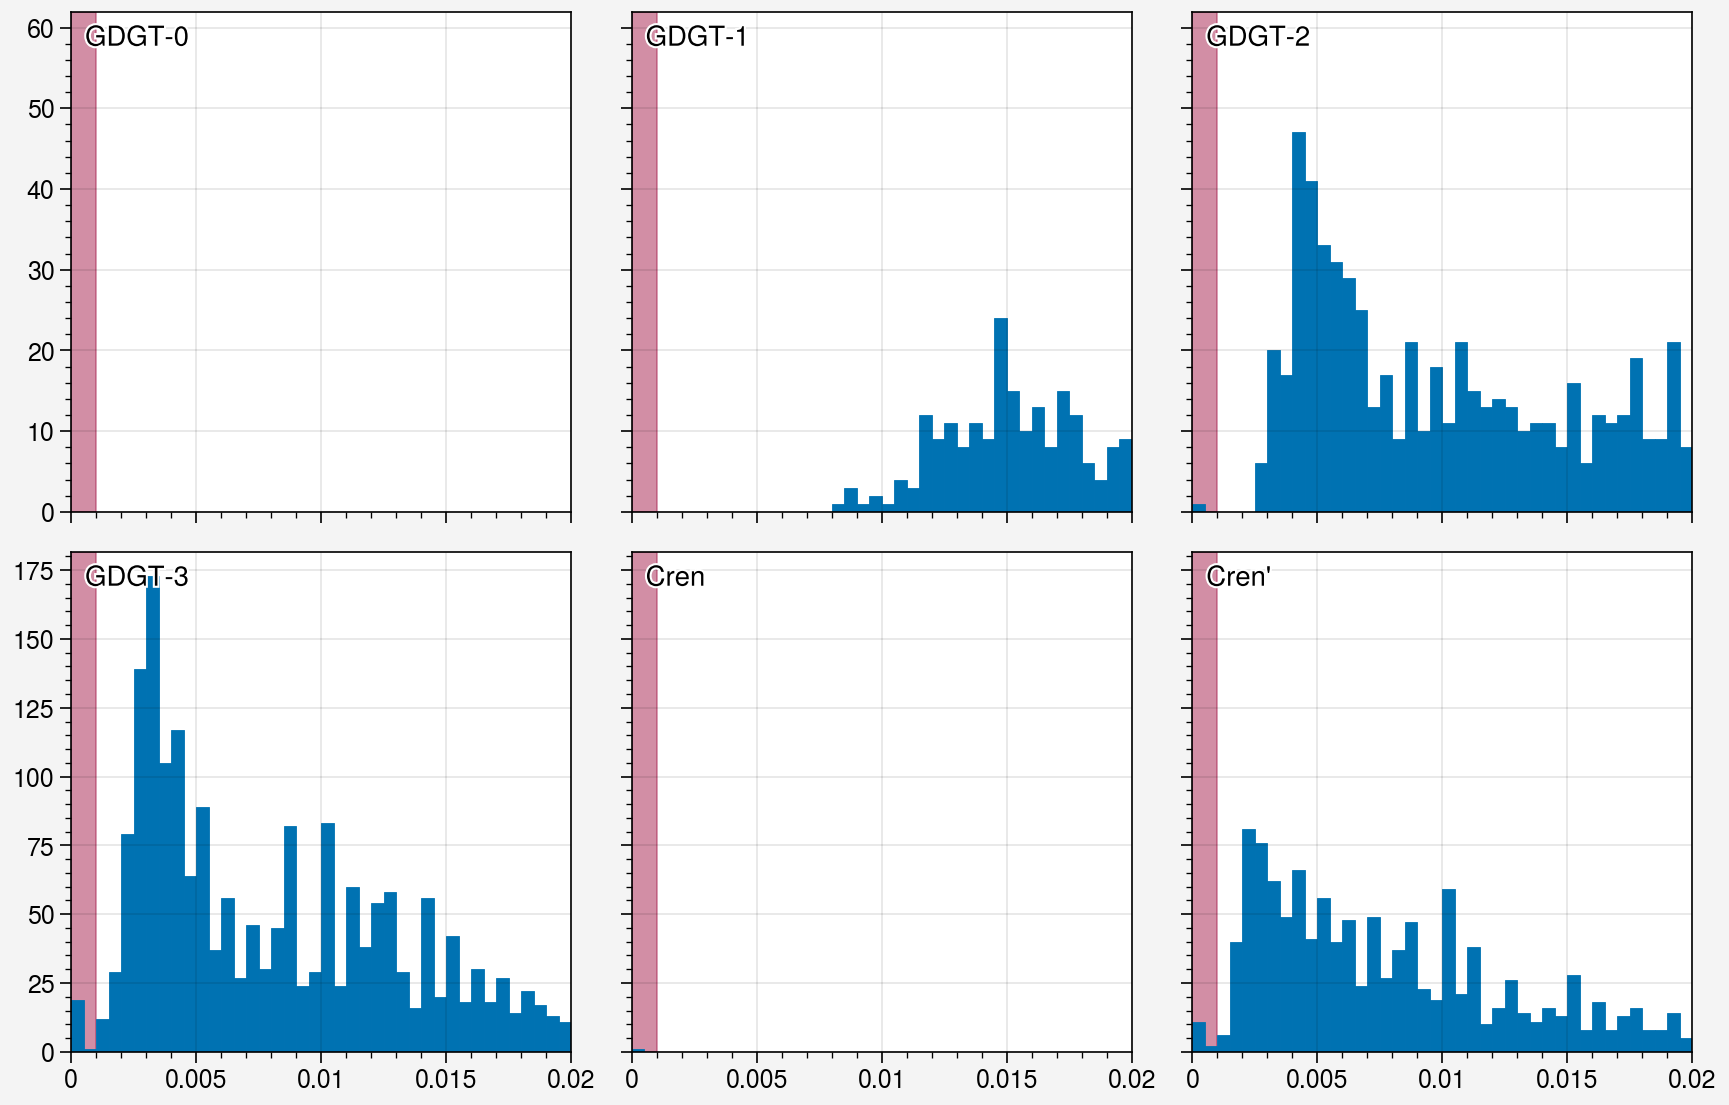

In [38]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

## 3.2 Ring Index as a predictand

In [39]:
combined_df_raw['organism_broadClass4'].unique()

array(['Coretop', 'Non-marine Group 1.1a', 'Marine Group 1.1a',
       'Group 1.1b', 'Mesocosm'], dtype=object)

In [40]:
broadClass4_color_dict = {
    'Coretop':'cyan9',
    'Marine Group 1.1a':'eggplant purple',
    'Non-marine Group 1.1a':'yellow9',
    'Group 1.1b':'dark taupe',
    'Mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

Coretop
 full -- name: Coretop, TEX86 vs SST: spearman rho: 0.871, p-value: 0.000e+00
 full -- name: Coretop, RI vs SST: spearman rho: 0.847, p-value: 0.000e+00
Mesocosm
 full -- name: Mesocosm, TEX86 vs SST: spearman rho: 0.890, p-value: 6.825e-08
 full -- name: Mesocosm, RI vs SST: spearman rho: 0.855, p-value: 8.086e-07
Marine Group 1.1a
 full -- name: Marine Group 1.1a, TEX86 vs SST: spearman rho: 0.463, p-value: 1.741e-04
 full -- name: Marine Group 1.1a, RI vs SST: spearman rho: 0.655, p-value: 1.042e-08
Non-marine Group 1.1a
 full -- name: Non-marine Group 1.1a, TEX86 vs SST: spearman rho: 0.732, p-value: 1.618e-02
 full -- name: Non-marine Group 1.1a, RI vs SST: spearman rho: 0.757, p-value: 1.131e-02
Group 1.1b
 full -- name: Group 1.1b, TEX86 vs SST: spearman rho: 0.725, p-value: 7.662e-03
 full -- name: Group 1.1b, RI vs SST: spearman rho: 0.789, p-value: 2.296e-03
 overall TEX86 vs SST: spearman rho: 0.857, p-value: 0.000e+00
 overall RI vs SST: spearman rho: 0.838, p-value

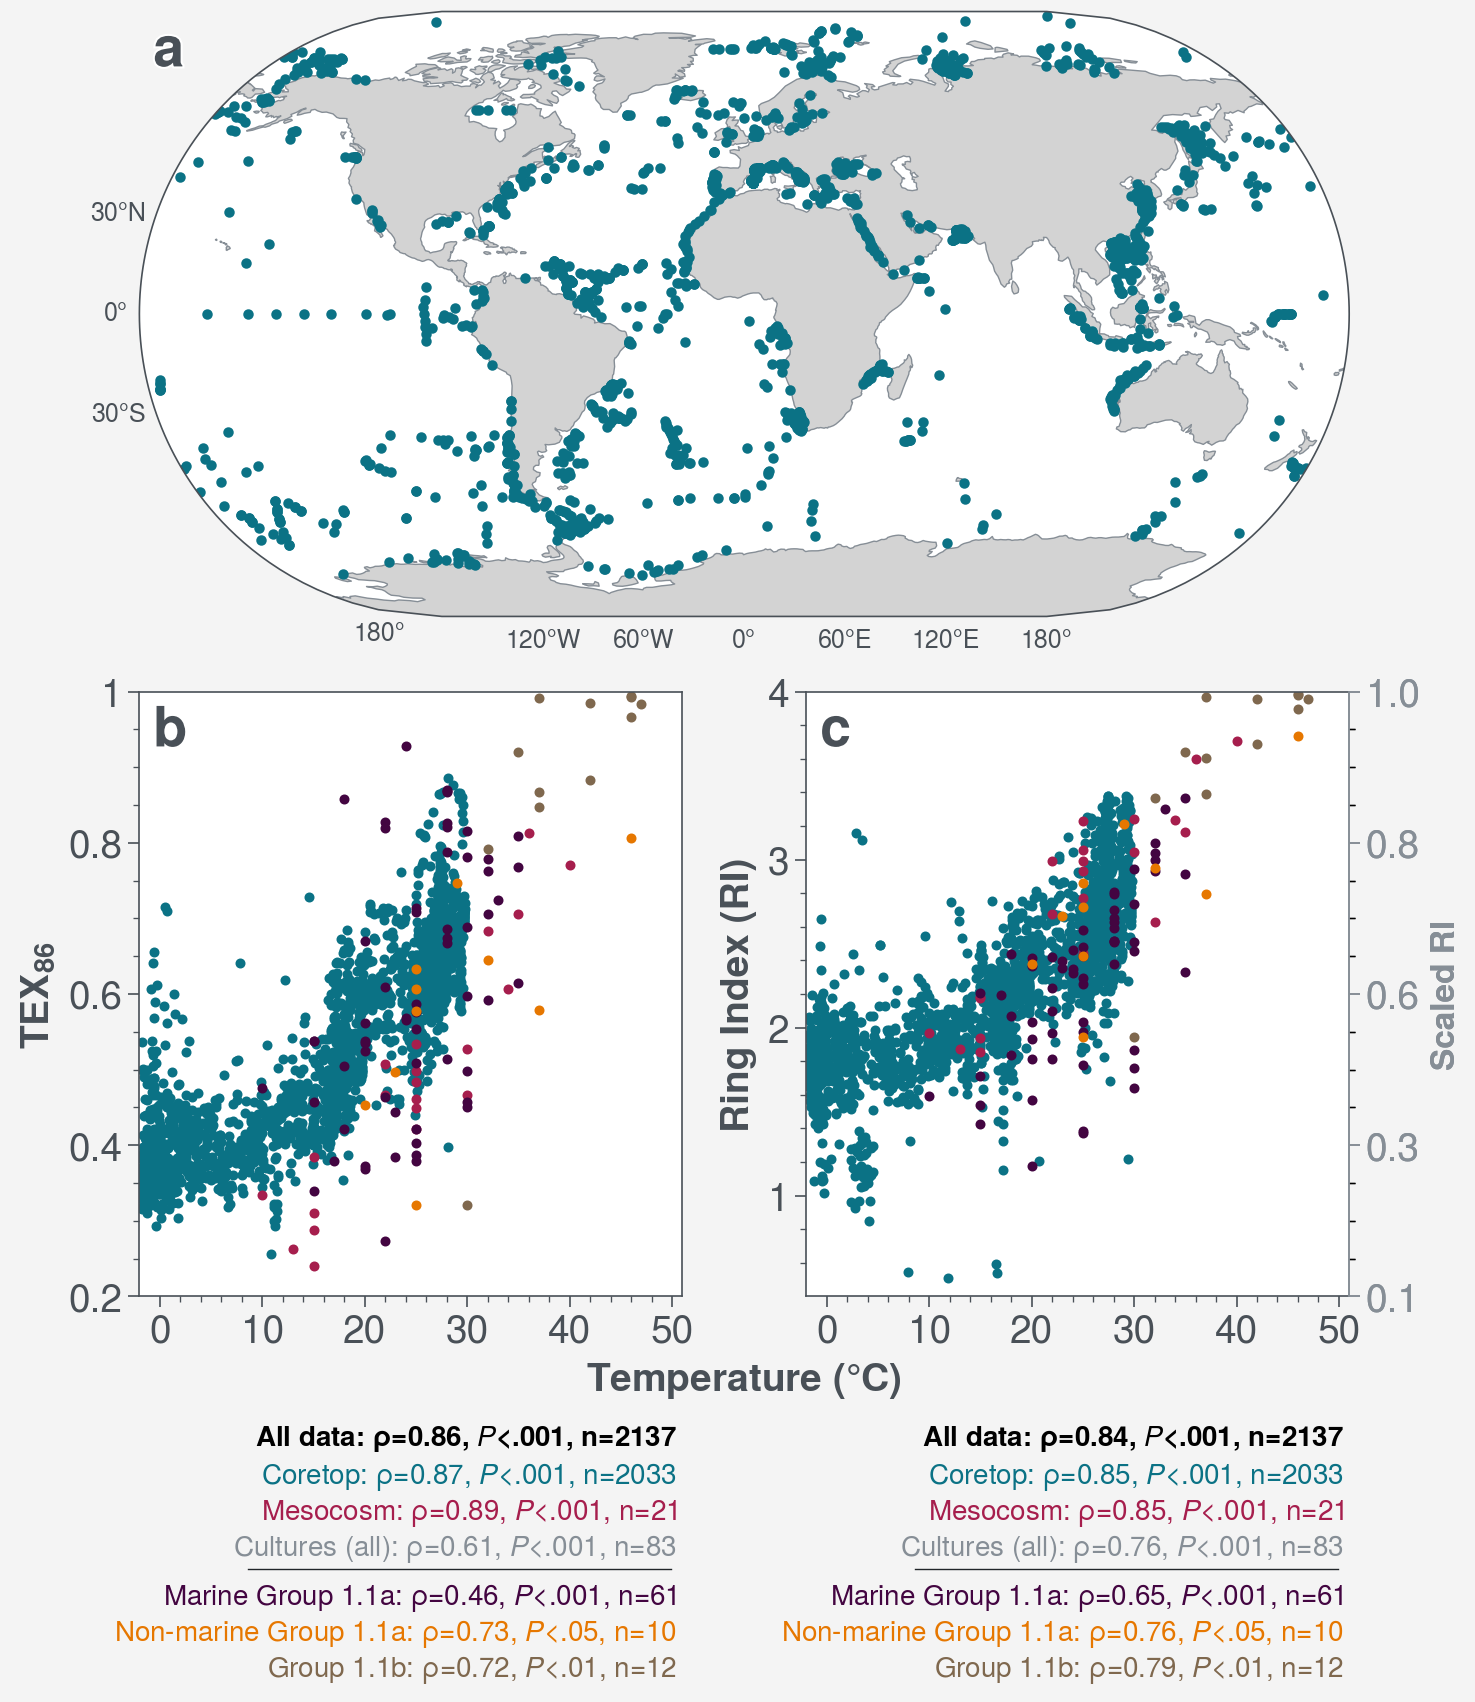

In [41]:
array = [
    [1,1],
    [2,3]
]
fig, axs = plot.subplots(array, width=8, sharey=0, proj={1:'eck3'})

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

ax = axs[0,0]
ax.format(land=True, landcolor='lightgray', landzorder=0,
          coast=True, coastcolor='gray6', coastzorder=1, coastlinewidth=0.5,
          latlabels=True, lonlabels=True,)
plot_lat = plot_data[plot_data['datatype']=='coretop']['Latitude']
plot_lon = plot_data[plot_data['datatype']=='coretop']['Longitude']
sc = ax.scatter(plot_lon, plot_lat, c=datatype_color_dict.get('coretop','gray'),
                s=10, marker='o', label='coretop', zorder=2)

ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'],
                                              categories=ordered_categories,
                                              ordered=True)
grouped = plot_data.groupby('sorted_datatype')
sel_color_dict = broadClass4_color_dict

# --- y-positions below axes (negative = below subplot) ---
# Order: All data, Coretop, Mesocosm, Cultures (all), MG1.1a, NMG1.1a, G1.1b
ypos_below = [-0.06-0.15, -0.12-0.15, -0.18-0.15, -0.24-0.15, 
              -0.32-0.15, -0.38-0.15, -0.44-0.15]
# extra gap before 1.1 subgroups (indices 4,5,6) accounts for longer labels

for i, (name, group) in enumerate(grouped):
    print(name)
    plot_x  = group['SST']
    plot_y  = group['TEX86']
    plot_y2 = group['ringIndex']

    axs[1,0].scatter(plot_x, plot_y,  label=name, m='.', c=sel_color_dict.get(name,'gray'))
    axs[1,1].scatter(plot_x, plot_y2, label=name, m='.', c=sel_color_dict.get(name,'gray'))

    # TEX86 stats
    nonnan_idx = (~plot_x.isna()) & (~plot_y.isna())
    reg_x, reg_y = plot_x[nonnan_idx], plot_y[nonnan_idx]
    rho, pval = spearmanr(reg_x, reg_y)
    print(f' full -- name: {name}, TEX86 vs SST: spearman rho: {rho:.3f}, p-value: {pval:.3e}')

    # RI stats
    nonnan_idx2 = (~plot_x.isna()) & (~plot_y2.isna())
    reg_x2, reg_y2 = plot_x[nonnan_idx2], plot_y2[nonnan_idx2]
    rho2, pval2 = spearmanr(reg_x2, reg_y2)
    print(f' full -- name: {name}, RI vs SST: spearman rho: {rho2:.3f}, p-value: {pval2:.3e}')

    pval_label  = label_pvalues(pval)
    pval_label2 = label_pvalues(pval2)
    label_text  = fr'{name}: $\rho$={rho:.2f}, {pval_label}, n={len(reg_y)}'
    label_text2 = fr'{name}: $\rho$={rho2:.2f}, {pval_label2}, n={len(reg_y2)}'

    ypos_ = ypos_below[i+2] if ('1.1' in name) else ypos_below[i+1]
    axs[1,0].text(0.99, ypos_, label_text,
                  transform=axs[1,0].transAxes, clip_on=False,
                  ha='right', va='top', fontsize=10,
                  color=sel_color_dict.get(name,'gray'))
    axs[1,1].text(0.99, ypos_, label_text2,
                  transform=axs[1,1].transAxes, clip_on=False,
                  ha='right', va='top', fontsize=10,
                  color=sel_color_dict.get(name,'gray'))

# --- All data stats ---
reg_XX  = plot_data['SST']
reg_YY  = plot_data['TEX86']
nonnan_idx = (~reg_XX.isna()) & (~reg_YY.isna())
reg_X, reg_Y = reg_XX[nonnan_idx].values.reshape(-1,1), reg_YY[nonnan_idx].values
rho_all, pval_all = spearmanr(reg_X, reg_Y)
print(f' overall TEX86 vs SST: spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}')
pval_label_all = label_pvalues(pval_all)
label_text_all = fr'All data: $\rho$={rho_all:.2f}, {pval_label_all}, n={len(reg_Y)}'
axs[1,0].text(0.99, ypos_below[0], label_text_all,
              transform=axs[1,0].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, fontweight='bold', color='black')

reg_XX2 = plot_data['SST']
reg_YY2 = plot_data['ringIndex']
nonnan_idx2 = (~reg_XX2.isna()) & (~reg_YY2.isna())
reg_X2, reg_Y2 = reg_XX2[nonnan_idx2].values.reshape(-1,1), reg_YY2[nonnan_idx2].values
rho_all2, pval_all2 = spearmanr(reg_X2, reg_Y2)
print(f' overall RI vs SST: spearman rho: {rho_all2:.3f}, p-value: {pval_all2:.3e}')
pval_label_all2 = label_pvalues(pval_all2)
label_text_all2 = fr'All data: $\rho$={rho_all2:.2f}, {pval_label_all2}, n={len(reg_Y2)}'
axs[1,1].text(0.99, ypos_below[0], label_text_all2,
              transform=axs[1,1].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, fontweight='bold', color='black')

# --- Cultures (all) stats --- placed between Mesocosm and subgroups (index 3)
reg_XX  = plot_data[plot_data['datatype']=='culture']['SST']
reg_YY  = plot_data[plot_data['datatype']=='culture']['TEX86']
nonnan_idx = (~reg_XX.isna()) & (~reg_YY.isna())
reg_X, reg_Y = reg_XX[nonnan_idx].values.reshape(-1,1), reg_YY[nonnan_idx].values
rho_all, pval_all = spearmanr(reg_X, reg_Y)
pval_label_all = label_pvalues(pval_all)
label_text_all = fr'Cultures (all): $\rho$={rho_all:.2f}, {pval_label_all}, n={len(reg_Y)}'
axs[1,0].text(0.99, ypos_below[3], label_text_all,
              transform=axs[1,0].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, color='gray6')

reg_XX2 = plot_data[plot_data['datatype']=='culture']['SST']
reg_YY2 = plot_data[plot_data['datatype']=='culture']['ringIndex']
nonnan_idx2 = (~reg_XX2.isna()) & (~reg_YY2.isna())
reg_X2, reg_Y2 = reg_XX2[nonnan_idx2].values.reshape(-1,1), reg_YY2[nonnan_idx2].values
rho_all2, pval_all2 = spearmanr(reg_X2, reg_Y2)
pval_label_all2 = label_pvalues(pval_all2)
label_text_all2 = fr'Cultures (all): $\rho$={rho_all2:.2f}, {pval_label_all2}, n={len(reg_Y2)}'
axs[1,1].text(0.99, ypos_below[3], label_text_all2,
              transform=axs[1,1].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, color='gray6')

# --- Reference lines ---
axs[1,0].plot([0.2,0.98], [-0.45,-0.45], transform=axs[1,0].transAxes, c='gray9', lw=0.5, clip_on=False)
axs[1,1].plot([0.2,0.98], [-0.45,-0.45], transform=axs[1,1].transAxes, c='gray9', lw=0.5, clip_on=False)

# --- Axis formatting ---
axs[1:,0].format(ylim=(0.2,1), yticks=np.arange(0,1.2,0.2), ylabel=r'TEX$_{86}$')
axs[1:,1].format(ylim=(0.4,4), yticks=np.arange(0,4.1,1),     ylabel='Ring Index (RI)')

ax_right = axs[1,1].twinx()
ax_right.set_ylim(axs[1,1].get_ylim())
yticks = np.linspace(0.4, 4, 5)
ax_right.set_yticks(yticks)
ax_right.set_yticklabels([f'{(tick/4):.1f}' for tick in yticks], fontsize=14)
ax_right.set_ylabel('Scaled RI', fontsize=12, fontweight='bold')
ax_right.yaxis.label.set_color('gray6')
ax_right.tick_params(axis='y', colors='gray6')
ax_right.spines['right'].set_edgecolor('gray6')

axs.format(
    labelsize=14, fontsize=14, labelweight='bold',
    xlim=(-2, 51),   # <-- updated
    grid=False,
    xlabel=r'Temperature ($\degree$C)',
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
    abccolor='gray7', labelcolor='gray7', textcolor='gray7',
    tickcolor='gray7', ticklabelcolor='gray7',
)

for ax in axs:
    ax.spines[:].set_color('gray7')

# Add bottom margin so clipped text is visible
fig.subplots_adjust(bottom=0.18)

fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig3_coretop_TEX86_SST_RI_scatter'
fig.savefig(os.path.join(fpath, fname+'.pdf'), dpi=300, bbox_inches='tight')

overall -- fGDGT_0: spearman rho: -0.895, p-value: 0.000e+00, n=2137
  cultures (all) -- fGDGT_0: spearman rho: -0.771, p-value: 1.606e-17, n=83
  Coretop -- fGDGT_0: spearman rho: -0.897, p-value: 0.000e+00, n=2033
  Mesocosm -- fGDGT_0: spearman rho: -0.882, p-value: 1.214e-07, n=21
  Marine Group 1.1a -- fGDGT_0: spearman rho: -0.679, p-value: 1.869e-09, n=61
  Non-marine Group 1.1a -- fGDGT_0: spearman rho: -0.594, p-value: 7.016e-02, n=10
  Group 1.1b -- fGDGT_0: spearman rho: -0.856, p-value: 3.780e-04, n=12
overall -- fGDGT_1: spearman rho: 0.502, p-value: 4.454e-137, n=2137
  cultures (all) -- fGDGT_1: spearman rho: -0.322, p-value: 3.024e-03, n=83
  Coretop -- fGDGT_1: spearman rho: 0.522, p-value: 1.373e-142, n=2033
  Mesocosm -- fGDGT_1: spearman rho: -0.706, p-value: 3.454e-04, n=21
  Marine Group 1.1a -- fGDGT_1: spearman rho: -0.049, p-value: 7.074e-01, n=61
  Non-marine Group 1.1a -- fGDGT_1: spearman rho: -0.582, p-value: 7.783e-02, n=10
  Group 1.1b -- fGDGT_1: spearma

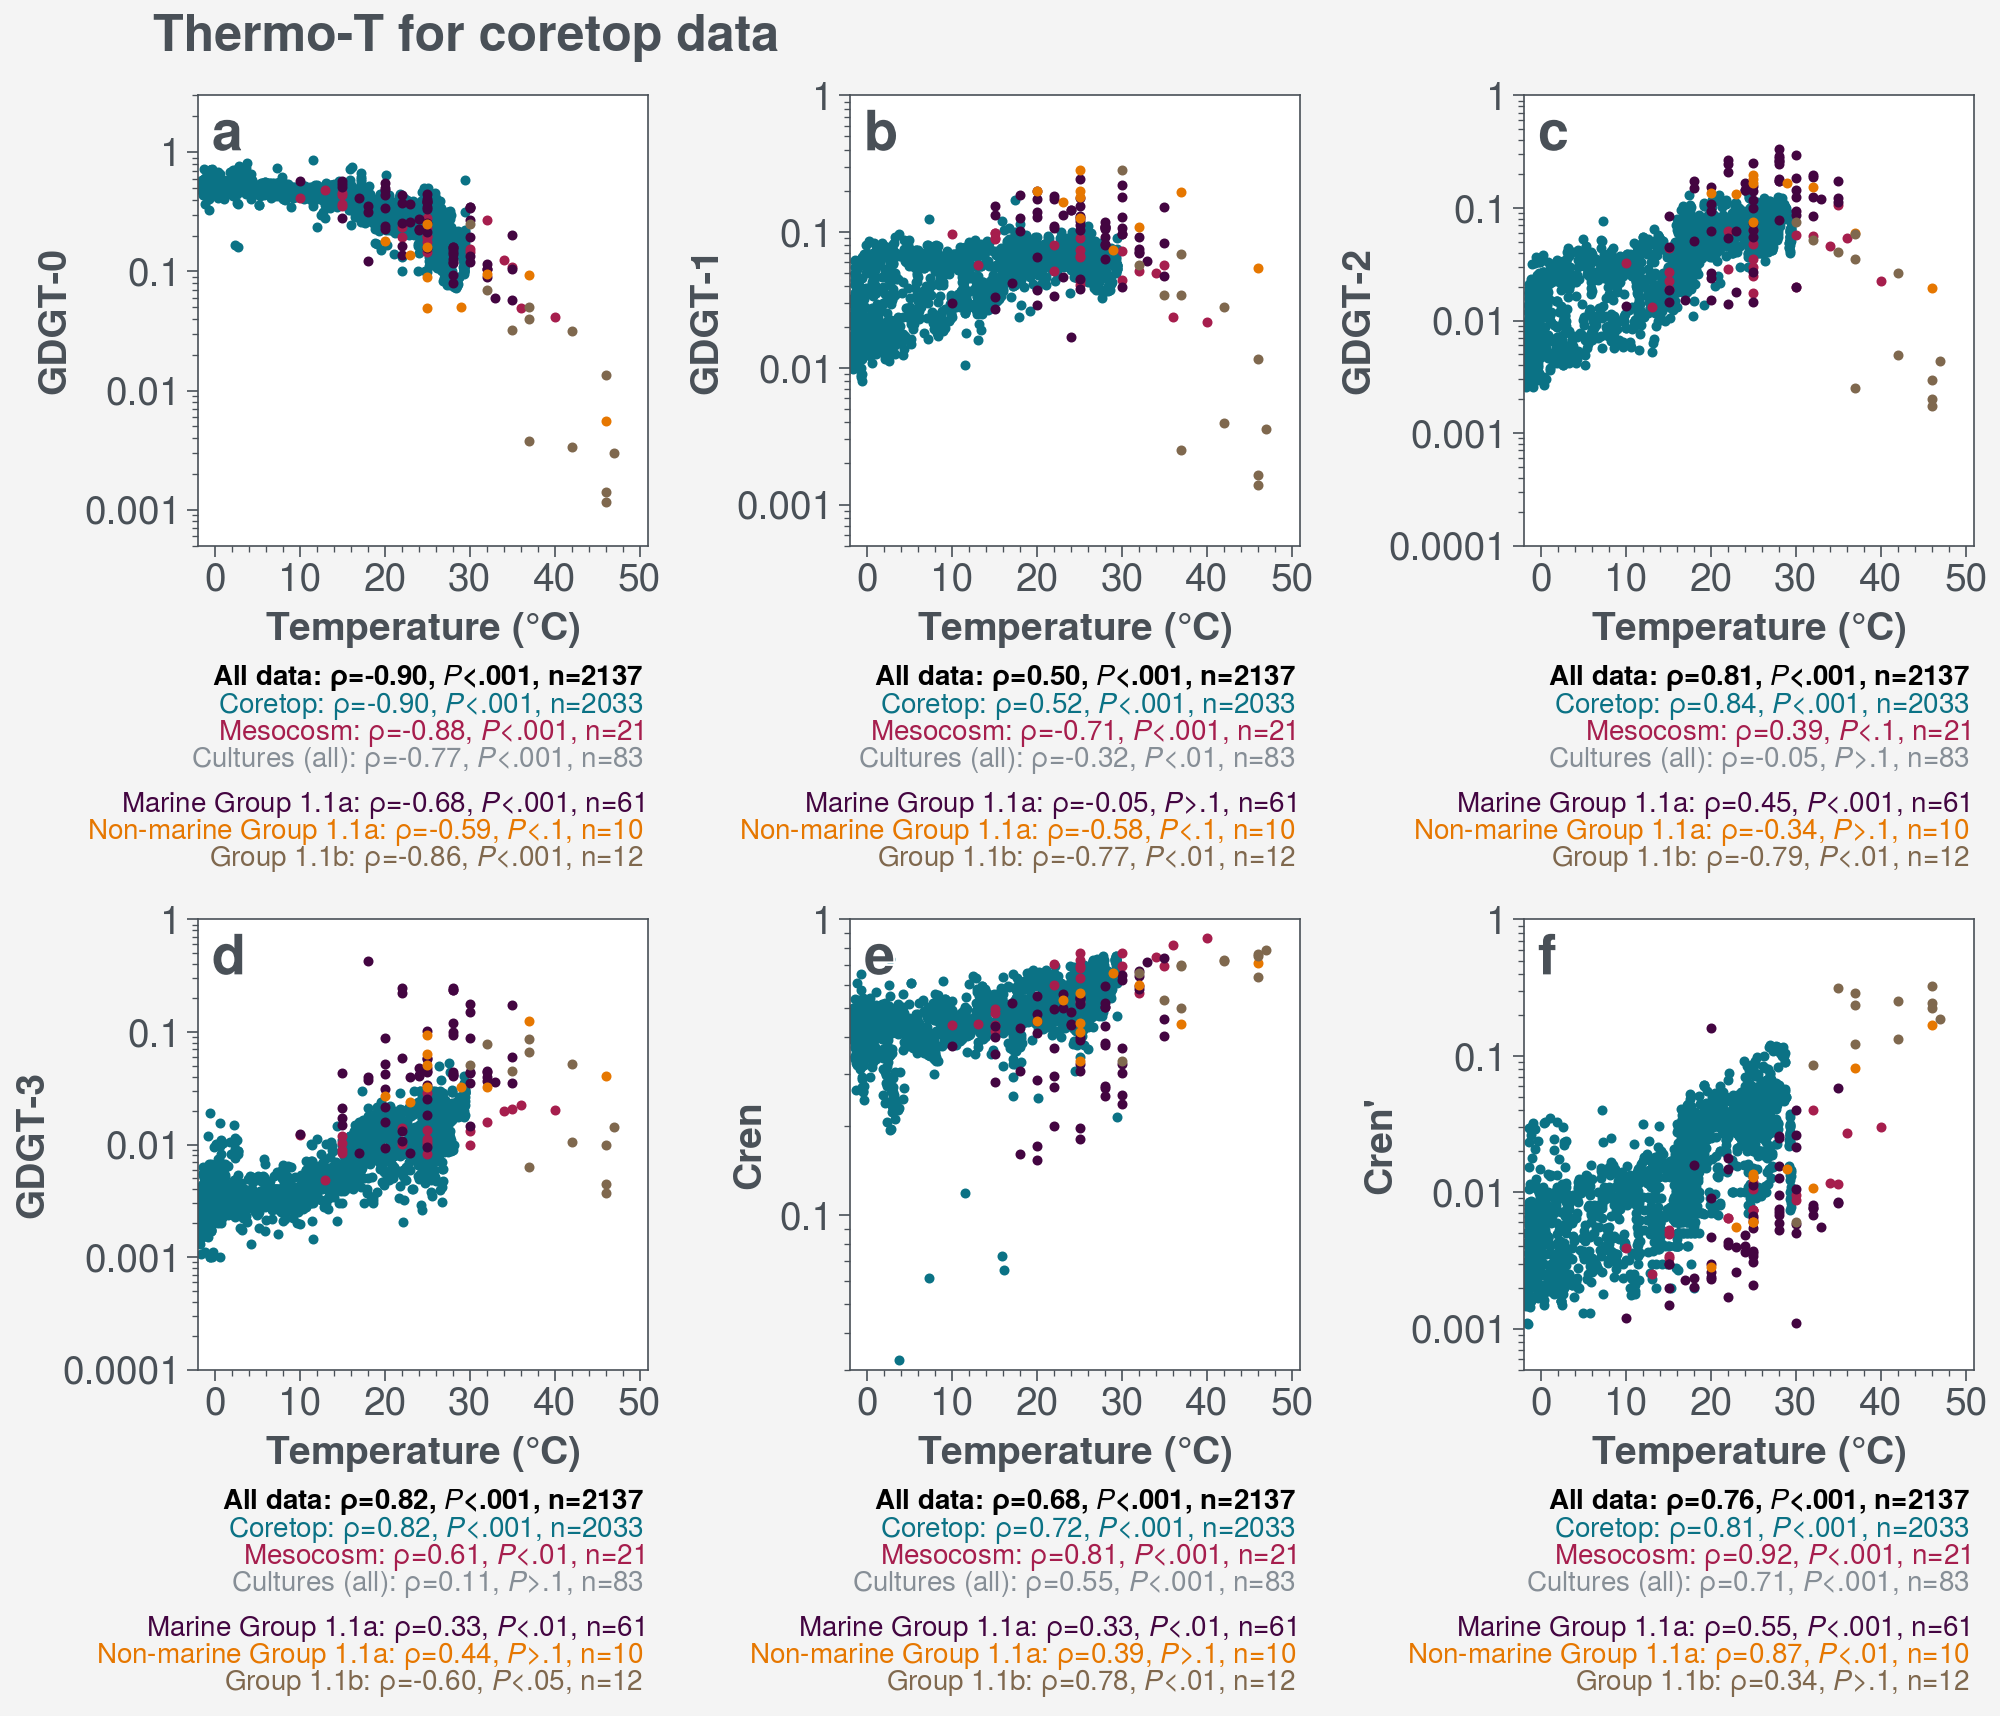

In [42]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]

fig, axs = plot.subplots(ncols=3, nrows=2, width=10, share=False)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag'] == False]
plot_data = plot_data.sort_values(
    'datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})
).reset_index(drop=True)

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a', 'Non-marine Group 1.1a', 'Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(
    plot_data['organism_broadClass4'], categories=ordered_categories, ordered=True
)
grouped = plot_data.groupby('sorted_datatype')
sel_color_dict = broadClass4_color_dict

# --- y-positions below axes (shared across all panels) ---
# Order: [0]=All data, [1]=Coretop, [2]=Mesocosm, [3]=Cultures(all),
#        [4]=Marine Group 1.1a, [5]=Non-marine Group 1.1a, [6]=Group 1.1b
ypos_below = [-0.06-0.2, -0.12-0.2, -0.18-0.2, -0.24-0.2,
              -0.34-0.2, -0.40-0.2, -0.46-0.2]

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]

    # --- Scatter per group ---
    for name, group in grouped:
        ax.scatter(
            group['t_sf2tc_avg'], group[feature],
            label=name, m='.', c=sel_color_dict.get(name, 'gray')
        )

    # --- All data stats ---
    nonnan_idx = (~plot_data['t_sf2tc_avg'].isna()) & (~plot_data[feature].isna())
    reg_x = plot_data.loc[nonnan_idx, 't_sf2tc_avg']
    reg_y = plot_data.loc[nonnan_idx, feature]
    rho_all, pval_all = spearmanr(reg_x, reg_y)
    n_all = len(reg_y)
    print(f'overall -- {feature}: spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}, n={n_all}')
    pval_label_all = label_pvalues(pval_all)
    label_text_all = fr'All data: $\rho$={rho_all:.2f}, {pval_label_all}, n={n_all}'
    ax.text(0.99, ypos_below[0], label_text_all,
            transform=ax.transAxes, clip_on=False,
            ha='right', va='top', fontsize=10, fontweight='bold', color='black')

    # --- Cultures (all) stats ---
    cult_data = plot_data[plot_data['datatype'] == 'culture']
    nonnan_cult = (~cult_data['t_sf2tc_avg'].isna()) & (~cult_data[feature].isna())
    reg_xc = cult_data.loc[nonnan_cult, 't_sf2tc_avg']
    reg_yc = cult_data.loc[nonnan_cult, feature]
    rho_cult, pval_cult = spearmanr(reg_xc, reg_yc)
    n_cult = len(reg_yc)
    print(f'  cultures (all) -- {feature}: spearman rho: {rho_cult:.3f}, p-value: {pval_cult:.3e}, n={n_cult}')
    pval_label_cult = label_pvalues(pval_cult)
    label_text_cult = fr'Cultures (all): $\rho$={rho_cult:.2f}, {pval_label_cult}, n={n_cult}'
    ax.text(0.99, ypos_below[3], label_text_cult,
            transform=ax.transAxes, clip_on=False,
            ha='right', va='top', fontsize=10, color='gray6')

    # --- Per-group stats ---
    for j, (name, group) in enumerate(grouped):
        nonnan_idx = (~group['t_sf2tc_avg'].isna()) & (~group[feature].isna())
        reg_x = group.loc[nonnan_idx, 't_sf2tc_avg']
        reg_y = group.loc[nonnan_idx, feature]
        rho, pval = spearmanr(reg_x, reg_y)
        n_grp = len(reg_y)
        print(f'  {name} -- {feature}: spearman rho: {rho:.3f}, p-value: {pval:.3e}, n={n_grp}')

        pval_label = label_pvalues(pval)
        label_text = fr'{name}: $\rho$={rho:.2f}, {pval_label}, n={n_grp}'
        ypos_ = ypos_below[j+2] if ('1.1' in str(name)) else ypos_below[j+1]
        ax.text(0.99, ypos_, label_text,
                transform=ax.transAxes, clip_on=False,
                ha='right', va='top', fontsize=10,
                color=sel_color_dict.get(name, 'gray'))

axs.format(
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul', abccolor='gray7',
    xlim=(-2, 51),
    grid=False,
    labelsize=14,
    fontsize=14,
    labelweight='bold',
    labelcolor='gray7',
    textcolor='gray7',
    tickcolor='gray7',
    ticklabelcolor='gray7',
    yscale='log'
)

ylims_list   = [(5e-4, 3e0), (5e-4, 1e0), (1e-4, 1e0), (1e-4, 1e0), (3e-2, 1e0), (5e-4, 1e0)]
ylabels_list = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
for ax, ylim, ylabel in zip(axs, ylims_list, ylabels_list):
    ax.set_ylim(ylim)
    ax.set_ylabel(ylabel=ylabel, fontsize=14, fontweight='bold')

for ax in axs:
    ax.spines[:].set_color('gray7')
    ax.format(xlabel=r'Temperature ($\degree$C)')
text = 'Thermo-T for coretop data'
fig.text(-0.1,1.1,text,c='gray7',fontsize=18,fontweight='bold',
              transform=axs[0,0].transAxes)
fig.subplots_adjust(bottom=0.25)

fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS1_coretop_culture_mesocosm_fractinal_GDGTs_vs_Temp.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

## 3.3 Data screening: traditional vs data driven approach

### 3.3.1 prefiltering combined coretop_df

In [43]:
coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index

QC_indices_dict = {
    'BIT':0.5,
    'methaneIndex':0.5,
    'ZeroOverZeroCren':0.67
    }

new_cols = ['BIT_flag','methaneIndex_flag','ZeroOverZeroCren_flag']
for col, threshold in QC_indices_dict.items():
    flag_col = f'{col}_flag'
    combined_df_raw[flag_col] = 'included'
    combined_df_raw.loc[coretop_idx, flag_col] = ['excluded' if row >= threshold else 'included' for row in combined_df_raw.loc[coretop_idx, col]]
    
    
combined_df_raw['QCflag_indices'] = 'included'
for idx in coretop_idx:
    row = combined_df_raw.loc[idx]
    if 'excluded' in [row[col] for col in new_cols]:
        combined_df_raw.at[idx, 'QCflag_indices'] = 'excluded'
combined_df_raw[combined_df_raw['QCflag_indices']=='excluded']


,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna,BIT_flag,methaneIndex_flag,ZeroOverZeroCren_flag,QCflag_indices
44,-22.22,-176.61,-22.12,-176.62,1744.00,24.49,25.21,0.00,0.69,1.88,...,Coretop,False,False,False,False,False,excluded,included,included,excluded
83,-44.15,-75.15,-44.12,-75.12,301.00,11.49,11.83,7.15,0.46,0.51,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
664,38.19,176.70,38.12,176.62,4522.00,15.92,16.48,2.78,0.41,0.59,...,Coretop,False,False,False,False,False,included,excluded,excluded,excluded
665,37.77,176.27,37.88,176.38,3573.00,16.18,16.76,2.68,0.40,0.65,...,Coretop,True,False,False,False,False,included,excluded,excluded,excluded
669,38.89,157.63,38.88,157.62,5535.00,16.14,16.63,2.50,0.43,0.54,...,Coretop,False,False,False,False,False,included,excluded,excluded,excluded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,72.75,-67.02,72.62,-67.12,2373.00,-0.38,0.09,3.06,0.35,1.17,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2018,71.41,-70.89,71.38,-70.88,702.00,0.54,1.15,2.97,0.35,1.31,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2019,69.60,-65.40,69.62,-65.38,267.00,-0.63,-0.63,3.11,0.40,1.20,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2020,69.41,-64.40,69.38,-64.38,1054.00,-0.53,-0.51,3.00,0.32,1.09,...,Coretop,False,False,False,False,False,included,included,excluded,excluded


### 3.3.2 Traditional screening indices

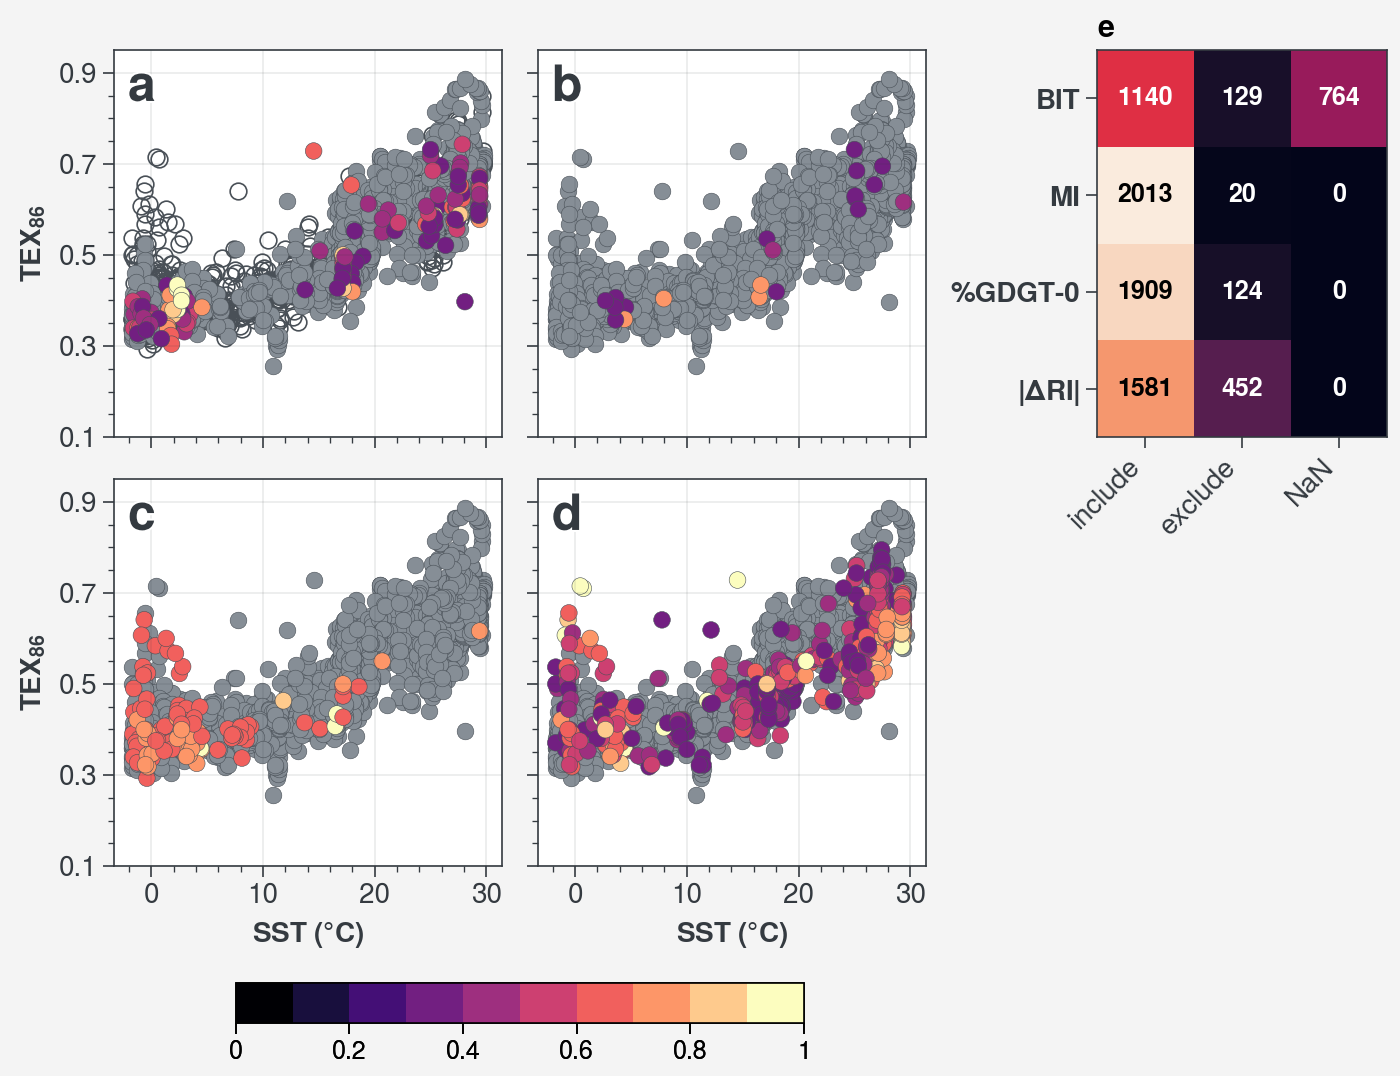

In [44]:
QC_indices = ['BIT','methaneIndex','ZeroOverZeroCren','abs_deltaRI']
QC_thresholds = [0.3,0.3,0.6,0.3]

array = [
    [1,2,5],
    [3,4,0]
]

fig, axs = plot.subplots(array,width=7,
                         wratios=[1,1,0.75],
                         share=0
                         )

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][combined_df_raw['lowAbundanceFlag']==False]
arrays = np.zeros((4,3))


for i, (QC_index, qc_thr) in enumerate(zip(QC_indices, QC_thresholds)):
    good_data = (plot_data[QC_index]<=qc_thr).sum()
    bad_data = (plot_data[QC_index]>qc_thr).sum()
    nan_data = plot_data[QC_index].isna().sum()
    arrays[i,:] = [good_data,bad_data,nan_data]

    good_data_idx = plot_data[QC_index]<=qc_thr
    bad_data_idx = plot_data[QC_index]>qc_thr
    nan_data_idx = plot_data[QC_index].isna()
    
    plot_x = plot_data['SST']
    plot_y = plot_data['TEX86']

    ax = axs[i]
    ax.scatter(plot_x[nan_data_idx],plot_y[nan_data_idx],
               facecolor='none',m='o',mec='gray7',zorder=0)
    ax.scatter(plot_x[good_data_idx],plot_y[good_data_idx],
               m='o',c='gray6',mec='gray7',mew=0.2)
    m = ax.scatter(plot_x[bad_data_idx],plot_y[bad_data_idx],
               m='o',c=plot_data[QC_index][bad_data_idx],
               levels=np.arange(0,1.1,0.1), 
               mec='gray7',mew=0.2,
               cmap='magma')
cbar = fig.colorbar(m,loc='b',col=[1,2],shrink=0.7)

coretop_qc_df = pd.DataFrame(arrays, index=pd.Index(['BIT','MI','%GDGT-0','|$\Delta$RI|']))
axs[0,-1].heatmap(coretop_qc_df,
                  cmap='rocket',labels=True,labels_kw={'weight':'bold'})

axs[0,-1].format(yreverse=True,
           xticklabels=['include','exclude','NaN'],
           xrotation=45,
           yticklabelweight='bold')


axs.format(gridcolor='gray8')

axs[:,:-1].format(xlabel=r'SST ($\degree$C)',
                ylabel=r'TEX$_{86}$',
                yticks=np.arange(0.1,0.95,0.2),
                ylim=(0.1,0.95))
axs[:,1].format(ylabel='',
                yticklabels=[])
axs[0,:-1].format(xlabel='',
                xticklabels=[])

for ax in axs:
    ax.format(tickcolor='gray8',
              ticklabelcolor='gray8',
              labelcolor='gray8',
              labelweight='bold',
              labelsize=10,fontsize=10)
    for spine in ax.spines.values():
        spine.set_color('gray8')

axs[:-1].format(abc=True,abcloc='ul',
                abcsize=18,
                abccolor='gray8')

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS2_Traditional_QC_indices.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

Median methaneIndex by organism_broadClass4:
organism_broadClass4
Coretop                 0.18
Group 1.1b              0.07
Marine Group 1.1a       0.39
Mesocosm                0.16
Non-marine Group 1.1a   0.40
Name: methaneIndex, dtype: float64
Median ZeroOverZeroCren by organism_broadClass4:
organism_broadClass4
Coretop                 0.43
Group 1.1b              0.03
Marine Group 1.1a       0.36
Mesocosm                0.23
Non-marine Group 1.1a   0.16
Name: ZeroOverZeroCren, dtype: float64
Median deltaRI by organism_broadClass4:
organism_broadClass4
Coretop                 -0.07
Group 1.1b               0.05
Marine Group 1.1a        0.19
Mesocosm                -0.62
Non-marine Group 1.1a   -0.44
Name: deltaRI, dtype: float64


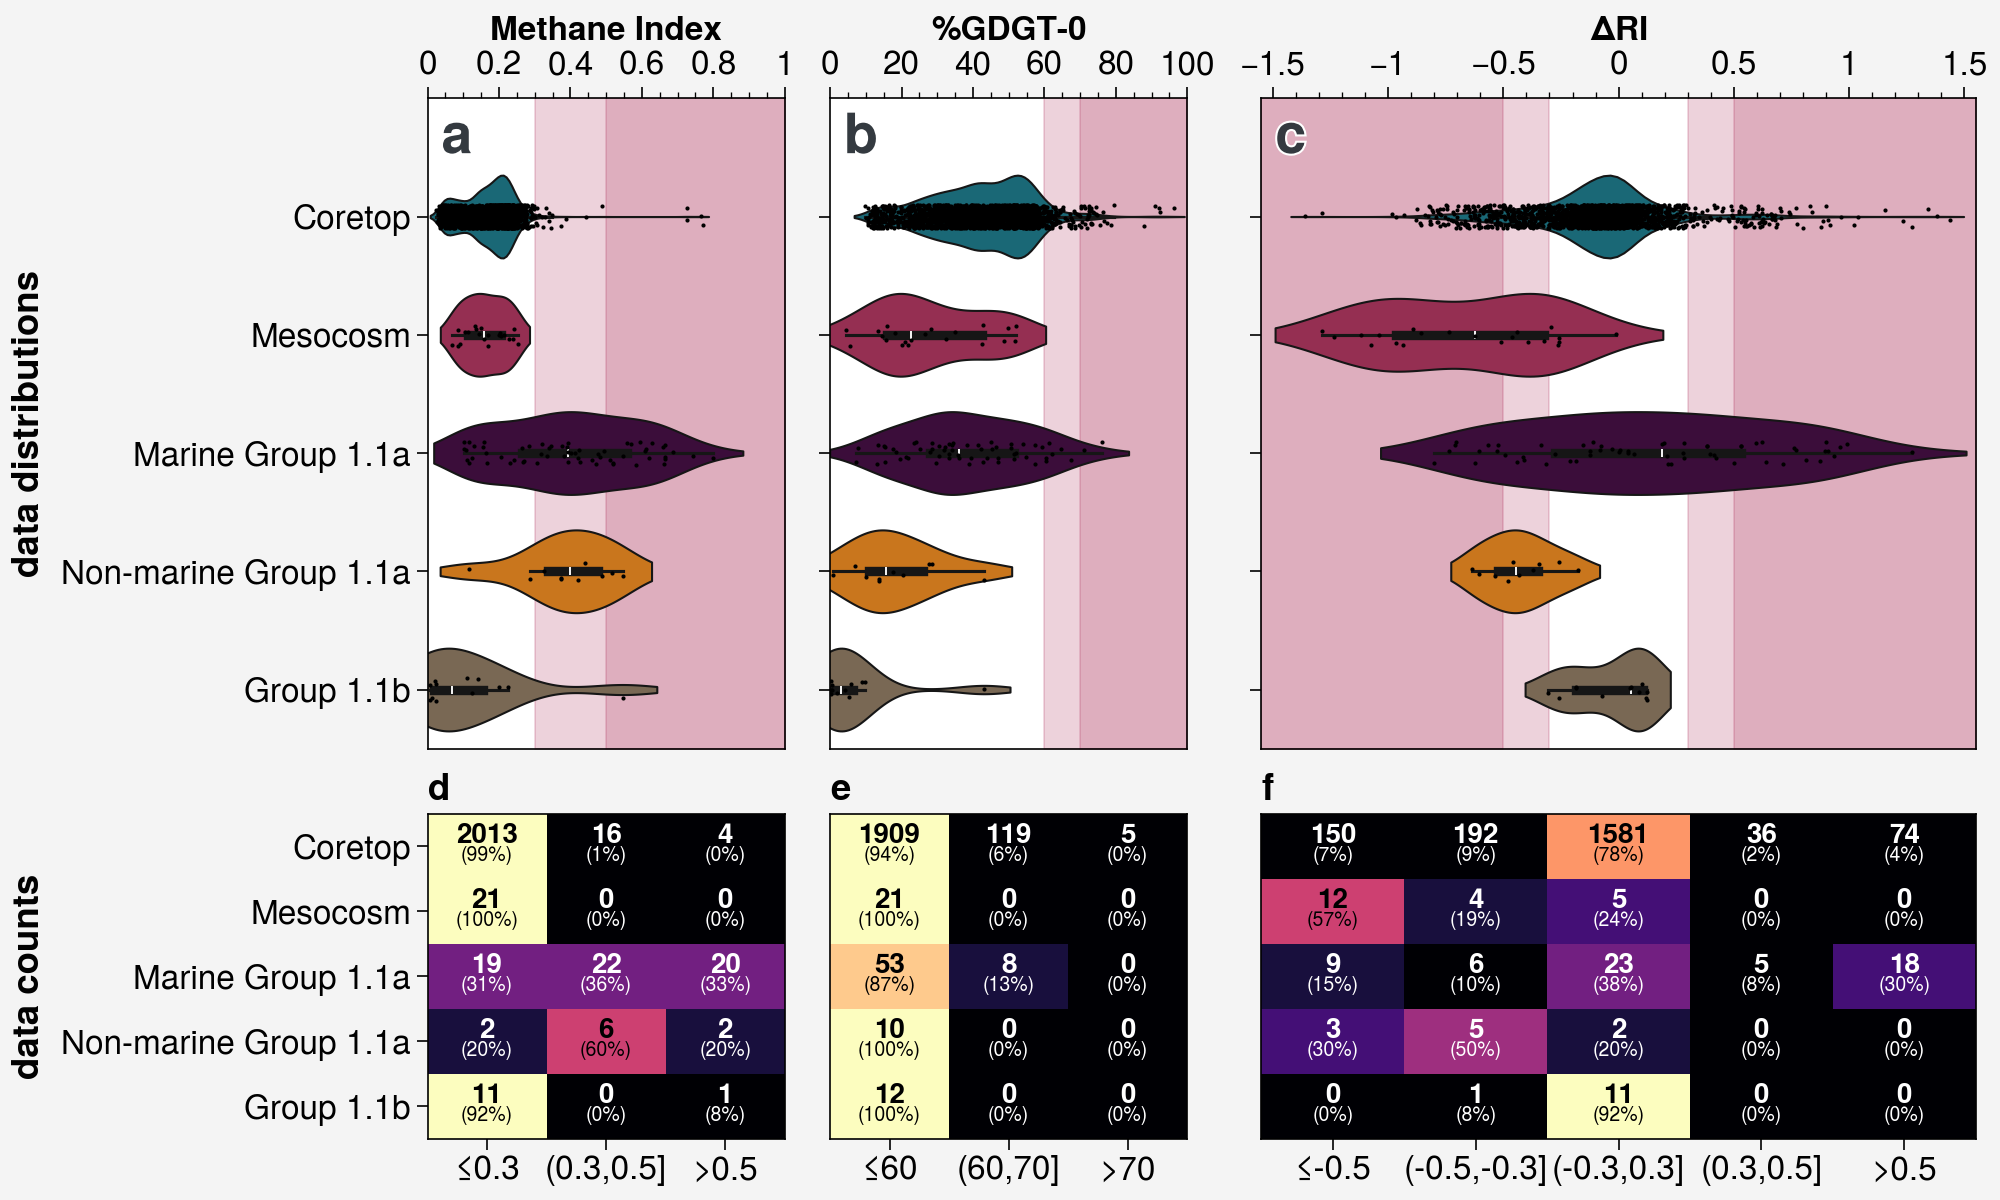

In [45]:
x_params = ['methaneIndex','ZeroOverZeroCren','deltaRI']
x_labels = ['Methane Index','%GDGT-0','$\Delta$RI']

fig, axs = plot.subplots(figsize=(10,6),
                         ncols=len(x_params),nrows=2,
                         share=0, 
                         wratios=[1,1,2],
                         hratios=[1,0.5])

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
# plot_data = plot_data[plot_data['TEXRI_mahalDist_outliers_manual']==False]

ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'], 
                                              categories=ordered_categories, ordered=True)
plot_data['binned_publicationYear'] = pd.cut(plot_data['publicationYear'], bins=[2000,2014,2030], labels=['pre2014','post2014'])
plot_data = plot_data.sort_values('sorted_datatype', ascending=False)

for i, x_param in enumerate(x_params):
    ax = axs[0,i]
    sns.violinplot(
        data=plot_data,
        y='organism_broadClass4',
        x=x_param,
        hue='organism_broadClass4',
        ax=ax,
        palette=broadClass4_color_dict,
        legend=False,
        density_norm='width',
        width=0.7,
        cut=1
    )
    
    print(f'Median {x_param} by organism_broadClass4:')
    print(plot_data.groupby('organism_broadClass4')[x_param].median())
    
    sns.stripplot(
        data=plot_data,
        y='organism_broadClass4',
        x=x_param,
        ax=ax,
        legend=False,
        color='k',
        size=1.5,
    )
    
    ax.format(
        xlabel=x_labels[i],
    )
    

#### cosmetics
axs[0].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5, x2=1, color='pink9', alpha=0.2, zorder=0)

axs[1].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
    xticklabels=[f'{x*100:.0f}' for x in np.arange(0,1.1,0.2)]
)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.6, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.7, x2=1, color='pink9', alpha=0.2, zorder=0)



axs[2].format(
    ytickminor=False,
    grid=True,
    xlim=(-1.55,1.55),
)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.5, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.3, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)

axs[0,:].format(ylabel='',
           ylim=(-0.5, len(axs[0].get_yticks())),
           yticklabels=ordered_categories[::-1],)

### heatmap
for i, x_param in enumerate(x_params):
    plot_heatmap_data = plot_data.copy()
    plot_heatmap_data['x_bin'] = pd.cut(plot_heatmap_data[x_param], 
                                        bins=[-np.inf,0.3,0.5,np.inf] if x_param=='methaneIndex' else
                                        [-np.inf,0.6,0.8,np.inf] if x_param=='ZeroOverZeroCren' else
                                        [-np.inf,-0.5,-0.3,0.3,0.5,np.inf])
    heatmap_df = plot_heatmap_data.pivot_table(index='organism_broadClass4',
                                                columns='x_bin',
                                                values='TEX86',
                                                aggfunc='count',
                                                sort=False).reset_index()
    heatmap_df['organism_broadClass4'] = pd.Categorical(heatmap_df['organism_broadClass4'],
                                                       categories=ordered_categories,
                                                       ordered=True)

    sorted_heatmap_df = heatmap_df.sort_values('organism_broadClass4')[::-1]
    normalized_heatmap_df = sorted_heatmap_df.set_index('organism_broadClass4').div(
        sorted_heatmap_df.set_index('organism_broadClass4').sum(axis=1), axis=0
    )
    
    count_data = sorted_heatmap_df.set_index('organism_broadClass4')
    
    ax = axs[1,i]
    
    # Use pcolormesh instead of imshow - better PDF rendering
    im = ax.pcolormesh(
        np.arange(len(normalized_heatmap_df.columns) + 1),
        np.arange(len(normalized_heatmap_df) + 1),
        normalized_heatmap_df.values,
        cmap='magma',
        vmin=0,
        vmax=1,
        edgecolors='white',
        linewidth=0.,
        shading='flat'
    )
    
    # Add text annotations with counts and percentages
    for row in range(len(normalized_heatmap_df)):
        for col in range(len(normalized_heatmap_df.columns)):
            proportion = normalized_heatmap_df.values[row, col]
            count = count_data.values[row, col]
            
            text_color = 'black' if proportion > 0.5 else 'white'
            
            # Count text (larger)
            ax.text(col + 0.5, row + 0.65, f'{int(count)}',
                ha='center', va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color)
            
            # Percentage text (smaller)
            ax.text(col + 0.5, row + 0.35, f'({proportion*100:.0f}%)',
                ha='center', va='center',
                fontsize=7,
                color=text_color)
    
    # Format axes
    if i == 0:  # Only first column gets y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=np.arange(len(normalized_heatmap_df)) + 0.5,
            yticklabels=[str(x) for x in normalized_heatmap_df.index],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            yticklabelsize=8,
            xticklabelsize=8,
            xrotation=0,
        )
    else:  # Other columns: no y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=[],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            xticklabelsize=8,
            xrotation=0,
            xlabel='',
            ylabel=''
        )
    
    # # Add colorbar only to last panel
    # if i == len(x_params) - 1:
    #     fig.colorbar(im, ax=ax, label='Proportion', loc='r', shrink=0.8)

# axs[1,:].axis('off')
axs.format(labelsize=12,fontsize=12,labelweight='bold',
           rowlabels=['data distributions','data counts'],
           grid=False)
axs[0,1:].format(ylabel='', yticklabels=[])

plot.rc['abc']=True
axs[0,:].format(abc=True, abcloc='ul', abcsize=20, abccolor='gray8',
                xtickloc='top')

plot.rc['abc']=False
axs[1,:].format(abc=False,xtickminor=False,ytickminor=False,grid=False)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig4_culture_mesocosm_coretop_QC_violin_heatmap.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

### 3.3.3 Determining confidence level for the Mahalanobis ellipse

In [46]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.7, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


collect_stats_df = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI'], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data['TEX86']
    reg_y = filtered_data['scaledRI']
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df.at[i*4 + 0, 'pval'] = pval
    collect_stats_df.at[i*4 + 0, 'rho'] = rho
    collect_stats_df.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data['TEX86']
        reg_y = filtered_data['scaledRI']
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.70,all,1.55,0.00,0.87,1501.00,636.00
1,0.70,coretop,1.55,0.00,0.88,1472.00,561.00
2,0.70,culture,1.55,0.00,0.72,26.00,57.00
3,0.70,mesocosm,1.55,0.67,0.50,3.00,18.00
4,0.71,all,1.57,0.00,0.87,1521.00,616.00
...,...,...,...,...,...,...,...
115,0.98,mesocosm,2.80,0.00,0.87,15.00,6.00
116,0.99,all,3.03,0.00,0.86,2075.00,62.00
117,0.99,coretop,3.03,0.00,0.87,2000.00,33.00
118,0.99,culture,3.03,0.00,0.74,58.00,25.00


In [47]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.7, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


collect_stats_df_manual = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI'], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers_manual(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data['TEX86']
    reg_y = filtered_data['scaledRI']
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df_manual.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df_manual.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df_manual.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df_manual.at[i*4 + 0, 'pval'] = pval
    collect_stats_df_manual.at[i*4 + 0, 'rho'] = rho
    collect_stats_df_manual.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df_manual.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers_manual(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data['TEX86']
        reg_y = filtered_data['scaledRI']
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df_manual.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df_manual.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df_manual.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df_manual.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df_manual.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df_manual.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df_manual.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df_manual

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.70,all,1.55,0.00,0.89,1568.00,569.00
1,0.70,coretop,1.55,0.00,0.89,1524.00,509.00
2,0.70,culture,1.55,0.00,0.92,39.00,44.00
3,0.70,mesocosm,1.55,0.10,0.80,5.00,16.00
4,0.71,all,1.57,0.00,0.89,1588.00,549.00
...,...,...,...,...,...,...,...
115,0.98,mesocosm,2.80,0.00,0.89,16.00,5.00
116,0.99,all,3.03,0.00,0.86,2085.00,52.00
117,0.99,coretop,3.03,0.00,0.87,2002.00,31.00
118,0.99,culture,3.03,0.00,0.82,66.00,17.00


In [48]:
combined_df_raw.columns

Index(['Latitude', 'Longitude', 'match_lat_04deg', 'match_lon_04deg',
       'modernWaterDepth', 't_sf2tc_avg', 'SST', 'no3_sf2tc_avg', 'TEX86',
       'ringIndex', 'scaledRI', 'inv_fGDGT0', 'BIT', 'methaneIndex',
       'OPTiMAL_Dnearest', 'OPTiMAL_SST', 'regionName', 'reference_name',
       'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren',
       'fGDGT_cren_prime', 'datatype', 'Strains', 'organism_commonName',
       'organism_broadClass', 'organism_broadClass2', 'organism_broadClass3',
       'TEXRI_Zhang16', 'deltaRI', 'abs_deltaRI', 'ZeroOverZeroCren',
       'CrenOverZeroCren', 'CrenPrimeOverCren', 'gdgt23ratio',
       'publicationYear', 'organism_broadClass4', 'lowAbundanceFlag',
       'QCflag_manual', 'QCflag_manual_skipna', 'QCflag_manual_noDRI',
       'QCflag_manual_noDRI_skipna', 'BIT_flag', 'methaneIndex_flag',
       'ZeroOverZeroCren_flag', 'QCflag_indices'],
      dtype='object')

In [49]:
broadClass4_color_dict2 = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan4',
    'Marine Group 1.1a':'eggplant purple',
    'Non-marine Group 1.1a':'yellow9',
    'Group 1.1b':'dark taupe',
    'Mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

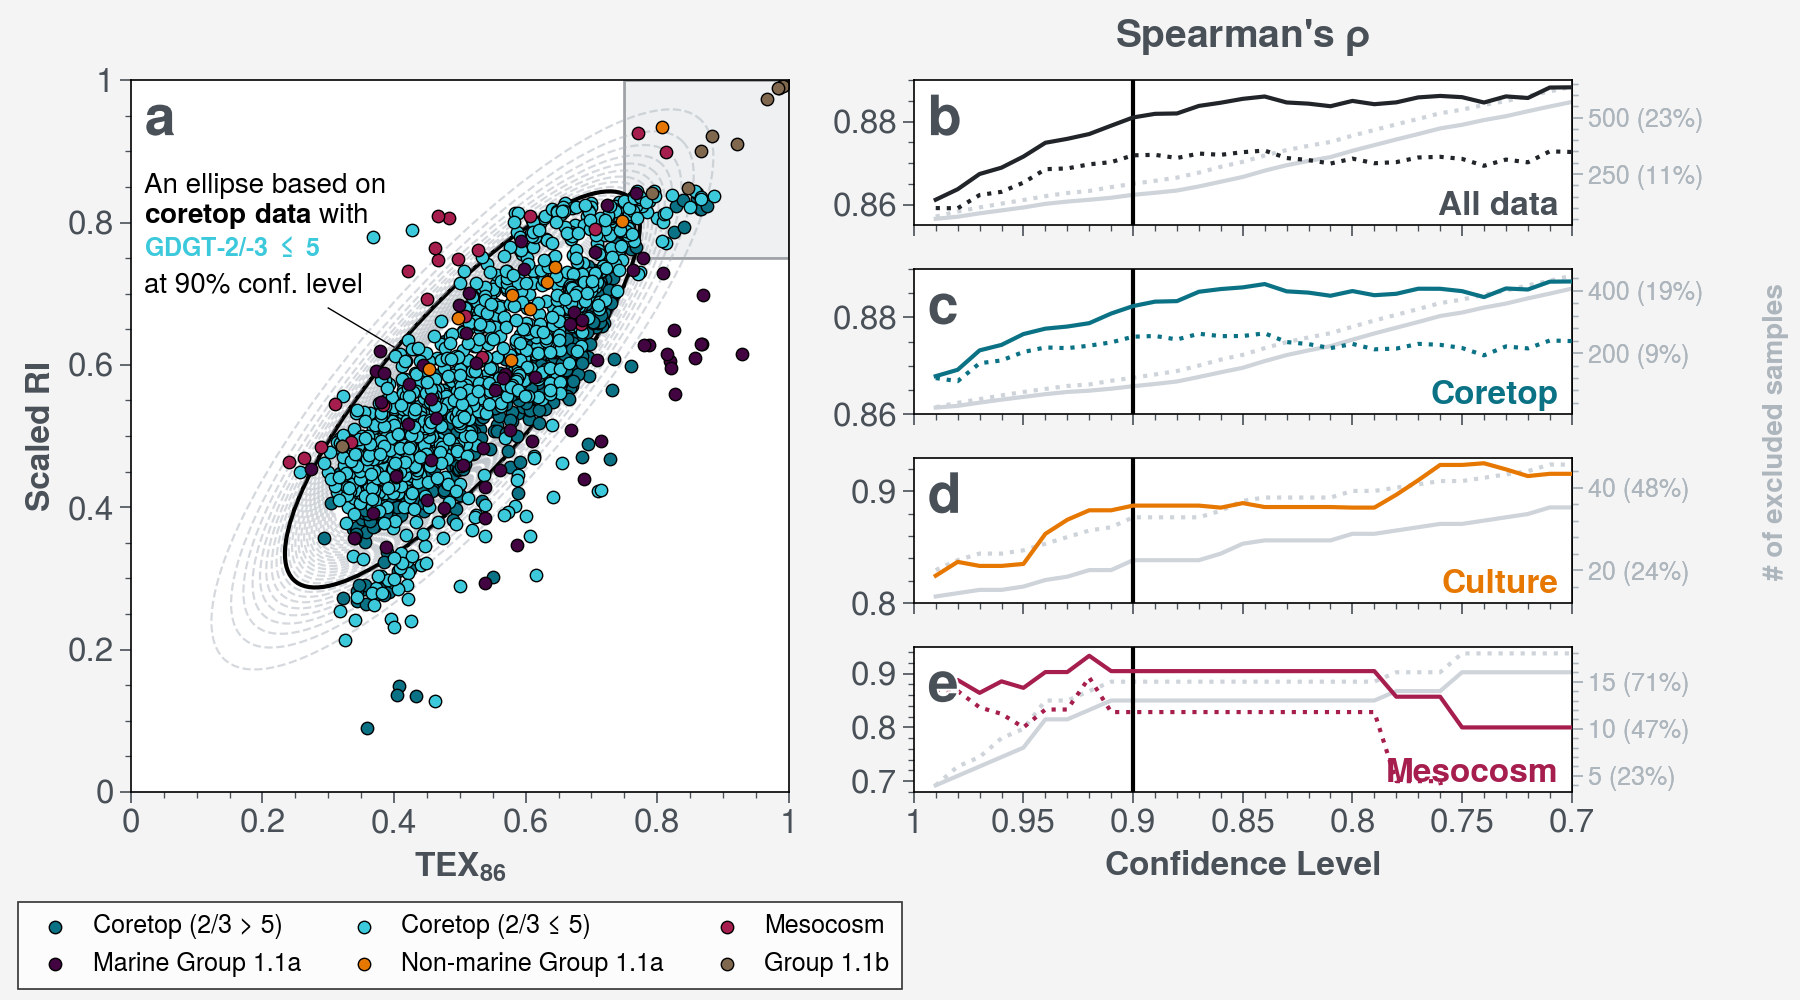

In [50]:
array =[[1,1,2,2],
        [1,1,3,3],
        [1,1,4,4],
        [1,1,5,5]]

fig, axs = plot.subplots(array,figsize=(9,5),share=0,hspace=1.75,wspace=5)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['organism_broadClass4']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='Coretop' and y>5) else
                          'coretop_low23ratio' if (x=='Coretop' and y<=5) else
                          x for x,y in zip(plot_data['organism_broadClass4'], plot_data['gdgt23ratio'])]
ordered_categories = ['coretop_high23ratio','coretop_low23ratio','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['datatype2'], 
                                              categories=ordered_categories, ordered=True)
grouped = plot_data.groupby('sorted_datatype')

sel_color_dict = broadClass4_color_dict2
ax = axs[0,0]
for name, group in grouped:
    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    ax.scatter(plot_x, plot_y, 
                c=sel_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)

    
ax.format(xlim=(0,1), ylim=(0,1),
        xlabel=r'TEX$_{86}$',
        ylabel='Scaled RI',
)   

rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)

text = 'An ellipse based on'
ax.text(0.02, 0.74+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

text = 'at 90% conf. level'
ax.text(0.02, 0.6+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)

ax.plot([0.3,0.4],[0.68,0.625], transform=ax.transAxes, color='k', linewidth=0.5,)
    
### Confidence level sensitivity test
confidence_levels = np.arange(0.7,0.991,0.01)
for conf_level in confidence_levels:
        conf_level = round(conf_level,2)
        detector_low23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=conf_level)
        fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
        detector_low23.fit(fitted_coretop_low23)
        detector_low23.plot_ellipse(ax, 
                                edgecolor='k' if conf_level==0.90  else 'gray5', 
                                linewidth=1.5 if conf_level==0.90 else 0.8, 
                                ls='-' if conf_level==0.90 else '--',
                                alpha=1 if conf_level==0.90 else 0.5,
                                zorder=0)

data_type_labels = {
        'all':'All data',
        'coretop':'Coretop',
        'mesocosm':'Mesocosm',
        'culture':'Culture'
}

        
sel_color_dict = datatype_color_dict
grouped_stats = collect_stats_df.groupby('datatype')
grouped_stats_manual = collect_stats_df_manual.groupby('datatype')
for i, (name, group) in enumerate(grouped_stats):
        
        ax = axs[i+1]
        ax.plot(group['confidence_level'].values[::-1], 
                group['rho'].values[::-1], 
                label=name, ls=':',m='',s=3,
                c=sel_color_dict.get(name,'gray9'))
        
        plot_group_manual = grouped_stats_manual.get_group(name)
        ax.plot(plot_group_manual['confidence_level'].values[::-1], 
                plot_group_manual['rho'].values[::-1], 
                label=name, ls='-',m='',s=5,
                c=sel_color_dict.get(name,'gray9'))
        
        ax2 = ax.twinx()
        ax2.set_zorder(ax.get_zorder()-1)
        ax2.patch.set_visible(False)
        
        ax2.plot(group['confidence_level'].values[::-1], 
                 group['excluded_len'].values[::-1], 
                 label=name,
                c='gray4', linestyle=':')
        
        ax2.plot(plot_group_manual['confidence_level'].values[::-1], 
                 plot_group_manual['excluded_len'].values[::-1], 
                 label=name,
                c='gray4', linestyle='-')
        
        total_samples = len(plot_data) if name=='all' else len(plot_data[plot_data['datatype']==name])
        
        ax2.format(
                yticklabels=[f'{int(x)} ({int(x/total_samples*100)}%)' for (x) in ax2.get_yticks()],
                ytickcolor='gray5',
                yticklabelcolor='gray5',
        )
        
        
        text = data_type_labels.get(name,name)
        ax.text(0.98, 0.02, text, transform=ax.transAxes,
                ha='right', va='bottom',c=sel_color_dict.get(name,'gray7'),
                fontsize=12, fontweight='bold',)
        


axs_idx = [1,2,3,4]
ylim_list = [(0.855,0.89),(0.86,0.89),(0.8,0.93),(0.68,0.95)]
for i in axs_idx:
        ax = axs[i]
        ax.format(xlim=(1,0.7), xlabel='Confidence Level',
                  ylim=ylim_list[i-1], ylabel=r'',
                  )
        
        ax.axvline(0.9, color='k', linestyle='-', linewidth=1.5, label='90% Confidence Level',zorder=0)
        
        



text = r"# of excluded samples"
axs[2].text(1.29, 0.9, text, transform=axs[2].transAxes,
            rotation=90,ha='left', va='top',c='gray5',
            fontsize=10, fontweight='bold',)

#####
h, l = axs[0].get_legend_handles_labels()
new_list = [
    item.replace('coretop_high23ratio', 'Coretop (2/3 > 5)') 
        if item == 'coretop_high23ratio'
    else item.replace('coretop_low23ratio', r'Coretop (2/3 ≤ 5)')
        if item == 'coretop_low23ratio'
    else item
    for item in l
]
axs[0].legend(h, new_list, 
              loc='b', ncols=3, fontsize=10)

### upper right corner
axs_idx = [1,2,3]
for i in axs_idx:
        ax = axs[i]
        ax.format(xticklabels=[],
                  xlabel='')

axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

#####
text = r"Spearman's $\rho$"
axs[1].text(0.5, 1.15, text, transform=axs[1].transAxes,
            ha='center', va='bottom',c='gray7',
            fontsize=14, fontweight='bold',)

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS4_TEXRI_mahalanobis_distance_confidence_level_sensitivity.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

In [51]:
# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIpercentG0': ['scaledRI', 'ZeroOverZeroCren'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIpercentG0': ['TEX86', 'scaledRI', 'ZeroOverZeroCren'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[(combined_df_raw['datatype'] == 'coretop') & (combined_df_raw['lowAbundanceFlag'] == False)])
    print(f"{name}_mahalDist_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector
    

    PhanTEX_df[f'{name}_mahalDist'] = detector.transform(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_outliers'] = detector.detect_outliers(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)

TEXRI_mahalDist_thr: 2.1460
TEXfG0_mahalDist_thr: 2.1460
TEXfCren_mahalDist_thr: 2.1460
RIfG0_mahalDist_thr: 2.1460
RIpercentG0_mahalDist_thr: 2.1460
RIfCren_mahalDist_thr: 2.1460
fG0Cren_mahalDist_thr: 2.1460
TEXRIfG0_mahalDist_thr: 2.5003
TEXRIpercentG0_mahalDist_thr: 2.5003
TEXRIfG0Cren_mahalDist_thr: 2.7892
allGDGTs_mahalDist_thr: 3.2626


In [52]:
from TEXAS.data import MahalanobisOutlierDetector

# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIpercentG0': ['scaledRI', 'ZeroOverZeroCren'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIpercentG0': ['TEX86', 'scaledRI', 'ZeroOverZeroCren'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop') 
        & (combined_df_raw['gdgt23ratio'] <= 5)])

    
    print(f"{name}_mahalDist_low23ratio_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist_low23ratio'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector
    

    PhanTEX_df[f'{name}_mahalDist_low23ratio'] = detector.transform(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_low23ratio_outliers'] = detector.detect_outliers(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)

TEXRI_mahalDist_low23ratio_thr: 2.1460
TEXfG0_mahalDist_low23ratio_thr: 2.1460
TEXfCren_mahalDist_low23ratio_thr: 2.1460
RIfG0_mahalDist_low23ratio_thr: 2.1460
RIpercentG0_mahalDist_low23ratio_thr: 2.1460
RIfCren_mahalDist_low23ratio_thr: 2.1460
fG0Cren_mahalDist_low23ratio_thr: 2.1460
TEXRIfG0_mahalDist_low23ratio_thr: 2.5003
TEXRIpercentG0_mahalDist_low23ratio_thr: 2.5003
TEXRIfG0Cren_mahalDist_low23ratio_thr: 2.7892
allGDGTs_mahalDist_low23ratio_thr: 3.2626


### 3.3.4 Comparison between deltaRI and Mahalanobis ellipse

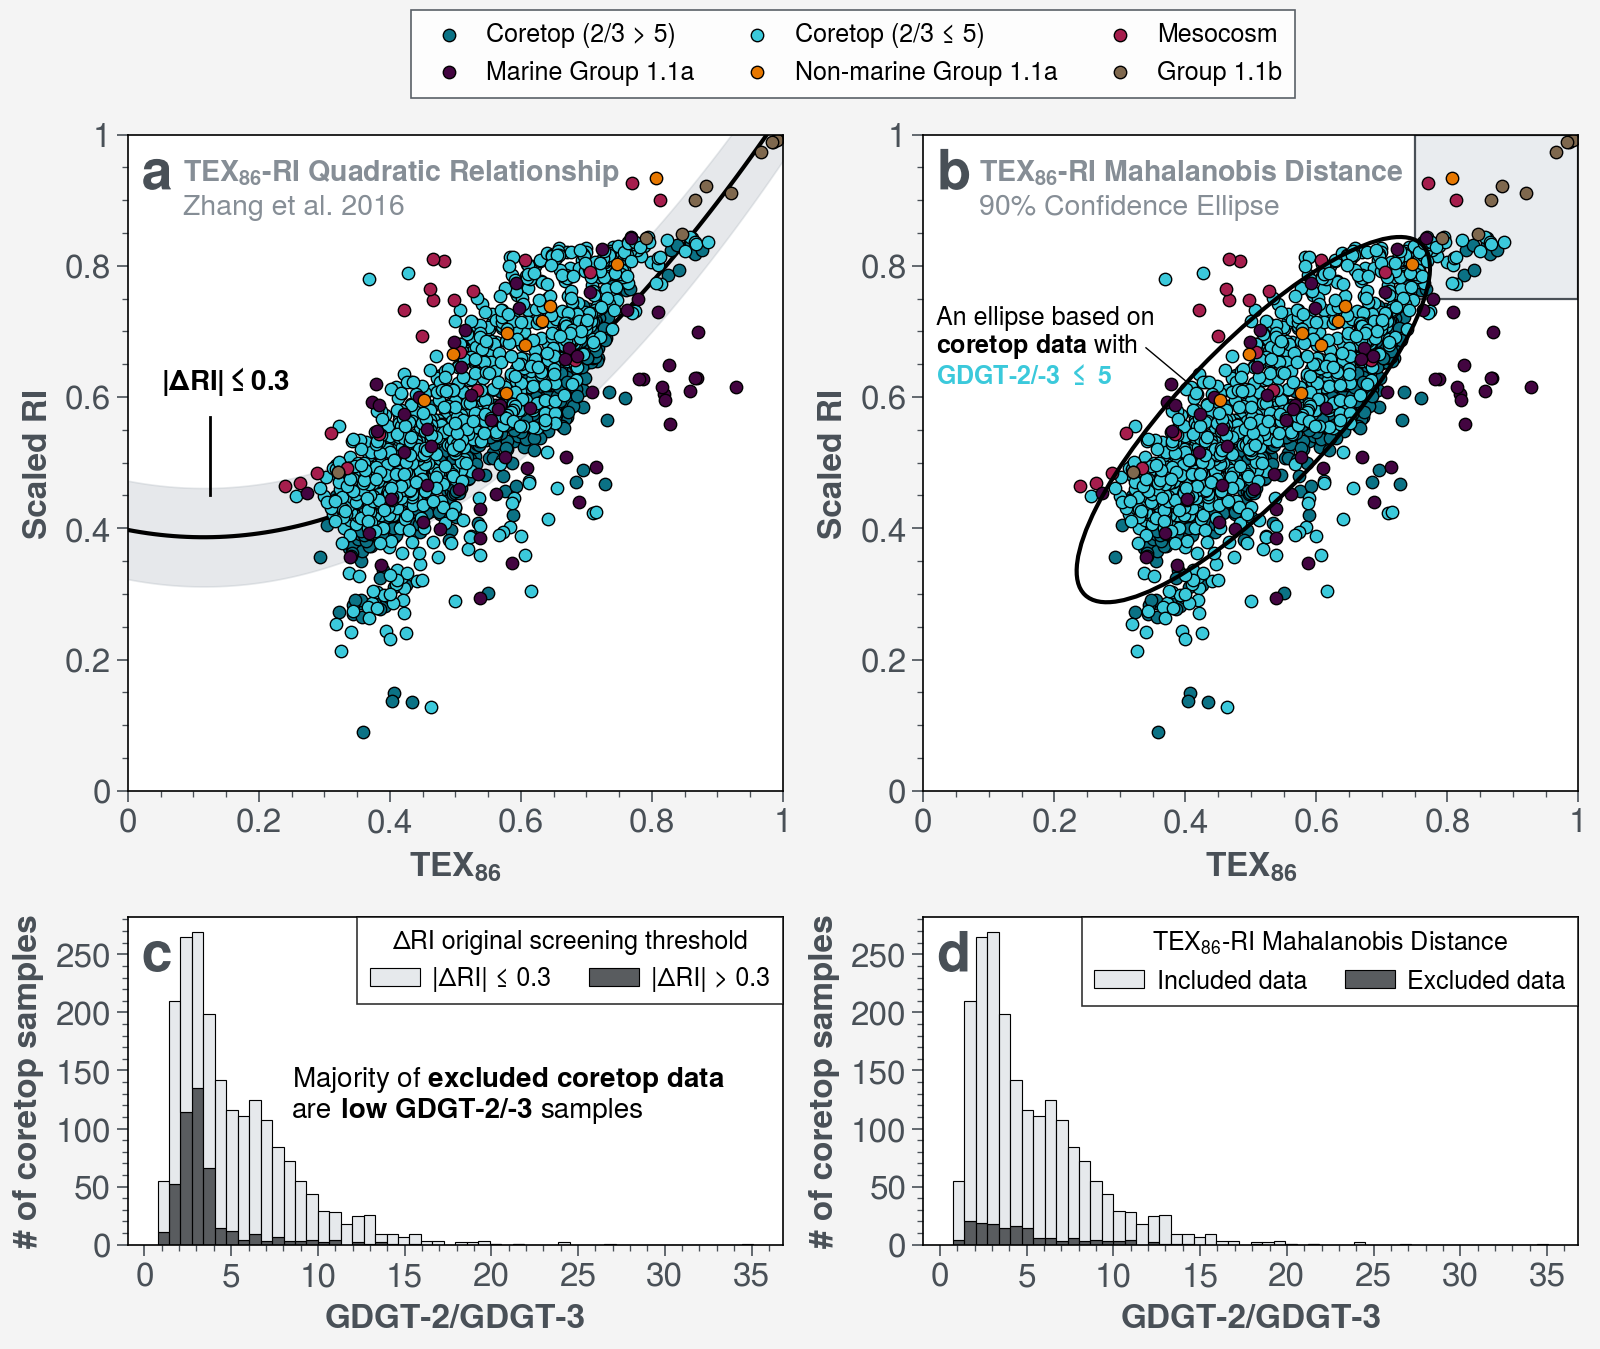

In [53]:
fig, axs = plot.subplots(ncols=2,nrows=2, width=8, hratios=[1,0.5],share=0)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['organism_broadClass4']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='Coretop' and y>5) else
                          'coretop_low23ratio' if (x=='Coretop' and y<=5) else
                          x for x,y in zip(plot_data['organism_broadClass4'], plot_data['gdgt23ratio'])]
ordered_categories = ['coretop_high23ratio','coretop_low23ratio','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['datatype2'], 
                                              categories=ordered_categories, ordered=True)
grouped = plot_data.groupby('sorted_datatype')

sel_color_dict = broadClass4_color_dict2

for name, group in grouped:
    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    axs[0,:].scatter(plot_x, plot_y, 
                c=sel_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)


ax = axs[0,0]
### Zhang16 TEX-RI curve
tex_range = np.arange(0,1.01,0.01)
ri_zhang16 = -0.77*tex_range + 3.32*(tex_range**2) + 1.59
ax.plot(tex_range, ri_zhang16/4, color='k', label='Zhang et al. (2016)', zorder=0)
ri_zhang16_upper = ri_zhang16 + 0.3
ri_zhang16_lower = ri_zhang16 - 0.3
ax.fill_between(tex_range, ri_zhang16_lower/4, ri_zhang16_upper/4, color='gray5', alpha=0.3, label='±0.3 RI', zorder=0)

text = r'TEX$_{86}$-RI Quadratic Relationship'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = 'Zhang et al. 2016'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

text = r'|$\Delta$RI|$\leq$0.3'
ax.text(0.05, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10, fontweight='bold',)
ax.plot([0.125,0.125],[0.57,0.45], transform=ax.transAxes, color='k', linewidth=1,)

##################################################
ax = axs[0,1]

# fitted_coretop_all = plot_data[plot_data['datatype']=='coretop']
# detector = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
# detector.fit(fitted_coretop_all)
# detector.plot_ellipse(ax, edgecolor='k', linewidth=1, label='90% Confidence Ellipse',ls='-',alpha=1)

# fitted_coretop_high23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']>5]
# detector_high23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
# detector_high23.fit(fitted_coretop_high23)
# detector_high23.plot_ellipse(ax, edgecolor='cyan9', linewidth=1, label='90% Confidence Ellipse',ls='-',alpha=1)

fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
detector_low23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
detector_low23.fit(fitted_coretop_low23)
detector_low23.plot_ellipse(ax, edgecolor='k', linewidth=1.5, label='90% Confidence Ellipse',ls='-',alpha=1)

rect = Rectangle((0.75,0.75),0.25,0.25, transform=ax.transAxes,
                 facecolor='gray2', edgecolor='gray7', linewidth=0.8, zorder=0)
ax.add_artist(rect)


######

text = r'TEX$_{86}$-RI Mahalanobis Distance'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = r'90% Confidence Ellipse'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

############################
text = 'An ellipse based on'
ax.text(0.02, 0.74, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

ax.plot([0.34,0.4],[0.675,0.625], transform=ax.transAxes, color='k', linewidth=0.5,)

# ############################
# text = 'An ellipse based on'
# ax.text(0.2, 0.18, text, transform=ax.transAxes,
#               ha='center', va='top',c='k',
#               fontsize=9,)
# BOLD = '\033[1m'
# END = '\033[0m'
# substring = "coretop"
# text =  r"$\bf{all\ coretop\ data}$"
# ax.text(0.2, 0.14, text, transform=ax.transAxes,
#               ha='center', va='top',c='k',
#               fontsize=9,)

# ax.plot([0.2,0.27],[0.2,0.31], transform=ax.transAxes, color='k', linewidth=0.5,)

# ############################
# text = 'An ellipse based on'
# ax.text(0.65, 0.36, text, transform=ax.transAxes,
#               ha='left', va='top',c='k',
#               fontsize=9,)
# BOLD = '\033[1m'
# END = '\033[0m'
# substring = "coretop"
# text =  r"$\bf{coretop\ data}$ with"
# ax.text(0.65, 0.32, text, transform=ax.transAxes,
#               ha='left', va='top',c='k',
#               fontsize=9,)

# text = 'GDGT-2/-3 > 5'
# ax.text(0.65, 0.27, text, transform=ax.transAxes,
#               ha='left', va='top',c='cyan9',
#               fontsize=9,fontweight='bold',)

# ax.plot([0.56,0.65],[0.45,0.35], transform=ax.transAxes, color='cyan9', linewidth=0.5,)

## plot stacked histrograms
ax = axs[1,0]
plot_coretop = plot_data[plot_data['datatype']=='coretop']
plot_coretop["bin_absDeltaRI"] = pd.cut(abs(plot_coretop['deltaRI']), bins=[0,0.3,2])
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='bin_absDeltaRI',
             palette={pd.Interval(0,0.3):'gray3', pd.Interval(0.3,2):'gray9'},
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['|ΔRI| ≤ 0.3','|ΔRI| > 0.3'], title='ΔRI original screening threshold')

text = r'Majority of $\bf{excluded\ coretop\ data}$'
ax.text(0.25, 0.55, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10,)

text = r'are'
ax.text(0.25, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10 )
text = r'low GDGT-2/-3'
ax.text(0.325, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, fontweight='bold',)
text = 'samples'
ax.text(0.63, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, )

## plot stacked histrograms for mahalanobis distance
ax = axs[1,1]
plot_coretop['TEXRI_mahal_outliers'] = detector_low23.detect_outliers(plot_coretop)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='TEXRI_mahal_outliers',
             palette={False:'gray3', True:'gray9'},
             multiple='stack',
                legend=False)

h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['Included data','Excluded data'], title=r'$TEX_{86}$-RI Mahalanobis Distance')

##################################################

axs[0,:].format(
    xlim=(0,1), ylim=(0,1),
    xlabel=r'TEX$_{86}$',
    ylabel='Scaled RI',
)
axs[1,:].format(
    xlabel='GDGT-2/GDGT-3',
    ylabel='# of coretop samples'
)
axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

h, l = axs[0,0].get_legend_handles_labels()
new_list = [
    item.replace('coretop_high23ratio', 'Coretop (2/3 > 5)') 
        if item == 'coretop_high23ratio'
    else item.replace('coretop_low23ratio', r'Coretop (2/3 ≤ 5)')
        if item == 'coretop_low23ratio'
    else item
    for item in l
]
fig.legend(h[1:7],new_list[1:7],
           loc='t', fontsize=8, framealpha=0.9, edgecolor='gray7', ncols=3,)

fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig4_TEXRI_mahalanobis_distance_gdgt23ratio.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

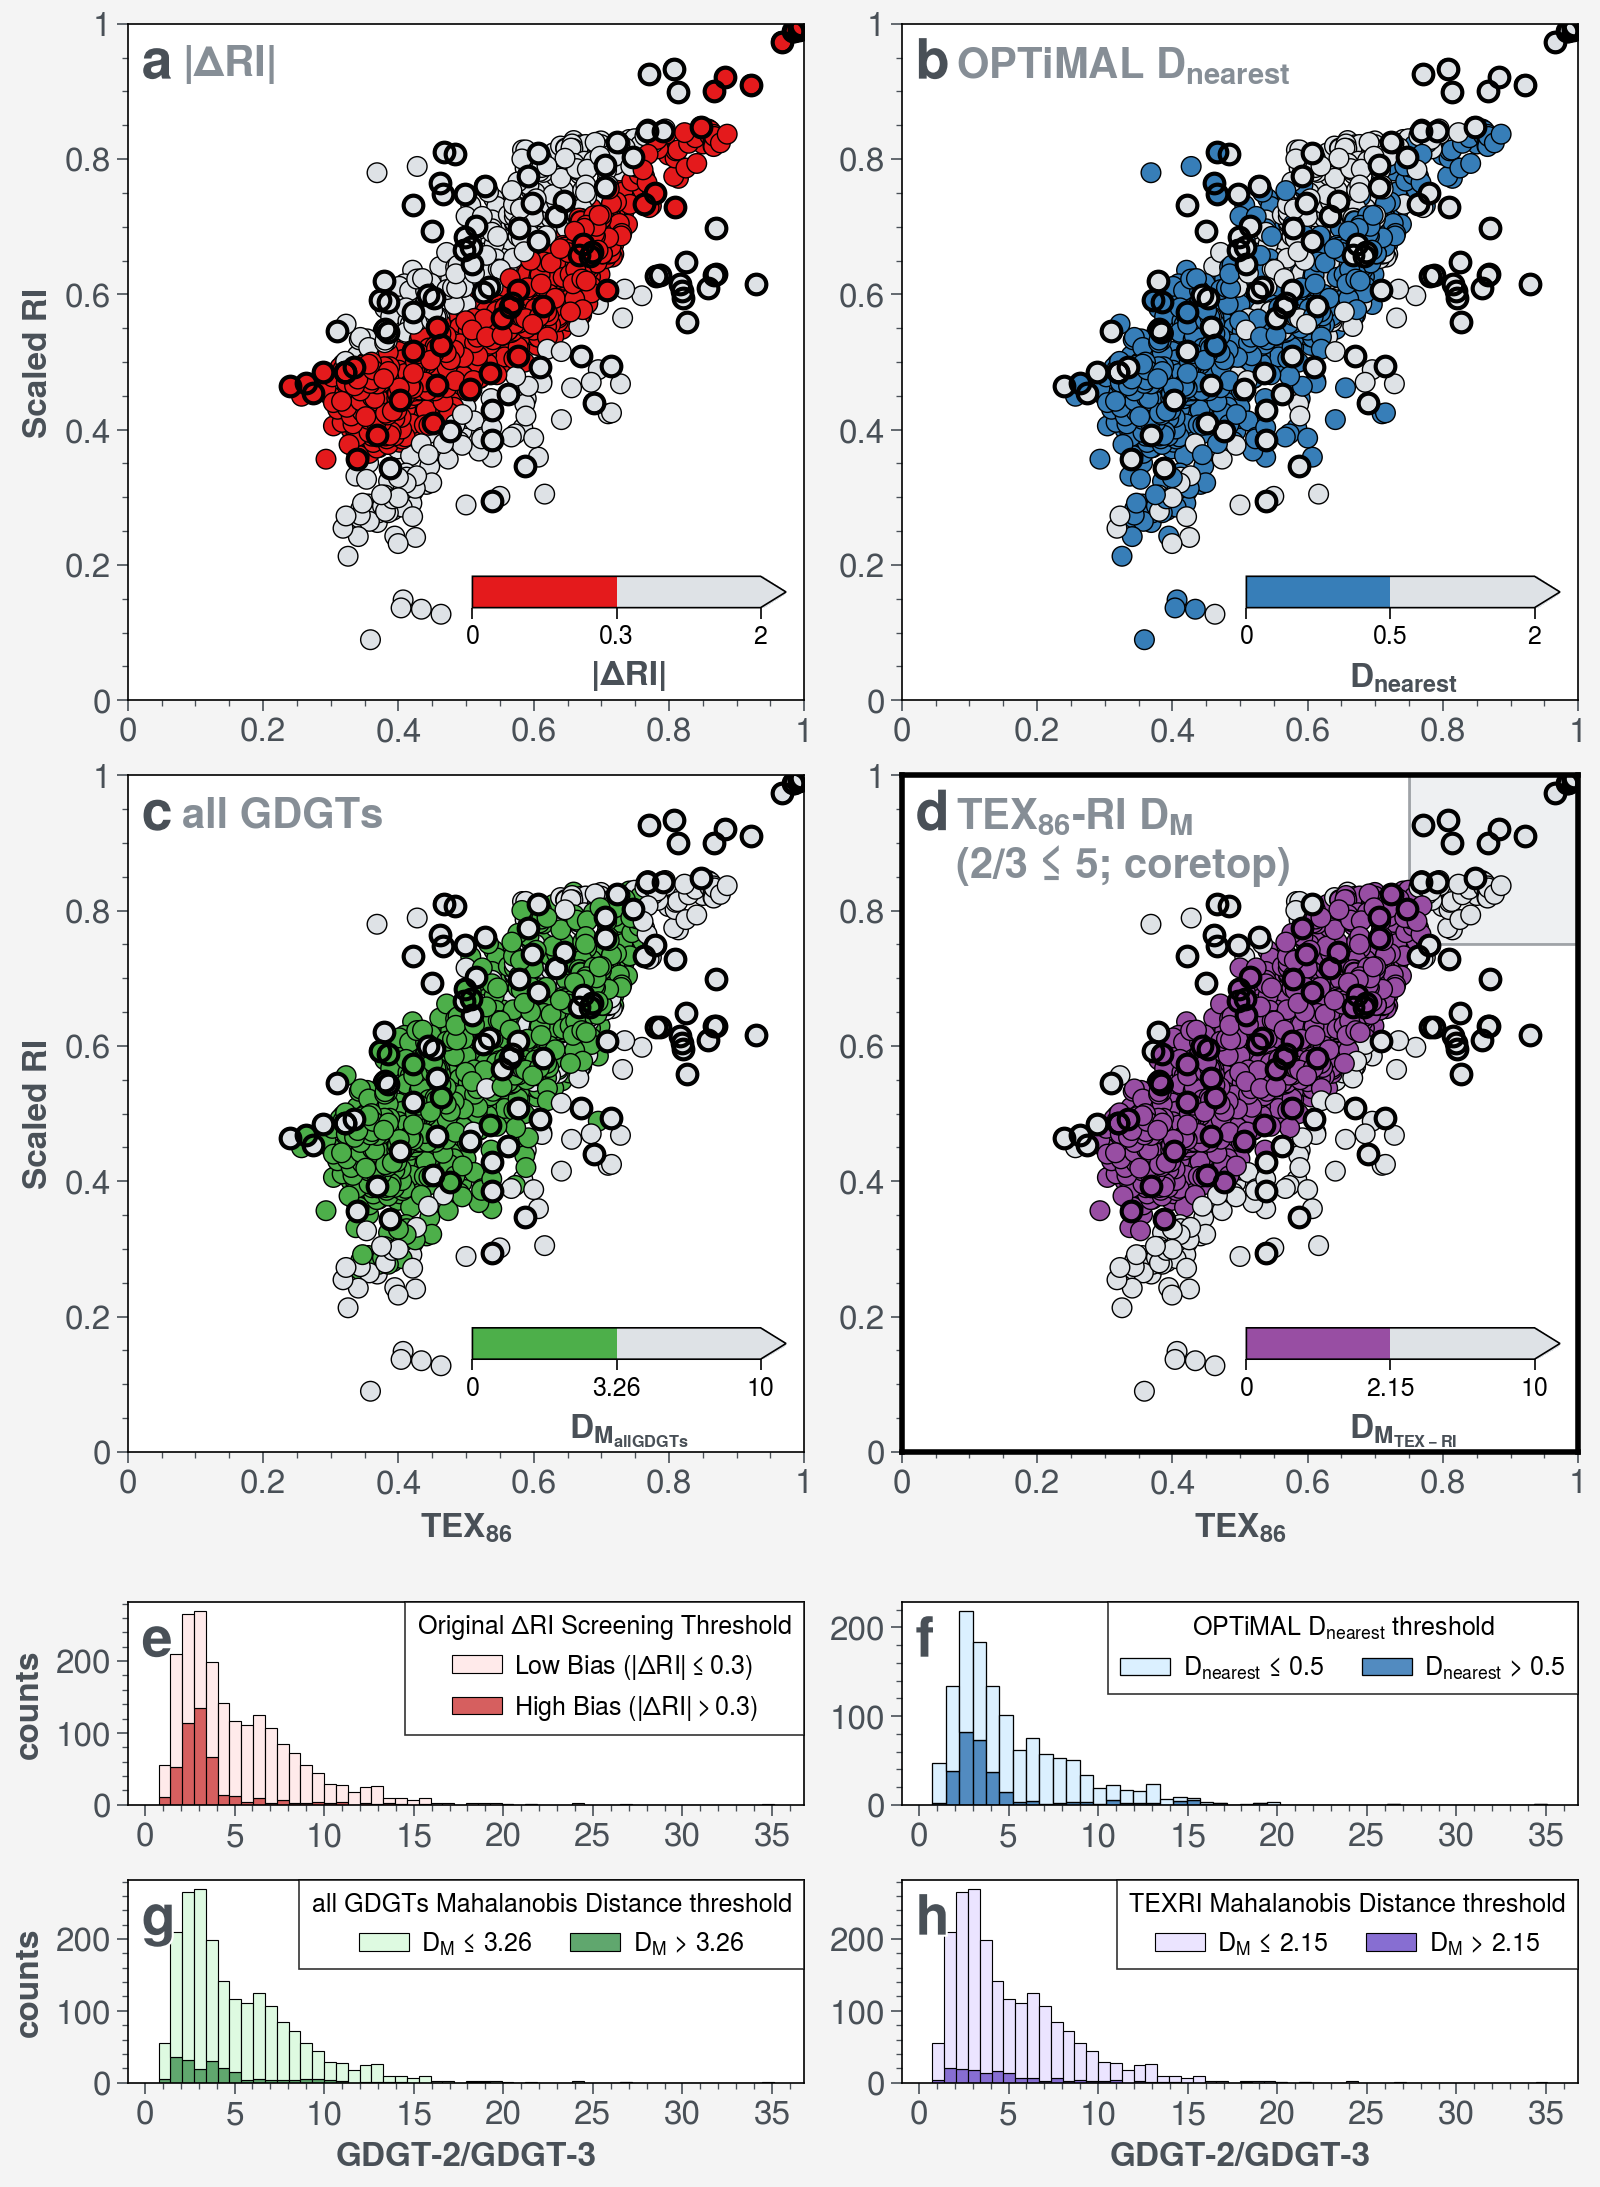

In [54]:
fig, axs = plot.subplots(ncols=2,nrows=4, width=8, 
                         hratios=[1,1,0.3,0.3],
                         hspace=[3,6,3],
                         share=0)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


color_params = ['abs_deltaRI','OPTiMAL_Dnearest','allGDGTs_mahalDist', 'TEXRI_mahalDist_low23ratio',]
labels=['|ΔRI|',r'OPTiMAL D$_{nearest}$','all GDGTs',r'TEX$_{86}$-RI D$_{M}$'+f'\n(2/3 ≤ 5; coretop)']
cbar_labels=['|ΔRI|',r'D$_{nearest}$',r'D$_{M_{allGDGTs}}$',r'D$_{M_{TEX-RI}}$']
tab10_colors = plot.get_colors('Set1')
color_levels = [
    [0,0.3,2],
    [0,0.5,2],
    [0,3.2626,10],
    [0,2.1460,10]
]

for i, c_param in enumerate(color_params):
    ax = axs[i]
    
    plot_x = plot_data['TEX86']
    plot_y = plot_data['scaledRI']
    plot_c = plot_data[c_param]
    m = ax.scatter(plot_x, plot_y,
               c=plot_c,
               cmap=[tab10_colors[i],'gray3','gray3'],
               levels=color_levels[i],
               extend='max',
               m='o',mec='k', mew=0.5,
               s=50, label=labels[i])
    
    ax.colorbar(m, label=cbar_labels[i],
                loc='lr',shrink=12,
                labelsize=12, labelweight='bold',
                labelcolor='gray7',
                frame=False)
    
    text = labels[i]
    ax.text(0.08, 0.97, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=15, fontweight='bold',)
    
grouped = plot_data.groupby('datatype')
for name, group in grouped:
    if name != 'coretop':
        axs[:2,:2].scatter(group['TEX86'], group['scaledRI'],
                   facecolor='none', 
                   mec='k', mew=1.5, 
                   m='o', s=50, label=name)
    

ax=axs[3]
ax.spines[:].set_linewidth(2.0)
rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)


######## Plot histograms of the color parameters for coretop samples with GDGT-2/3 ratio ≤ 5, colored by whether they are excluded by the TEXRI Mahalanobis distance method or not
ax = axs[2,0]
max_val = plot_coretop['deltaRI'].abs().max()
plot_coretop["bin_absDeltaRI"] = pd.cut(
    plot_coretop['deltaRI'].abs(), 
    bins=[0, 0.3, max_val],
    labels=['Low Bias ($|\Delta RI| \leq 0.3$)', 'High Bias ($|\Delta RI| > 0.3$)']
)

m = sns.histplot(ax=ax, data=plot_coretop,
             x='gdgt23ratio', 
             hue='bin_absDeltaRI',
             palette={'Low Bias ($|\Delta RI| \leq 0.3$)': 'red1', # Light blue
                      'High Bias ($|\Delta RI| > 0.3$)': 'red9'}, # Strong red
             multiple='stack',
             legend=False)

h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['Low Bias ($|\Delta RI| \leq 0.3$)', 'High Bias ($|\Delta RI| > 0.3$)'], loc='ur',
          title='Original ΔRI Screening Threshold', ncols=1)

#OPTiMAL Dnearest histogram
ax = axs[2,1]
max_val = plot_coretop['OPTiMAL_Dnearest'].max()
plot_coretop['OPTiMAL_Dnearest_bin'] = pd.cut(
    plot_coretop['OPTiMAL_Dnearest'], 
    bins=[0, 0.5, max_val],
    labels=['D$_{nearest}$ ≤ 0.5', 'D$_{nearest}$ > 0.5']
)

m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='OPTiMAL_Dnearest_bin',
             palette={
                 'D$_{nearest}$ ≤ 0.5':'blue1',
                 'D$_{nearest}$ > 0.5':'blue9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{nearest}$ ≤ 0.5','D$_{nearest}$ > 0.5'], title='OPTiMAL D$_{nearest}$ threshold')

#### All GDGTs Mahalanobis distance histogram
ax = axs[3,0]
max_val = plot_coretop['allGDGTs_mahalDist'].max()
plot_coretop['allGDGTs_mahalDist_bin'] = pd.cut(
    plot_coretop['allGDGTs_mahalDist'], 
    bins=[0, 3.2626, max_val],
    labels=['D$_{M}$ ≤ 3.26', 'D$_{M}$ > 3.26']
)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='allGDGTs_mahalDist_bin',
             palette={
                 'D$_{M}$ ≤ 3.26':'green1',
                 'D$_{M}$ > 3.26':'green9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{M}$ ≤ 3.26','D$_{M}$ > 3.26'], title='all GDGTs Mahalanobis Distance threshold')

#### TEXRI Mahalanobis distance histogram
ax = axs[3,1]
max_val = plot_coretop['TEXRI_mahalDist_low23ratio'].max()
plot_coretop['TEXRI_mahalDist_low23ratio_bin'] = pd.cut(
    plot_coretop['TEXRI_mahalDist_low23ratio'], 
    bins=[0, 2.1460, max_val],
    labels=['D$_{M}$ ≤ 2.15', 'D$_{M}$ > 2.15']
)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='TEXRI_mahalDist_low23ratio_bin',
             palette={
                 'D$_{M}$ ≤ 2.15':'violet1',
                 'D$_{M}$ > 2.15':'violet9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{M}$ ≤ 2.15', 'D$_{M}$ > 2.15'], title='TEXRI Mahalanobis Distance threshold')

axs[0:2,:].format(xlabel=r'$TEX_{86}$', ylabel='Scaled RI')
axs[:2,:].format(xlim=(0,1), ylim=(0,1))
axs[2,:].format(xlabel='', ylabel='counts')
axs[3,:].format(xlabel='GDGT-2/GDGT-3', ylabel='counts')
axs[0,:].format(xlabel='')
axs[:,1].format(ylabel='')


axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold'
)

fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS4_TEXRI_mahalanobis_distance_comparison_different_methods.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)


## 3.3 Gridded coretop dataset

In [55]:
clean_coretop_df = combined_df_raw[(combined_df_raw['datatype']=='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_coretop_df)

clean_culmeso_df = combined_df_raw[(combined_df_raw['datatype']!='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_culmeso_df)

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIpercentG0_mahalDist_low23ratio,TEXRIpercentG0_mahalDist_low23ratio_outliers,TEXRIpercentG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,0.60,2.34,...,False,1.35,False,False,1.45,False,False,4.11,True,True
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,0.60,2.57,...,False,0.92,False,False,0.89,False,False,1.86,False,False
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,0.62,2.50,...,False,1.09,False,False,1.25,False,False,1.59,False,False
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,0.61,2.43,...,False,1.24,False,False,1.24,False,False,2.81,False,False
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,0.59,2.25,...,False,1.28,False,False,1.85,False,False,3.68,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,-27.26,112.04,-27.38,112.12,1182.70,19.28,22.76,1.47,0.67,2.79,...,False,1.42,False,False,1.39,False,False,1.52,False,False
2057,-28.14,112.63,-28.12,112.62,1014.60,18.86,22.58,1.63,0.66,2.77,...,False,1.26,False,False,1.28,False,False,1.17,False,False
2058,-28.13,112.94,-28.12,112.88,797.80,19.09,22.67,1.46,0.68,3.00,...,False,1.57,False,False,1.65,False,False,1.94,False,False
2059,-28.38,113.02,-28.38,113.12,810.20,19.13,22.57,1.36,0.64,2.67,...,False,1.10,False,False,1.28,False,False,1.29,False,False


,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIpercentG0_mahalDist_low23ratio,TEXRIpercentG0_mahalDist_low23ratio_outliers,TEXRIpercentG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
2061,NaN,NaN,NaN,NaN,NaN,37.00,37.00,NaN,0.58,2.79,...,True,14.49,True,True,13.26,True,True,39.61,True,True
2062,NaN,NaN,NaN,NaN,NaN,46.00,46.00,NaN,0.81,3.73,...,False,2.98,True,False,13.81,True,False,24.95,True,True
2067,NaN,NaN,NaN,NaN,NaN,18.00,18.00,NaN,0.51,1.84,...,True,4.81,True,True,8.97,True,True,9.80,True,True
2078,NaN,NaN,NaN,NaN,NaN,15.00,15.00,NaN,0.46,2.21,...,True,6.89,True,True,6.34,True,True,8.13,True,True
2079,NaN,NaN,NaN,NaN,NaN,20.00,20.00,NaN,0.52,2.41,...,True,8.31,True,True,5.73,True,True,6.76,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,NaN,NaN,NaN,NaN,NaN,22.00,22.00,NaN,0.51,2.68,...,False,3.37,True,True,2.72,False,False,3.72,True,True
2162,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,0.53,2.45,...,False,2.60,True,True,2.50,False,False,3.69,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,0.68,2.63,...,False,2.55,True,True,1.84,False,False,1.34,False,False
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,0.81,3.60,...,False,3.72,True,False,5.22,True,False,4.53,True,True


#### 04deg gridded

In [56]:
nonnumeric_cols = ['regionName','reference_name','datatype', 'Strains',
       'organism_commonName', 'organism_broadClass', 'organism_broadClass2',
       'organism_broadClass3','organism_broadClass4', 'publicationYear']

gridded_coretop_04deg_df = pd.pivot_table(
    clean_coretop_df,
    index=['match_lat_04deg','match_lon_04deg'],
    values=nonnumeric_cols,
    aggfunc='first',
    sort=False,
).reset_index()

display(gridded_coretop_04deg_df)

numeric_cols = ['Latitude','Longitude','modernWaterDepth', 'TEX86', 'BIT',
       'methaneIndex', 'ringIndex', 'scaledRI',
       'gdgt23ratio','ZeroOverZeroCren', 
       'SST','t_sf2tc_avg','no3_sf2tc_avg',
       'OPTiMAL_Dnearest','OPTiMAL_SST']

temp_numeric_gridded = pd.pivot_table(
       clean_coretop_df, 
       values=numeric_cols, index=['match_lat_04deg','match_lon_04deg'],
       aggfunc='median').reset_index()

display(temp_numeric_gridded)

gridded_combined_df = pd.merge(gridded_coretop_04deg_df,temp_numeric_gridded,how='right')

sel_columns = gridded_combined_df.columns

gridded_combined_df = pd.concat([gridded_combined_df, clean_culmeso_df[sel_columns]], axis=0)
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,organism_broadClass4,publicationYear
0,-1.62,-86.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
1,-3.88,-81.38,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
2,-3.62,-81.12,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
3,-3.12,-82.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
4,-3.62,-83.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1508,-27.38,112.12,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1509,-28.12,112.62,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1510,-28.12,112.88,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1511,-28.38,113.12,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00


,match_lat_04deg,match_lon_04deg,BIT,Latitude,Longitude,OPTiMAL_Dnearest,OPTiMAL_SST,SST,TEX86,ZeroOverZeroCren,gdgt23ratio,methaneIndex,modernWaterDepth,no3_sf2tc_avg,ringIndex,scaledRI,t_sf2tc_avg
0,-77.88,-40.38,0.00,-77.80,-40.45,0.19,0.52,-1.65,0.41,0.49,1.50,0.03,928.00,-1.65,2.04,0.51,-1.64
1,-77.38,-158.38,NaN,-77.47,-158.27,0.00,1.77,-1.51,0.35,0.56,2.83,0.07,1081.00,-1.51,1.75,0.44,-1.59
2,-77.12,-45.38,0.01,-77.02,-45.41,0.12,1.80,-1.70,0.37,0.59,1.83,0.05,332.00,-1.70,1.64,0.41,-1.69
3,-76.62,-35.38,0.01,-76.64,-35.43,0.25,0.54,-1.43,0.34,0.57,2.07,0.04,932.00,28.37,1.73,0.43,-1.50
4,-76.38,-33.88,0.01,-76.38,-33.93,0.23,-0.12,-1.75,0.34,0.55,2.04,0.04,839.00,29.12,1.79,0.45,-1.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.12,46.62,NaN,84.01,46.72,0.00,2.15,-1.49,0.37,0.55,2.56,0.07,3960.00,7.49,1.79,0.45,-1.24
1509,84.88,40.62,0.58,84.88,40.60,0.07,4.01,-1.64,0.37,0.56,3.72,0.10,4018.00,7.67,1.76,0.44,-1.37
1510,86.88,-146.12,NaN,87.00,-146.00,0.00,-2.90,-1.57,0.44,0.61,9.56,0.18,3368.00,8.39,1.60,0.40,-1.47
1511,87.12,104.62,NaN,87.07,104.66,0.00,4.03,-1.73,0.50,0.58,2.87,0.14,4443.00,6.83,1.73,0.43,-1.38


,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,SST,TEX86,ZeroOverZeroCren,gdgt23ratio,methaneIndex,modernWaterDepth,no3_sf2tc_avg,ringIndex,scaledRI,t_sf2tc_avg
0,-77.88,-40.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.65,0.41,0.49,1.50,0.03,928.00,-1.65,2.04,0.51,-1.64
1,-77.38,-158.38,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.51,0.35,0.56,2.83,0.07,1081.00,-1.51,1.75,0.44,-1.59
2,-77.12,-45.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.70,0.37,0.59,1.83,0.05,332.00,-1.70,1.64,0.41,-1.69
3,-76.62,-35.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.43,0.34,0.57,2.07,0.04,932.00,28.37,1.73,0.43,-1.50
4,-76.38,-33.88,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.75,0.34,0.55,2.04,0.04,839.00,29.12,1.79,0.45,-1.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,22.00,0.51,0.28,4.40,0.20,NaN,NaN,2.68,0.67,22.00
2162,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,25.00,0.53,0.35,2.19,0.25,NaN,NaN,2.45,0.61,25.00
2164,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,32.00,0.68,0.33,3.55,0.17,NaN,NaN,2.63,0.66,32.00
2166,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,36.00,0.81,0.06,2.40,0.11,NaN,NaN,3.60,0.90,36.00


In [57]:
gridded_combined_df.columns

Index(['match_lat_04deg', 'match_lon_04deg', 'regionName', 'reference_name',
       'datatype', 'Strains', 'organism_commonName', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'organism_broadClass4',
       'publicationYear', 'BIT', 'Latitude', 'Longitude', 'OPTiMAL_Dnearest',
       'OPTiMAL_SST', 'SST', 'TEX86', 'ZeroOverZeroCren', 'gdgt23ratio',
       'methaneIndex', 'modernWaterDepth', 'no3_sf2tc_avg', 'ringIndex',
       'scaledRI', 't_sf2tc_avg'],
      dtype='object')

Coretop False 0
Mesocosm False 1
Marine Group 1.1a True 2
Non-marine Group 1.1a True 3
Group 1.1b True 4
SST: x0=27.635, b=0.431, k=0.134, v=1.318, Q=1.882, n=1576
R² Sigmoid SST: 0.723
Coretop False 0
Mesocosm False 1
Marine Group 1.1a True 2
Non-marine Group 1.1a True 3
Group 1.1b True 4
t_sf2tc_avg: x0=24.786, b=0.438, k=0.127, v=1.007, Q=1.564, n=1576
R² Sigmoid t_sf2tc_avg: 0.728


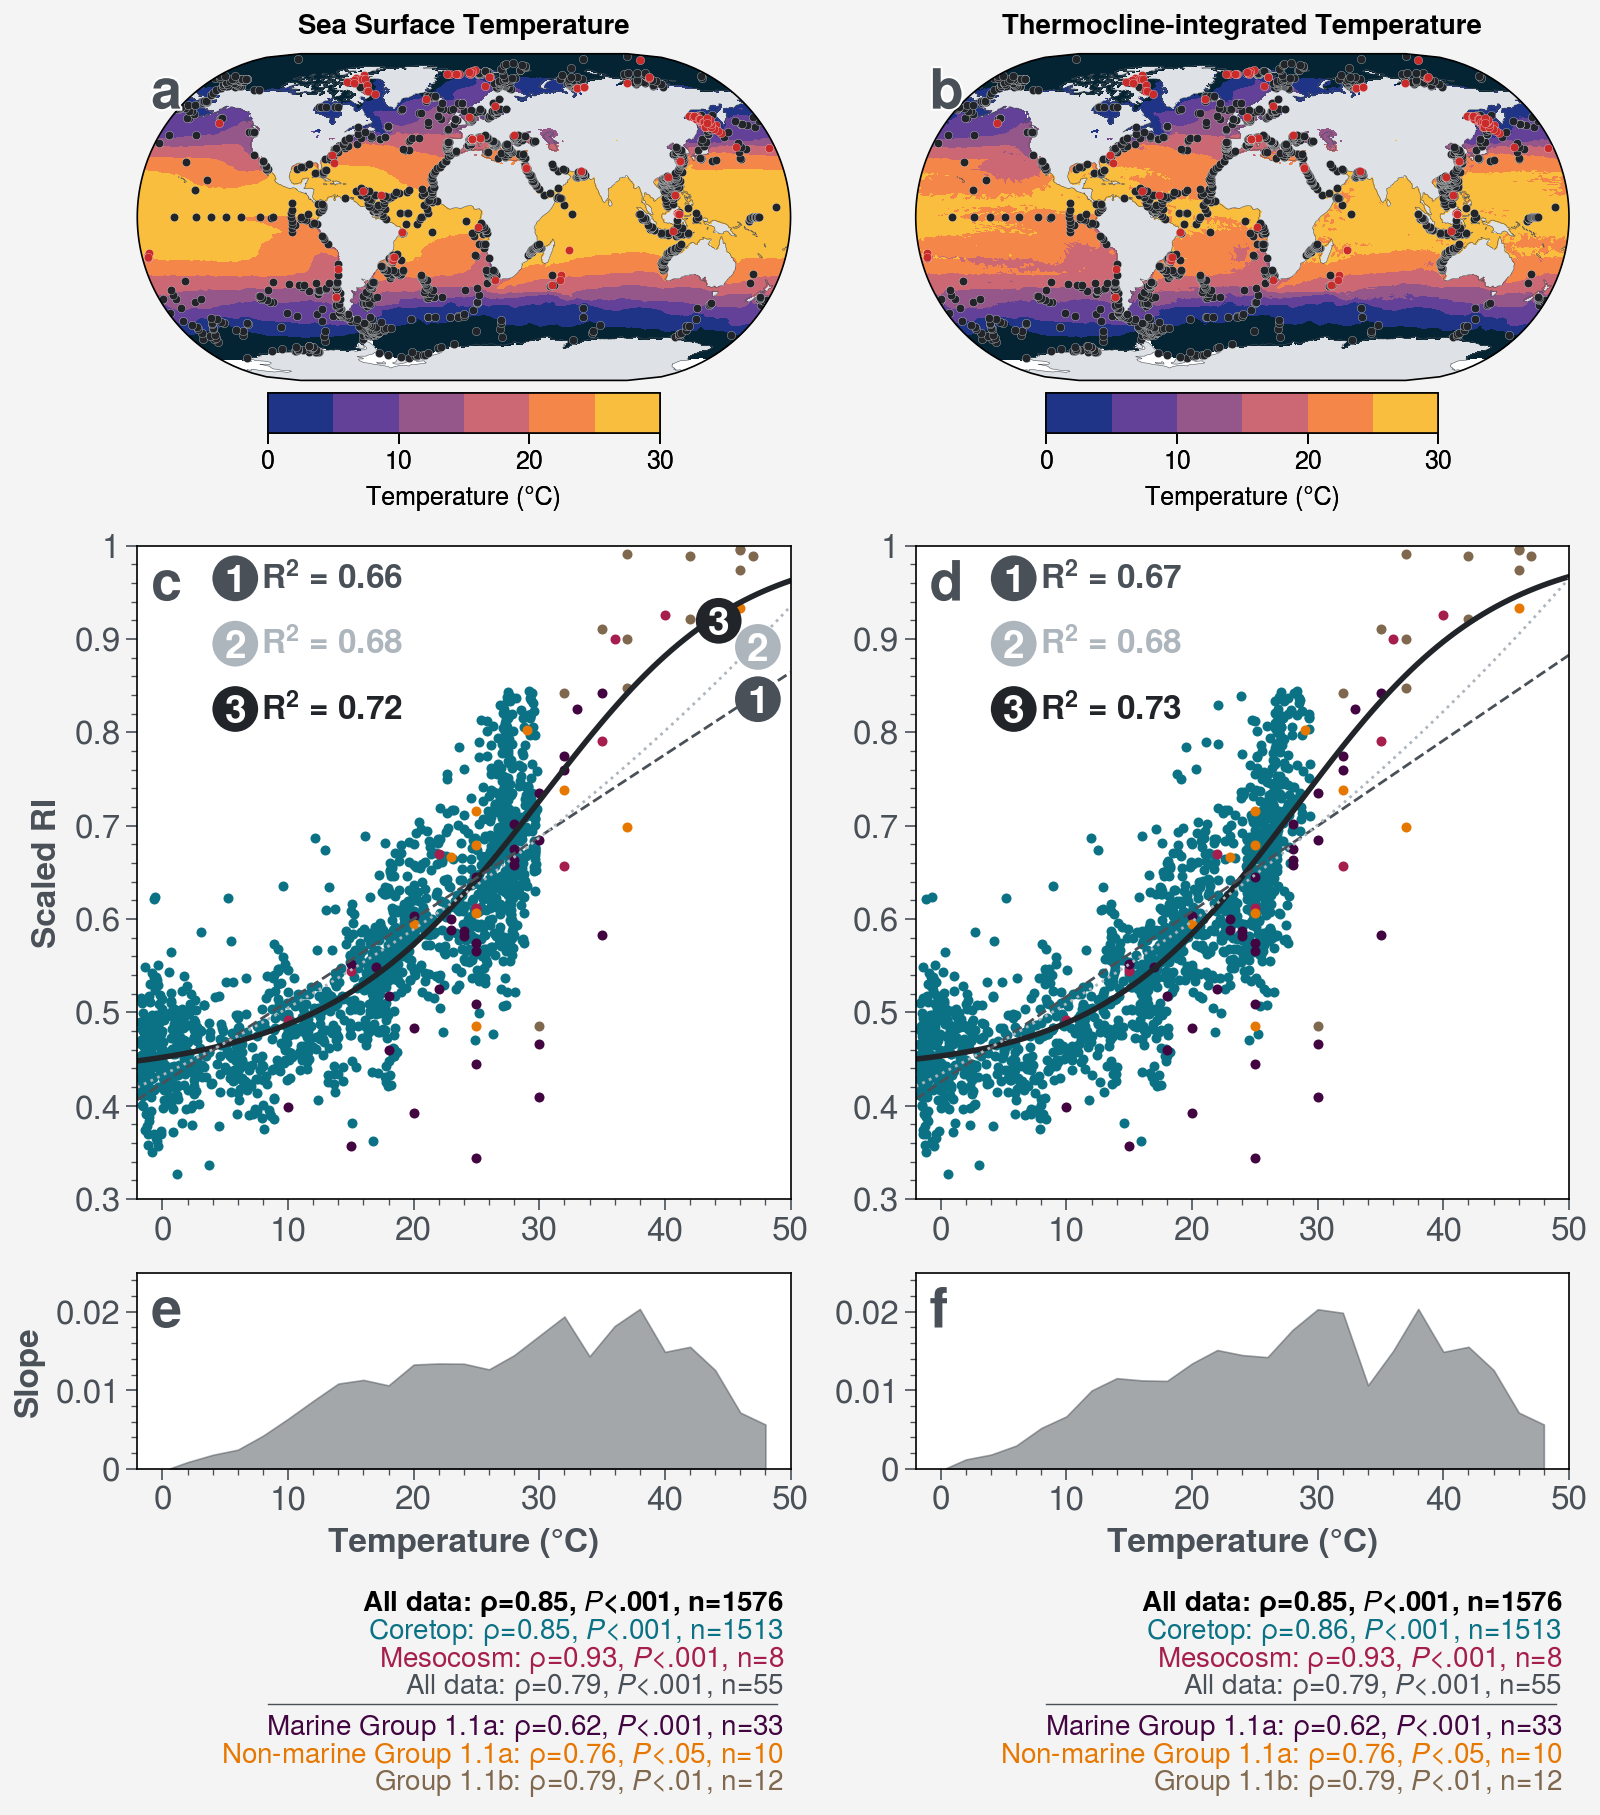

In [58]:
# 2) Build your data dict exactly as before
plot_data = gridded_combined_df
plot_data['no3_sf2tc_avg'] = [10 if n!='coretop' and np.isnan(x) else x 
                               for x,n in zip(plot_data['no3_sf2tc_avg'], plot_data['datatype'])]
plot_data = plot_data.dropna(subset=['TEX86','scaledRI','SST','t_sf2tc_avg','no3_sf2tc_avg'])
ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'], 
                                              categories=ordered_categories, ordered=True)

fig, axs = plot.subplots(width=8, ncols=2, nrows=3, share=False,
                         proj={1:'eck3', 2:'eck3'}, hratios=[0.5, 1, 0.3])

axs.format(collabels=['Sea Surface Temperature', 'Thermocline-integrated Temperature'])
axs[0,:].format(coast=True, land=True,
                landcolor='gray3', coastcolor='gray7',
                landzorder=0, coastzorder=1,
                coastlinewidth=0.2)

ax = axs[0,0]
m = T_da.isel(depth=0).plot(ax=ax, cmap='thermal',
                             add_colorbar=False,
                             levels=np.arange(0,31,5),
                             extend='both', rasterized=True)
ax.format(title='')
ax.colorbar(m, label='Temperature (°C)', loc='b', shrink=0.6, extend='both')

ax = axs[0,1]
m = ocean_prop_ds['t_sf2tc_avg'].plot(ax=ax, cmap='thermal',
                                       add_colorbar=False,
                                       levels=np.arange(0,31,5),
                                       extend='both', rasterized=True)
ax.format(title='')
ax.colorbar(m, label='Temperature (°C)', loc='b', shrink=0.6, extend='both')

excluded_coretop = combined_df_raw[
    (combined_df_raw['datatype']=='coretop') &
    (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==True) &
    (combined_df_raw['lowAbundanceFlag']==False)
]
for ax in axs[0,:]:
    ax.scatter(plot_data['Longitude'], plot_data['Latitude'],
               c='gray9', marker='.', edgecolor='white', linewidth=0.1, zorder=2)
    ax.scatter(excluded_coretop['Longitude'], excluded_coretop['Latitude'],
               c='red9', marker='.', edgecolor='white', linewidth=0.1, label='Excluded', zorder=3)

# --- y-positions below axs[2,i] ---
# Order: [0]=All data, [1]=coretop, [2]=mesocosm, [3]=culture,
#        [4]=Group 1.1a-marine (extra gap)
ypos_below = [-0.21-0.4, -0.35-0.4, -0.49-0.4, -0.63-0.4, 
              -0.84-0.4,-0.98-0.4,-1.12-0.4]

temp_params = ['SST', 't_sf2tc_avg']
y_param = 'scaledRI'
sel_color_dict = broadClass4_color_dict

for i, temp_param in enumerate(temp_params):
    grouped = plot_data.groupby('sorted_datatype')

    # --- Scatter + per-group stats (annotations go below axs[2,i]) ---
    for ii, (name, group) in enumerate(grouped):
        plot_x = group[temp_param]
        plot_y = group[y_param]
        axs[1,i].scatter(plot_x, plot_y, marker='.', label=name,
                         c=sel_color_dict.get(name, 'gray7'))

        reg_data = group[[temp_param, y_param]].dropna(how='any')
        rho, pval = spearmanr(reg_data[temp_param], reg_data[y_param])
        pval_label = label_pvalues(pval)
        label_text = fr'{name}: $\rho$={rho:.2f}, {pval_label}, n={len(reg_data)}'
        ypos_ = ypos_below[ii+2] if ('1.1' in name) else ypos_below[ii+1]
        print(name, ('1.1' in name), ii)
        axs[2,i].text(0.99, ypos_, label_text,
                      transform=axs[2,i].transAxes, clip_on=False,
                      ha='right', va='top', fontsize=10,
                      color=sel_color_dict.get(name, 'gray7'))


    # --- All data stats (bold, black, topmost) ---
    reg_data_all = plot_data[[temp_param, y_param]].dropna(how='any')
    rho_all, pval_all = spearmanr(reg_data_all[temp_param], reg_data_all[y_param])
    pval_label_all = label_pvalues(pval_all)
    label_text_all = fr'All data: $\rho$={rho_all:.2f}, {pval_label_all}, n={len(reg_data_all)}'
    axs[2,i].text(0.99, ypos_below[0], label_text_all,
                  transform=axs[2,i].transAxes, clip_on=False,
                  ha='right', va='top', fontsize=10, fontweight='bold', color='black')
    ## --- All culture data ----
    reg_data_cul_all = plot_data[plot_data['datatype']=='culture'][[temp_param, y_param]].dropna(how='any')
    rho_cul_all, pval_cul_all = spearmanr(reg_data_cul_all[temp_param], reg_data_cul_all[y_param])
    pval_label_cul_all = label_pvalues(pval_cul_all)
    label_text_cul_all = fr'All data: $\rho$={rho_cul_all:.2f}, {pval_label_cul_all}, n={len(reg_data_cul_all)}'
    axs[2,i].text(0.99, ypos_below[3], label_text_cul_all,
                  transform=axs[2,i].transAxes, clip_on=False,
                  ha='right', va='top', fontsize=10, color='gray7')

    # --- Curve fits (R² annotations stay inside axs[1,i]) ---
    def generalized_logistic_fixed_upper_Q1(x, x0, b, k, v):
        return generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q=1)

    def generalized_logistic_fixed_upper_v1(x, x0, b, k, Q):
        return generalized_logistic_model_fixed_upper(x, x0, b, k, Q, v=1)

    reg_data = plot_data[[temp_param, y_param]].dropna(how='any')

    # Sigmoid
    popt, _ = curve_fit(generalized_logistic_model_fixed_upper,
                        reg_data[temp_param], reg_data[y_param],
                        p0=[20, 0.1, 0.2, 1, 1],
                        bounds=([0,0,0,0.1,0],[50,0.5,5,5,5]))
    print(f"{temp_param}: x0={popt[0]:.3f}, b={popt[1]:.3f}, k={popt[2]:.3f}, "
          f"v={popt[3]:.3f}, Q={popt[4]:.3f}, n={len(reg_data)}")
    x_fit = np.linspace(-2, 50, 100)
    axs[1,i].plot(x_fit, generalized_logistic_model_fixed_upper(x_fit, *popt),
                  color='gray9', linewidth=2, ls='-', label='Generalized Logistic Fit')
    resid = reg_data[y_param] - generalized_logistic_model_fixed_upper(reg_data[temp_param], *popt)
    r2 = 1 - np.sum(resid**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
    print(f"R² Sigmoid {temp_param}: {r2:.3f}")
    axs[1,i].text(0.19, 0.75, fr'R$^2$ = {r2:.2f}', transform=axs[1,i].transAxes,
                  ha='left', va='center', c='gray9', fontsize=12, fontweight='bold')

    # Linear
    popt_lin, _ = curve_fit(linear_model, reg_data[temp_param], reg_data[y_param], p0=[0.01, 0.1])
    axs[1,i].plot(x_fit, linear_model(x_fit, *popt_lin),
                  color='gray7', linewidth=1, ls='--', label='Linear Fit')
    resid_lin = reg_data[y_param] - linear_model(reg_data[temp_param], *popt_lin)
    r2_lin = 1 - np.sum(resid_lin**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
    axs[1,i].text(0.19, 0.95, fr'R$^2$ = {r2_lin:.2f}', transform=axs[1,i].transAxes,
                  ha='left', va='center', c='gray7', fontsize=12, fontweight='bold')

    # Ln-Linear
    popt_log, _ = curve_fit(linear_model, reg_data[temp_param],
                             np.log10(reg_data[y_param]), p0=[0.01, 0.1])
    axs[1,i].plot(x_fit, np.power(10, linear_model(x_fit, *popt_log)),
                  color='gray5', linewidth=1, ls=':', label='Ln-Linear Fit')
    resid_log = np.log10(reg_data[y_param]) - linear_model(reg_data[temp_param], *popt_log)
    r2_log = 1 - np.sum(resid_log**2) / np.sum((np.log10(reg_data[y_param]) - np.log10(reg_data[y_param]).mean())**2)
    axs[1,i].text(0.19, 0.85, fr'R$^2$ = {r2_log:.2f}', transform=axs[1,i].transAxes,
                  ha='left', va='center', c='gray5', fontsize=12, fontweight='bold')

# --- Numbered circles (stay inside axs[1,:]) ---
for ax in axs[1,:]:
    for k in range(3):
        circle = plt.Circle((0.15, 0.95-(k*0.1)), 0.035,
                             color=['gray7','gray5','gray9'][k], fill=True, lw=0,
                             transform=ax.transAxes)
        ax.add_artist(circle)
        ax.text(0.15, 0.945-(k*0.1), k+1, transform=ax.transAxes,
                ha='center', va='center', c='w', fontsize=14, fontweight='bold')

circle_centers = [(0.95,0.76), (0.95,0.84), (0.89,0.88)]
for k, (x, y) in enumerate(circle_centers):
    axs[1,0].add_artist(plt.Circle((x, y+0.005), 0.035,
                        color=['gray7','gray5','gray9'][k], fill=True, lw=0,
                        transform=axs[1,0].transAxes, zorder=3))
    axs[1,0].text(x, y, k+1, transform=axs[1,0].transAxes,
                  ha='center', va='center', c='w', fontsize=14, fontweight='bold', zorder=4)

# --- Sliding window slopes in axs[2,:] ---
temp_bin_centers = np.arange(0, 50, 2)
temp_bin_width = 15
slope_results = []
for i, temp_param in enumerate(temp_params):
    for center in temp_bin_centers:
        bin_data = plot_data[
            (plot_data[temp_param] >= center - temp_bin_width/2) &
            (plot_data[temp_param] <  center + temp_bin_width/2)
        ][[temp_param, y_param]].dropna(how='any')
        if len(bin_data) >= 5:
            popt_bin, _ = curve_fit(linear_model, bin_data[temp_param], bin_data[y_param], p0=[0.01, 0.1])
            slope_results.append({'temp_param': temp_param, 'temp_bin_center': center, 'slope': popt_bin[0]})

slope_results_df = pd.DataFrame(slope_results)
for i, (name, group) in enumerate(slope_results_df.groupby('temp_param')):
    plot_x = group['temp_bin_center'].values
    plot_y = group['slope'].values
    axs[2,i].fill_between(plot_x, plot_y, 0, where=plot_y>=0,
                           interpolate=True, color='gray7', alpha=0.5)

# --- Formatting ---
axs[1,:].format(grid=False, ylim=(0.3,1), xlim=(-2,50), ylabel='Scaled RI', xlabel='')
axs[2,:].format(xlabel='Temperature (°C)', ylabel='Slope', xlim=(-2,50), grid=False)
axs[:,1].format(ylabel='')
axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

for ax in axs[2,:]:
    ax.plot([0.2,0.98],[-1.2,-1.2],
            lw=0.5,c='gray7',
            transform=ax.transAxes,
            clip_on=False,)
    ax.format(ylim=(0.,0.025))

fig.subplots_adjust(bottom=0.25)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig5_functional_from_sst_thermoT.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

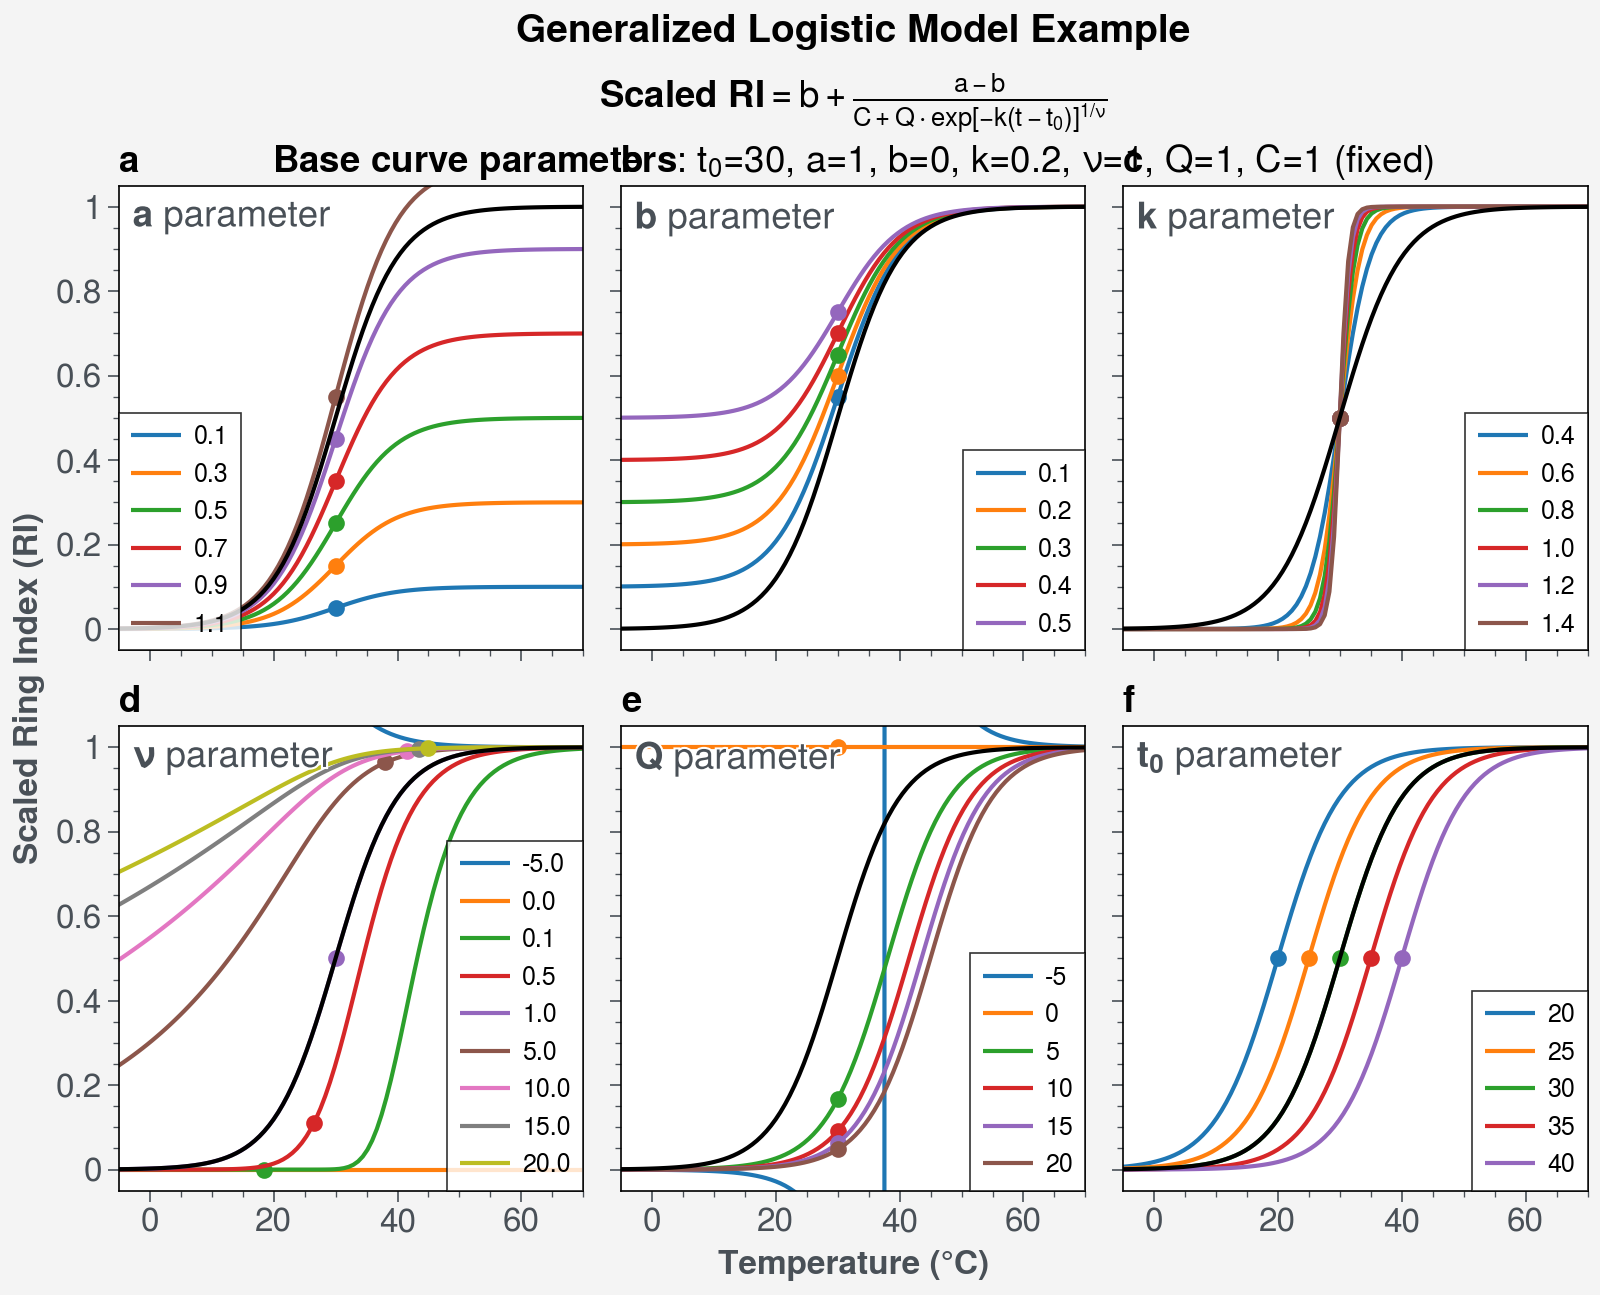

In [59]:
xx = np.linspace(-5,70,100)
sel_b = 0
sel_a = 1
sel_k = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30


fig, axs = plot.subplots(width=8,nrows=2,ncols=3,wspace=1.5)

### varying a --- upper asymptote
aa = np.arange(0.1, 1.2, 0.2)
for i, a in enumerate(aa):
    sel_c = plot.get_colors('tab10', len(aa))
    pred_y = generalized_logistic_model(
        b=sel_b,a=a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[0].plot(xx, pred_y, label=f'{a:.1f}', color=sel_c[i])
    axs[0].format(ultitle=r'$\bf{a}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[0].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='lower left', fontsize=10, ncols=1)

### varying b --- lower asymptote
bb = np.arange(0.1, 0.51, 0.1)
for i, b in enumerate(bb):
    sel_c = plot.get_colors('tab10', len(bb))
    pred_y = generalized_logistic_model(
        b=b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[1].plot(xx, pred_y, label=f'{b:.1f}', color=sel_c[i])
    axs[1].format(ultitle=r'$\bf{b}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[1].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

axs.format(
    ylim=(-0.05, 1.05),
)

### varying k --- growth rate/slope
kk = np.arange(0.4, 1.41, 0.2)
for i, k in enumerate(kk):
    sel_c = plot.get_colors('tab10', len(kk))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[2].plot(xx, pred_y, label=f'{k:.1f}', color=sel_c[i])
    axs[2].format(ultitle=r'$\bf{k}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[2].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

### varying nu --- shape/asymmetry parameter
VV = list(np.arange(-5, 20.1, 5)) + [0.1,0.5,1]
VV_sorted = np.array(sorted(VV))

for i, v in enumerate(VV_sorted):
    sel_c = plot.get_colors('tab10', len(VV))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[3].plot(xx, pred_y, label=f'{v:.1f}', color=sel_c[i])
    axs[3].format(ultitle=r'$\bf{\nu}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[3].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

### varying Q
QQ = np.arange(-5, 21, 5)
for i, q in enumerate(QQ):
    sel_c = plot.get_colors('tab10', len(QQ))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=q,C=1,
        x=xx,x0=sel_x0
    )
    axs[4].plot(xx, pred_y, label=f'{q:.0f}', color=sel_c[i])
    axs[4].format(ultitle=r'$\bf{Q}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[4].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[4].get_legend_handles_labels()
axs[4].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)




### Varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=x0
    )
    axs[5].plot(xx, pred_y, label=f'{x0}', color=sel_c[i])
    axs[5].format(ultitle=r'$\bf{t_{0}}$ parameter',titlesize=16,titlecolor='gray7',)

    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=x0
    )
    axs[5].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[5].get_legend_handles_labels()
axs[5].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)


##############################################################

sel_b = 0
sel_a = 1
sel_k = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30
pred_y = generalized_logistic_model(
    b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
    x=xx,x0=sel_x0
)

axs.plot(xx, pred_y, label='Generalized Logistic Model', color='k')
eq_str = r'$\bf{Scaled\ RI}$'+r'$ = b + \frac{a - b}{C + Q \cdot \exp[-k(t - t_{0})]^{1/\nu}}$'
text_str = r'$\bf{Base\ curve\ parameters}$: t$_{0}$='+f'{sel_x0}, a={sel_a}, b={sel_b}, k={sel_k}, '+r"$\nu$"+f'={sel_v}, Q={sel_q}, C=1 (fixed)'



axs[1].set_title(f'{eq_str}\n{text_str}', fontsize=10)

plot.rc['abc']=False
axs.format(
    abc=False,
    fontsize=12,labelsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    suptitle=f'Generalized Logistic Model Example',
    # ylim=(0, 1),
    grid=False,
    suptitlesize=14,
    xlabel='Temperature (°C)',
    ylabel='Scaled Ring Index (RI)',
    
)
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS5_generalized_logistic_model_example.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [60]:
gridded_combined_df.columns

Index(['match_lat_04deg', 'match_lon_04deg', 'regionName', 'reference_name',
       'datatype', 'Strains', 'organism_commonName', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'organism_broadClass4',
       'publicationYear', 'BIT', 'Latitude', 'Longitude', 'OPTiMAL_Dnearest',
       'OPTiMAL_SST', 'SST', 'TEX86', 'ZeroOverZeroCren', 'gdgt23ratio',
       'methaneIndex', 'modernWaterDepth', 'no3_sf2tc_avg', 'ringIndex',
       'scaledRI', 't_sf2tc_avg'],
      dtype='object')

coretop 0.05769607252797783
culture 0.10990008737543946
mesocosm 0.05599875193877125
coretop 0.06302240841716153
culture 0.12711185892035715
mesocosm 0.08502108982738295
coretop 0.06119218461802358
culture 0.11721303157534142
mesocosm 0.07626294310472352
coretop 0.056565828522109535
culture 0.11756698242499942
mesocosm 0.05896312453492991
coretop 0.06284910215159316
culture 0.12654567326106675
mesocosm 0.07873884876055716
coretop 0.06096164351308814
culture 0.11655894141373051
mesocosm 0.06803890563789623


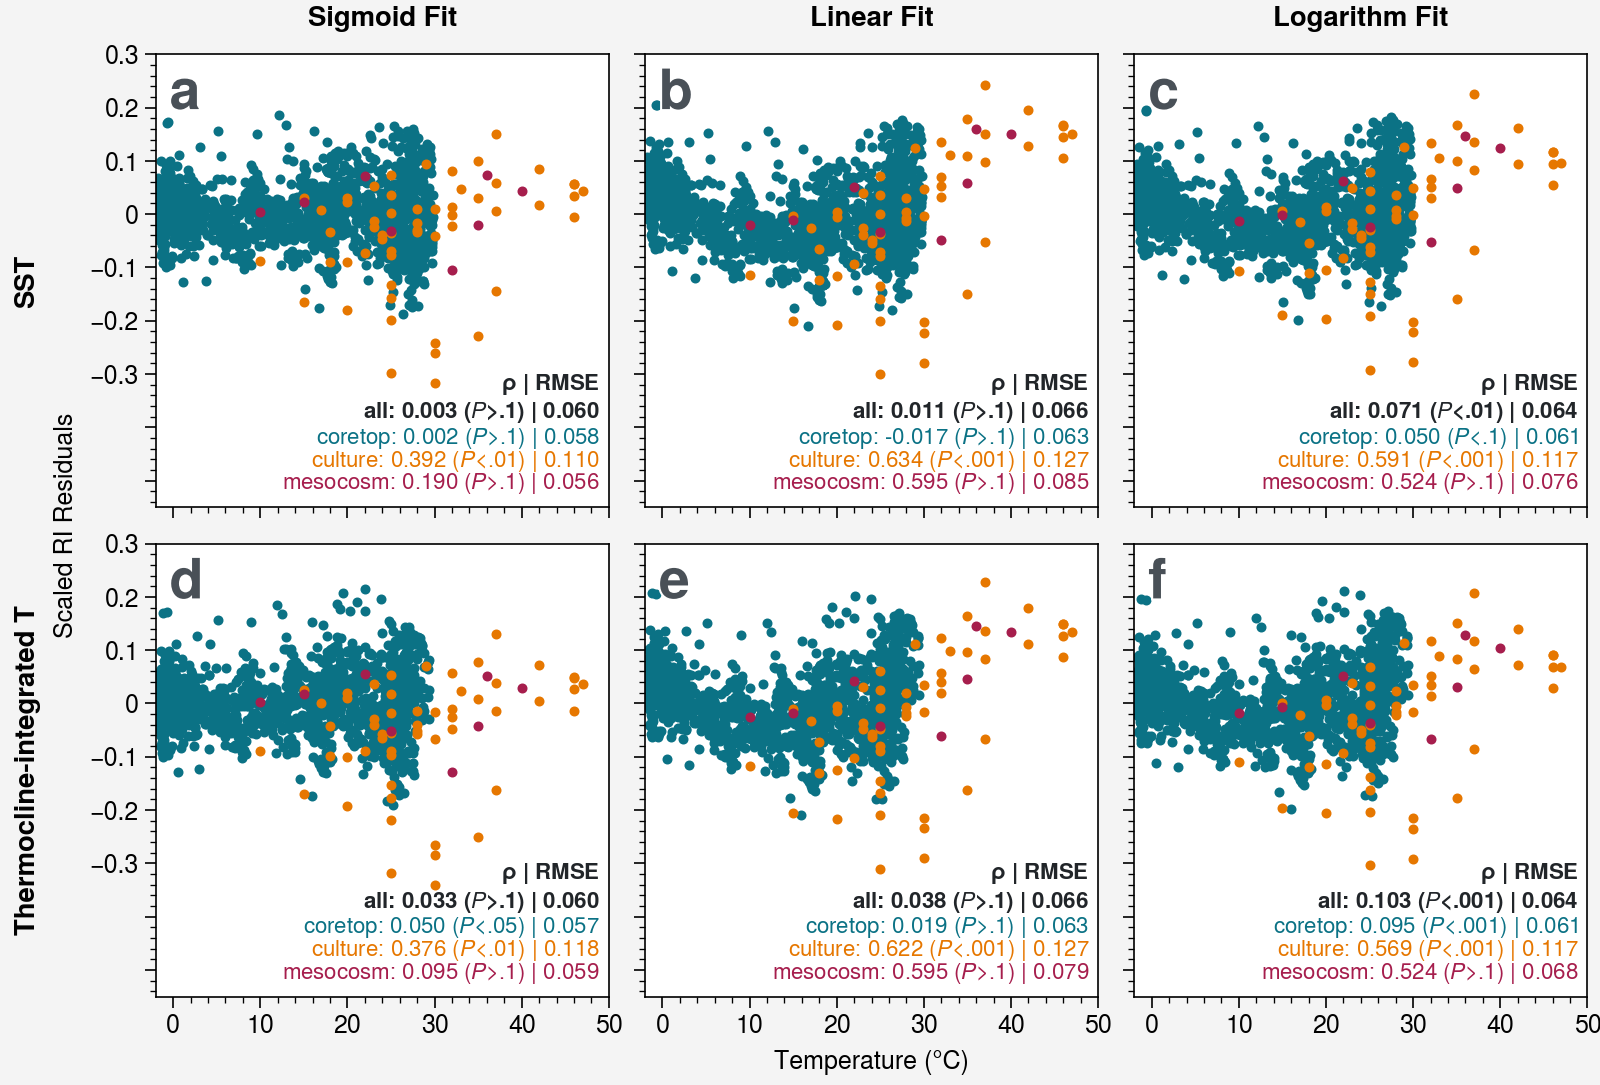

In [61]:
fig, axs = plot.subplots(nrows=2,ncols=3,width=8)
axs.format(
    collabels=['Sigmoid Fit','Linear Fit','Logarithm Fit'],
    rowlabels=['SST','Thermocline-integrated T']
)

temp_params = ['SST', 't_sf2tc_avg'] 
y_param = 'scaledRI'
func_dict = {
    'Sigmoid Fit': generalized_logistic_model_fixed_upper,
    'Linear Fit': linear_model,
    'Logarithm Fit': linear_model,
}

plot_data = gridded_combined_df
plot_data['no3_sf2tc_avg'] = [10 if n!='coretop' and np.isnan(x) else x for x,n in zip(plot_data['no3_sf2tc_avg'], plot_data['datatype'])]
plot_data = plot_data.dropna(subset=['TEX86','scaledRI','SST','t_sf2tc_avg','no3_sf2tc_avg'])
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

for i, temp_param in enumerate(temp_params):
    for j, (func_name, func) in enumerate(func_dict.items()):
        ax = axs[i,j]
        reg_data = plot_data[[temp_param,y_param,'datatype']].dropna(how='any')
        
        if func_name == 'Sigmoid Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],reg_data[y_param], 
                    p0=[20, 0.1, 0.2, 1, 1], 
                    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = func(x_fit, *popt)
            y_pred = func(reg_data[temp_param], *popt)
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
        elif func_name == 'Linear Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],reg_data[y_param], 
                    p0=[0.01, 0.1], 
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = func(x_fit, *popt)
            y_pred = func(reg_data[temp_param], *popt)
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
            
        elif func_name == 'Logarithm Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],np.log10(reg_data[y_param]), 
                    p0=[0.01, 0.1], 
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = 10**(func(x_fit, *popt))
            y_pred = 10**(func(reg_data[temp_param], *popt))
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
        
        reg_data[f'{y_param}_pred'] = y_pred
        reg_data[f'{y_param}_residual'] = y_res
        grouped = reg_data.groupby('datatype')
        for name, group in grouped:
            ax.scatter(group[temp_param], group[f'{y_param}_residual'], m='.', label=name,
                       c=datatype_color_dict.get(name,'gray7'))
            
            group_rmse = np.sqrt(np.mean(group[f'{y_param}_residual']**2))
            print(name, group_rmse)
            
            spearmanrho, spearman_pval = spearmanr(group[temp_param], group[f'{y_param}_residual'])
            pval_label = label_pvalues(spearman_pval)
            text = f'{name}: {spearmanrho:.3f} ({pval_label}) | {group_rmse:.3f}'
            ax.text(0.98, 0.18-(0.05*list(grouped.groups.keys()).index(name)), text, transform=ax.transAxes,
                ha='right', va='top',c=datatype_color_dict.get(name,'gray7'),
                fontsize=8)
        
        spearman_rho, spearman_pval = spearmanr(reg_data[temp_param], reg_data[f'{y_param}_residual'])
        pval_label = label_pvalues(spearman_pval)
        text = r'$\rho$ | RMSE'+f'\nall: {spearman_rho:.3f} ({pval_label}) | {rmse:.3f}'
        ax.text(0.98, 0.3, text, transform=ax.transAxes,
            ha='right', va='top',c='gray9',
            fontsize=8,fontweight='bold',)
        
axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False,
    xlabel='Temperature (°C)',
    ylabel='Scaled RI Residuals',
    ylim=(-0.55,0.3),
    ytickrange=(-0.3,0.3),
    xlim=(-2,50)
)
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS5_RI_residuals_sst_thermoT_comparison.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [62]:
def find_optimal_no3_threshold(no3_values, residuals, threshold_range=np.arange(0.5, 5, 0.01), 
                                min_points=5):
    """
    Find NO3 threshold that maximizes negative correlation with residuals.
    
    Parameters:
    -----------
    no3_values : array
        Nitrate concentrations
    residuals : array  
        Residuals from temperature-only model
    threshold_range : array
        Range of thresholds to test
    min_points : int
        Minimum number of points required for correlation
        
    Returns:
    --------
    optimal_threshold : float
        Threshold that gives most negative Spearman rho
    results_df : DataFrame
        Full results for all tested thresholds
    """
    results = []
    
    for threshold in threshold_range:
        # Select data below threshold
        below_threshold = no3_values <= threshold
        no3_subset = no3_values[below_threshold]
        resid_subset = residuals[below_threshold]
        
        # Remove NaN/Inf
        valid_idx = (np.isfinite(no3_subset) & 
                     np.isfinite(resid_subset) & 
                     (no3_subset > 0))  # Ensure positive for log
        
        no3_valid = no3_subset[valid_idx]
        resid_valid = resid_subset[valid_idx]
        
        if len(no3_valid) >= min_points:
            rho, pval = spearmanr(np.log10(no3_valid), resid_valid)
            results.append({
                'threshold': threshold,
                'spearman_rho': rho,
                'spearman_pval': pval,
                'n_points': len(no3_valid)
            })
    
    results_df = pd.DataFrame(results)
    optimal_threshold = results_df.loc[results_df['spearman_rho'].idxmin(), 'threshold']
    
    return optimal_threshold, results_df

In [63]:
# from scipy.spatial import cKDTree
# import numpy as np

# # idx_diff_tc_depth is 2D (lat, lon) with True where fronts exist
# print(f"Front mask shape: {idx_diff_tc_depth.shape}")
# print(f"Number of front gridpoints: {idx_diff_tc_depth.sum().values}")

# # Get the 2D lat/lon grids
# if ocean_prop_ds['lat'].ndim == 1:
#     # Create 2D meshgrid from 1D coordinates
#     lat_2d, lon_2d = np.meshgrid(
#         ocean_prop_ds['lat'].values,
#         ocean_prop_ds['lon'].values,
#         indexing='ij'
#     )
# else:
#     # Already 2D
#     lat_2d = ocean_prop_ds['lat'].values
#     lon_2d = ocean_prop_ds['lon'].values

# # Extract coordinates where fronts exist
# front_mask = idx_diff_tc_depth.values
# front_lats = lat_2d[front_mask]
# front_lons = lon_2d[front_mask]

# print(f"Number of front points: {len(front_lats)}")

# # Convert to Cartesian coordinates for accurate distance calculation
# def latlon_to_cartesian(lat, lon, R=6371):
#     """Convert lat/lon to 3D Cartesian coordinates."""
#     lat_rad = np.radians(lat)
#     lon_rad = np.radians(lon)
#     x = R * np.cos(lat_rad) * np.cos(lon_rad)
#     y = R * np.cos(lat_rad) * np.sin(lon_rad)
#     z = R * np.sin(lat_rad)
#     return np.column_stack([x, y, z]) if lat.ndim > 0 else np.array([x, y, z])

# # Front points in Cartesian coordinates
# front_xyz = latlon_to_cartesian(front_lats, front_lons)

# coretop_idx = combined_df_raw['datatype'] == 'coretop'
# # Coretop points in Cartesian coordinates
# core_xyz = latlon_to_cartesian(
#     combined_df_raw.loc[coretop_idx, 'Latitude'].values,
#     combined_df_raw.loc[coretop_idx, 'Longitude'].values
# )

# # Build KDTree and find nearest neighbor
# tree = cKDTree(front_xyz)
# distances_euclidean, nearest_indices = tree.query(core_xyz)

# # Convert chord distance to great circle distance
# R = 6371
# distances_km = 2 * R * np.arcsin(distances_euclidean / (2 * R))

# # Add to dataframe
# combined_df_raw.loc[coretop_idx, 'distance_to_tc_front_km'] = distances_km

# print(f"\nDistance statistics:")
# print(combined_df_raw.loc[coretop_idx, 'distance_to_tc_front_km'].describe())
# print(f"\nCoretops within 500 km of fronts: {(combined_df_raw.loc[coretop_idx, 'distance_to_tc_front_km'] < 500).sum()}")

Fitted parameters: [27.63531867  0.43077763  0.13405217  1.31761971  1.88163266]
1513 coretop samples used in regression
GDGT-2/3 ratio vs RI residuals:
Slope: -0.006, Intercept: 0.034, Spearman rho: -0.387, p-value: 2.698e-55, R²: 0.133
Optimal low_no3_threshold (RI-res): 1.8
Nitrate vs RI residuals (for no3 < optimal threshold):
Slope: -0.031, Intercept: -0.010, Spearman rho: -0.360, p-value: 1.790e-21, R²: 0.120

GDGT-2/3 vs NO3 correlation (NO3 < 1.80):
Spearman rho: -0.033, p-value: 3.940e-01, n=654


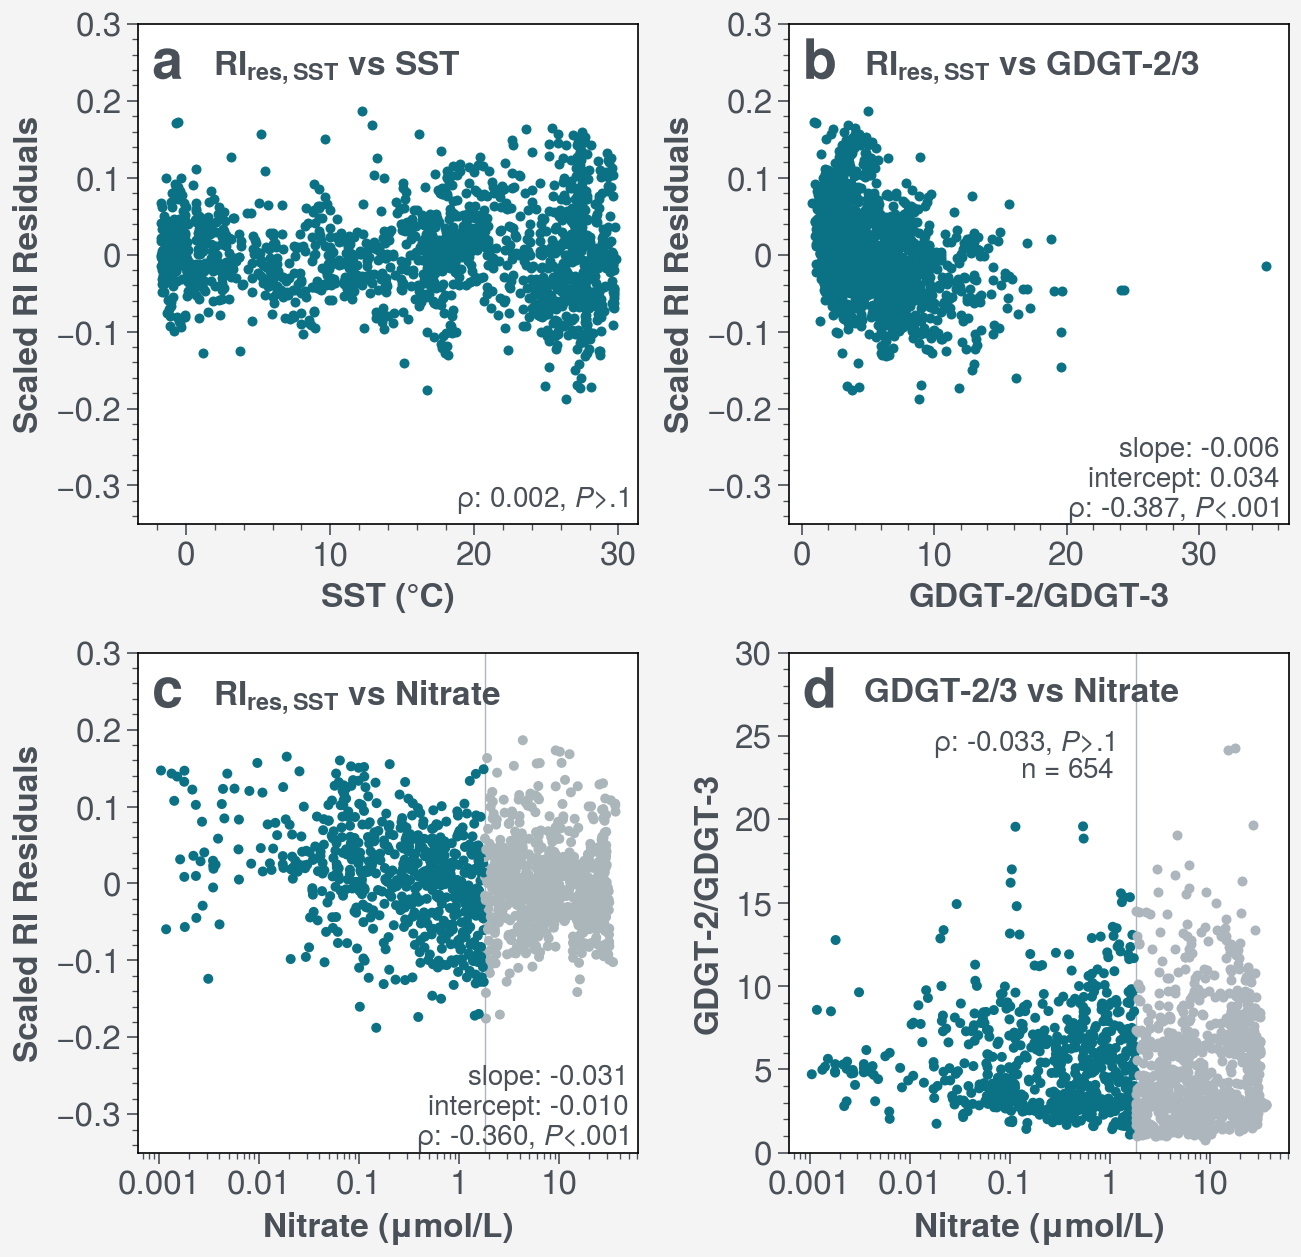

In [64]:
fig, axs = plot.subplots(ncols=2,nrows=2, share=0, )

x_param = 'SST'
y_param = 'scaledRI'

plot_data = gridded_combined_df.dropna(subset=[x_param, y_param, 'gdgt23ratio', 'no3_sf2tc_avg'])
nonnan_idx = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX = plot_data[x_param][nonnan_idx]
YY = plot_data[y_param][nonnan_idx]

popt, pcov = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX, YY, 
    p0=[20, 0.1, 0.2, 1, 1], 
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

print(f'Fitted parameters: {popt}')

plot_data['pred_'+y_param] = generalized_logistic_model_fixed_upper(plot_data[x_param], *popt)
plot_data[y_param+'_res'] = plot_data[y_param] - plot_data['pred_'+y_param]

####### plot RI_res vs t_sf2tc_avg ##########
ax = axs[0]
plot_x = plot_data[plot_data['datatype']=='coretop'][x_param]
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')
nonnan_idx = (~plot_data[plot_data['datatype']=='coretop'][x_param].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop'][x_param][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)
xx1 = np.linspace(-2,30,100).reshape(-1,1)
yy1 = reg_model.predict(xx1)
# ax.plot(xx1, yy1, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
text_lists = [
    # f'slope: {slope:.3f}',
    # f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.05-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)
    
text = 'RI$_{res, SST}$ vs SST'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='SST (°C)')
          
print(f'{len(reg_X)} coretop samples used in regression')

##############################
ax = axs[1]
plot_x = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')

nonnan_idx = (~plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)

xx2 = np.linspace(0,30,100).reshape(-1,1)
yy2 = reg_model.predict(xx2)
# ax.plot(xx2, yy2, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model.score(reg_X, reg_y)

print('GDGT-2/3 ratio vs RI residuals:')
print(f'Slope: {slope:.3f}, Intercept: {intercept:.3f}, Spearman rho: {spearman_rho:.3f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.3f}')

text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, SST}$ vs GDGT-2/3'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='GDGT-2/GDGT-3',)
##########################

ax = axs[2]
plot_x = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']

optimal_no3_threshold, threshold_results = find_optimal_no3_threshold(
    plot_x.values, 
    plot_y.values,
    threshold_range=np.arange(0.5, 5, 0.01)
)

low_no3_threshold = np.round(optimal_no3_threshold,1)
print(f'Optimal low_no3_threshold (RI-res): {low_no3_threshold}')

m = ax.scatter(plot_x, plot_y, 
               c=plot_x, 
               marker='.',
               levels=[0,low_no3_threshold,20],
               cmap=[datatype_color_dict.get('coretop','gray7'),'gray5'],
               )
ax.format(xscale='log',xticks=[0.0001,0.001,0.01,0.1,1,10,100],xtickminor=True)

### regression between no3 and scaledRI_res for data with no3 < low_no3_threshold
reg_data_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'].between(0,low_no3_threshold)
reg_X = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][reg_data_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][reg_data_idx].values
reg_log10X = np.log10(reg_X)
nonnan_noninf_idx = ~np.isnan(reg_log10X).flatten() & ~np.isinf(reg_log10X).flatten() & ~np.isnan(reg_y).flatten() & ~np.isinf(reg_y).flatten()

reg_X = reg_X[nonnan_noninf_idx]
reg_y = reg_y[nonnan_noninf_idx]
reg_model_no3_orig = LinearRegression().fit(np.log10(reg_X), reg_y)
reg_y_pred = reg_model_no3_orig.predict(np.log10(reg_X))
xx4 = np.linspace(0.0001,low_no3_threshold,100).reshape(-1,1)
yy4 = reg_model_no3_orig.predict(np.log10(xx4))
# ax.plot(xx4, yy4, c='k', label=f'linear fit for no3 < {low_no3_threshold}')
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

slope = reg_model_no3_orig.coef_[0]
intercept = reg_model_no3_orig.intercept_
spearman_rho, spearman_pval = spearmanr(np.log10(reg_X), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model_no3_orig.score(np.log10(reg_X), reg_y)
print('Nitrate vs RI residuals (for no3 < optimal threshold):')
print(f'Slope: {slope:.3f}, Intercept: {intercept:.3f}, Spearman rho: {spearman_rho:.3f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.3f}')

text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, SST}$ vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Nitrate (μmol/L)',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'],)

####### NEW PANEL: GDGT-2/3 vs NO3 correlation ##########
ax = axs[3]

# Get data for samples with NO3 < low_no3_threshold
corr_data_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'].between(0, low_no3_threshold)
plot_x_corr = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][corr_data_idx]
plot_y_corr = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][corr_data_idx]

# Color by nitrate threshold
m = ax.scatter(plot_x_corr, plot_y_corr, 
               c=plot_x_corr, 
               marker='.',
               levels=[0, low_no3_threshold, 20],
               cmap=[datatype_color_dict.get('coretop','gray7'), 'gray5'],
               )

# Also show excluded high-nitrate samples in gray
high_no3_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'] > low_no3_threshold
plot_x_high = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][high_no3_idx]
plot_y_high = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][high_no3_idx]
ax.scatter(plot_x_high, plot_y_high, c='gray5', marker='.')

ax.format(xscale='log', xticks=[0.0001,0.001,0.01,0.1,1,10,100], xtickminor=True)
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

# Calculate correlation for low-nitrate samples only
nonnan_idx_corr = (~plot_x_corr.isna()) & (~plot_y_corr.isna())
corr_X = plot_x_corr[nonnan_idx_corr].values
corr_Y = plot_y_corr[nonnan_idx_corr].values

# Remove any inf values from log transformation
valid_idx = ~np.isinf(np.log10(corr_X))
corr_X = corr_X[valid_idx]
corr_Y = corr_Y[valid_idx]

# Compute correlation
spearman_rho_corr, spearman_pval_corr = spearmanr(np.log10(corr_X), corr_Y)
pval_label_corr = label_pvalues(spearman_pval_corr)

print(f'\nGDGT-2/3 vs NO3 correlation (NO3 < {low_no3_threshold:.2f}):')
print(f'Spearman rho: {spearman_rho_corr:.3f}, p-value: {spearman_pval_corr:.3e}, n={len(corr_X)}')

# Optional: fit regression line for visualization
reg_model_corr = LinearRegression().fit(np.log10(corr_X).reshape(-1,1), corr_Y)
xx_corr = np.linspace(corr_X.min(), low_no3_threshold, 100).reshape(-1,1)
yy_corr = reg_model_corr.predict(np.log10(xx_corr))
# ax.plot(xx_corr, yy_corr, c='k', lw=1.5, alpha=0.5)

text_lists_corr = [
    r'$\rho$: '+f'{spearman_rho_corr:.3f}, {pval_label_corr}',
    f'$n$ = {len(corr_X)}'
]
for i, text in enumerate(text_lists_corr):
    ax.text(0.65, 0.85-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='top', c='gray7', fontsize=10)

text = 'GDGT-2/3 vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top', c='gray7', fontsize=12, fontweight='bold')
ax.format(xlabel='Nitrate (μmol/L)',
          ylabel='GDGT-2/GDGT-3',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'])

axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    fontsize=12, labelsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True,
    grid=False,
)

# Different ylim for panels a-c vs panel d
axs[:3].format(ylim=(-0.35, 0.3), ylabel='Scaled RI Residuals')
axs[3].format(ylim=(0, 30))


fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figS7a_residuals_vs_covariates_coretop_only_SST.pdf'

fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

Fitted parameters: [24.78605422  0.43791614  0.12725585  1.00712663  1.56431277]
1513 coretop samples used in regression
GDGT-2/3 ratio vs RI residuals:
Slope: -0.006, Intercept: 0.033, Spearman rho: -0.371, p-value: 1.469e-50, R²: 0.121
Optimal low_no3_threshold (RI-res): 1.8
Nitrate vs RI residuals (for no3 < optimal threshold):
Slope: -0.026, Intercept: -0.008, Spearman rho: -0.324, p-value: 1.814e-17, R²: 0.092

GDGT-2/3 vs NO3 correlation (NO3 < 1.80):
Spearman rho: -0.033, p-value: 3.940e-01, n=654


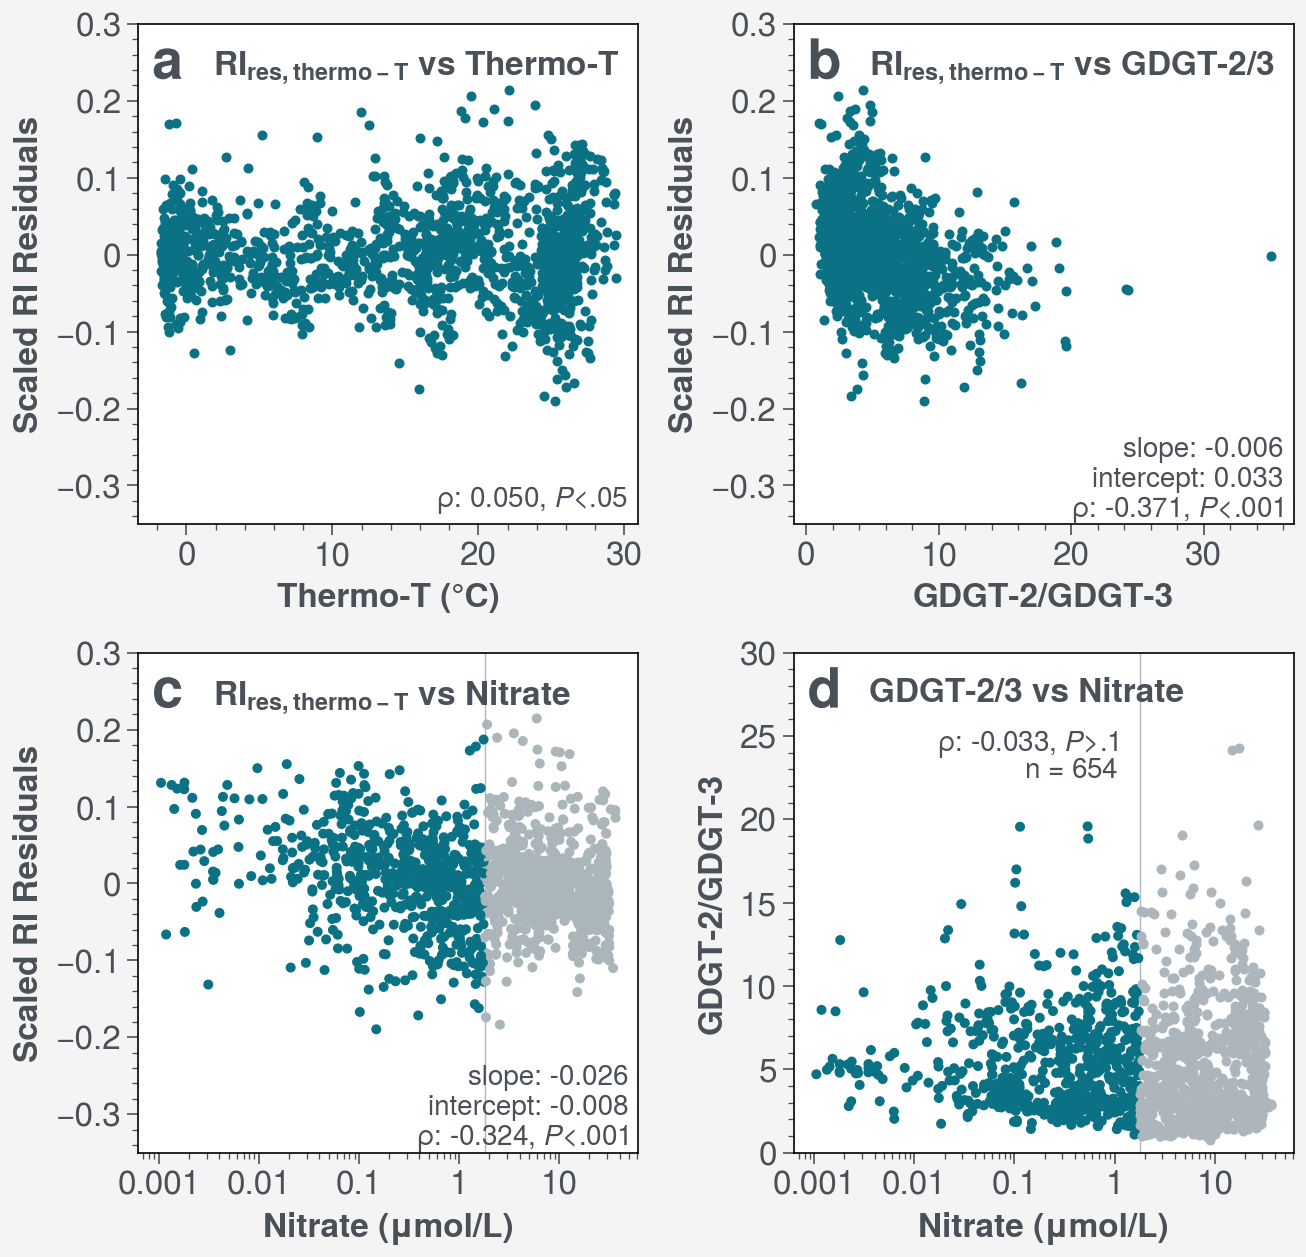

In [65]:
fig, axs = plot.subplots(ncols=2,nrows=2, share=0, )

x_param = 't_sf2tc_avg'
y_param = 'scaledRI'

plot_data = gridded_combined_df.dropna(subset=[x_param, y_param, 'gdgt23ratio', 'no3_sf2tc_avg'])
nonnan_idx = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX = plot_data[x_param][nonnan_idx]
YY = plot_data[y_param][nonnan_idx]

popt, pcov = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX, YY, 
    p0=[20, 0.1, 0.2, 1, 1], 
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

print(f'Fitted parameters: {popt}')

plot_data['pred_'+y_param] = generalized_logistic_model_fixed_upper(plot_data[x_param], *popt)
plot_data[y_param+'_res'] = plot_data[y_param] - plot_data['pred_'+y_param]

####### plot RI_res vs t_sf2tc_avg ##########
ax = axs[0]
plot_x = plot_data[plot_data['datatype']=='coretop'][x_param]
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')
nonnan_idx = (~plot_data[plot_data['datatype']=='coretop'][x_param].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop'][x_param][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)
xx1 = np.linspace(-2,30,100).reshape(-1,1)
yy1 = reg_model.predict(xx1)
# ax.plot(xx1, yy1, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
text_lists = [
    # f'slope: {slope:.3f}',
    # f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.05-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)
    
text = 'RI$_{res, thermo-T}$ vs Thermo-T'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Thermo-T (°C)')
          
print(f'{len(reg_X)} coretop samples used in regression')

##############################
ax = axs[1]
plot_x = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')

nonnan_idx = (~plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)

xx2 = np.linspace(0,30,100).reshape(-1,1)
yy2 = reg_model.predict(xx2)
# ax.plot(xx2, yy2, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model.score(reg_X, reg_y)

print('GDGT-2/3 ratio vs RI residuals:')
print(f'Slope: {slope:.3f}, Intercept: {intercept:.3f}, Spearman rho: {spearman_rho:.3f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.3f}')

text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, thermo-T}$ vs GDGT-2/3'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='GDGT-2/GDGT-3',)
##########################

ax = axs[2]
plot_x = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']

optimal_no3_threshold, threshold_results = find_optimal_no3_threshold(
    plot_x.values, 
    plot_y.values,
    threshold_range=np.arange(0.5, 5, 0.01)
)

low_no3_threshold = np.round(optimal_no3_threshold,1)
print(f'Optimal low_no3_threshold (RI-res): {low_no3_threshold}')

m = ax.scatter(plot_x, plot_y, 
               c=plot_x, 
               marker='.',
               levels=[0,low_no3_threshold,20],
               cmap=[datatype_color_dict.get('coretop','gray7'),'gray5'],
               )
ax.format(xscale='log',xticks=[0.0001,0.001,0.01,0.1,1,10,100],xtickminor=True)

### regression between no3 and scaledRI_res for data with no3 < low_no3_threshold
reg_data_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'].between(0,low_no3_threshold)
reg_X = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][reg_data_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][reg_data_idx].values
reg_log10X = np.log10(reg_X)
nonnan_noninf_idx = ~np.isnan(reg_log10X).flatten() & ~np.isinf(reg_log10X).flatten() & ~np.isnan(reg_y).flatten() & ~np.isinf(reg_y).flatten()

reg_X = reg_X[nonnan_noninf_idx]
reg_y = reg_y[nonnan_noninf_idx]
reg_model_no3_orig = LinearRegression().fit(np.log10(reg_X), reg_y)
reg_y_pred = reg_model_no3_orig.predict(np.log10(reg_X))
xx4 = np.linspace(0.0001,low_no3_threshold,100).reshape(-1,1)
yy4 = reg_model_no3_orig.predict(np.log10(xx4))
# ax.plot(xx4, yy4, c='k', label=f'linear fit for no3 < {low_no3_threshold}')
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

slope = reg_model_no3_orig.coef_[0]
intercept = reg_model_no3_orig.intercept_
spearman_rho, spearman_pval = spearmanr(np.log10(reg_X), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model_no3_orig.score(np.log10(reg_X), reg_y)
print('Nitrate vs RI residuals (for no3 < optimal threshold):')
print(f'Slope: {slope:.3f}, Intercept: {intercept:.3f}, Spearman rho: {spearman_rho:.3f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.3f}')

text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, thermo-T}$ vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Nitrate (μmol/L)',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'],)

####### NEW PANEL: GDGT-2/3 vs NO3 correlation ##########
ax = axs[3]

# Get data for samples with NO3 < low_no3_threshold
corr_data_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'].between(0, low_no3_threshold)
plot_x_corr = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][corr_data_idx]
plot_y_corr = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][corr_data_idx]

# Color by nitrate threshold
m = ax.scatter(plot_x_corr, plot_y_corr, 
               c=plot_x_corr, 
               marker='.',
               levels=[0, low_no3_threshold, 20],
               cmap=[datatype_color_dict.get('coretop','gray7'), 'gray5'],
               )

# Also show excluded high-nitrate samples in gray
high_no3_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'] > low_no3_threshold
plot_x_high = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][high_no3_idx]
plot_y_high = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][high_no3_idx]
ax.scatter(plot_x_high, plot_y_high, c='gray5', marker='.')

ax.format(xscale='log', xticks=[0.0001,0.001,0.01,0.1,1,10,100], xtickminor=True)
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

# Calculate correlation for low-nitrate samples only
nonnan_idx_corr = (~plot_x_corr.isna()) & (~plot_y_corr.isna())
corr_X = plot_x_corr[nonnan_idx_corr].values
corr_Y = plot_y_corr[nonnan_idx_corr].values

# Remove any inf values from log transformation
valid_idx = ~np.isinf(np.log10(corr_X))
corr_X = corr_X[valid_idx]
corr_Y = corr_Y[valid_idx]

# Compute correlation
spearman_rho_corr, spearman_pval_corr = spearmanr(np.log10(corr_X), corr_Y)
pval_label_corr = label_pvalues(spearman_pval_corr)

print(f'\nGDGT-2/3 vs NO3 correlation (NO3 < {low_no3_threshold:.2f}):')
print(f'Spearman rho: {spearman_rho_corr:.3f}, p-value: {spearman_pval_corr:.3e}, n={len(corr_X)}')

# Optional: fit regression line for visualization
reg_model_corr = LinearRegression().fit(np.log10(corr_X).reshape(-1,1), corr_Y)
xx_corr = np.linspace(corr_X.min(), low_no3_threshold, 100).reshape(-1,1)
yy_corr = reg_model_corr.predict(np.log10(xx_corr))
# ax.plot(xx_corr, yy_corr, c='k', lw=1.5, alpha=0.5)

text_lists_corr = [
    r'$\rho$: '+f'{spearman_rho_corr:.3f}, {pval_label_corr}',
    f'$n$ = {len(corr_X)}'
]
for i, text in enumerate(text_lists_corr):
    ax.text(0.65, 0.85-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='top', c='gray7', fontsize=10)

text = 'GDGT-2/3 vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top', c='gray7', fontsize=12, fontweight='bold')
ax.format(xlabel='Nitrate (μmol/L)',
          ylabel='GDGT-2/GDGT-3',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'])

axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    fontsize=12, labelsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True,
    grid=False,
)

# Different ylim for panels a-c vs panel d
axs[:3].format(ylim=(-0.35, 0.3), ylabel='Scaled RI Residuals')
axs[3].format(ylim=(0, 30))


fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figS7b_residuals_vs_covariates_coretop_only_thermoT.pdf'

fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [66]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats

# Assuming 'gridded_combined_df' and 'generalized_logistic_model_fixed_upper' are already defined
# and 'find_optimal_no3_threshold' is available.

x_param = 't_sf2tc_avg'
y_param = 'scaledRI'

# --- DATA PREPARATION ---
plot_data = gridded_combined_df.copy()
# Fill NaNs for non-coretop data so they don't get dropped unnecessarily
plot_data['no3_sf2tc_avg'] = [10 if n!='coretop' and np.isnan(x) else x for x,n in zip(plot_data['no3_sf2tc_avg'], plot_data['datatype'])]

# Drop rows missing ANY potential predictor
plot_data = plot_data.dropna(subset=[x_param,y_param,'TEX86','no3_sf2tc_avg'])
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

# --- 1. GLOBAL TEMPERATURE CALIBRATION ---
nonnan_idx_global = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX_temp_global = plot_data[x_param][nonnan_idx_global].values
YY_global = plot_data[y_param][nonnan_idx_global].values

popt_T_global, _ = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX_temp_global, YY_global,
    p0=[20, 0.1, 0.2, 1, 1],
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

# Global stats
pred_RI_T_global = generalized_logistic_model_fixed_upper(XX_temp_global, *popt_T_global)
r2_T_global = 1 - np.sum((YY_global - pred_RI_T_global)**2) / np.sum((YY_global - np.mean(YY_global))**2)
rmse_T_global = np.sqrt(np.mean((YY_global - pred_RI_T_global)**2))

print(f"Global Temperature Calibration (n={len(YY_global)}):")
print(f"  R² = {r2_T_global:.3f}")
print(f"  RMSE = {rmse_T_global:.3f}")
print(f"  Params: {popt_T_global}")


# --- 2. CORETOP ANALYSIS & OPTIMIZATION ---
# Isolate Coretop Data
coretop_mask = (plot_data['datatype'] == 'coretop')
XX_coretop_temp = plot_data[x_param][coretop_mask].values
XX_coretop_gdgt23 = plot_data['gdgt23ratio'][coretop_mask].values
XX_coretop_no3 = plot_data['no3_sf2tc_avg'][coretop_mask].values
YY_coretop = plot_data[y_param][coretop_mask].values
n_coretop = len(YY_coretop)

# Prepare Master Input Matrix [Temp, GDGT, NO3]
X_coretop_matrix = np.column_stack([XX_coretop_temp, XX_coretop_gdgt23, XX_coretop_no3])

# Calculate T-only residuals for threshold finding
pred_RI_T_coretop = generalized_logistic_model_fixed_upper(XX_coretop_temp, *popt_T_global)
resid_RI_T_coretop = YY_coretop - pred_RI_T_coretop

# Optimal Threshold Finding
optimal_no3_threshold, _ = find_optimal_no3_threshold(
    XX_coretop_no3, 
    resid_RI_T_coretop,
    threshold_range=np.arange(0.5, 5, 0.01)
)
optimal_no3_threshold = np.round(optimal_no3_threshold,1)
print(f"\nOptimal NO3 threshold: {optimal_no3_threshold:.1f} μmol/L")

# --- MASTER MULTIVARIATE FUNCTION ---
def multivariate_frequentist_model(X, x0, b, k, v, Q, betaG23=0, betaNO3=0, threshold=1.7):
    """
    Consolidated model function.
    X: (N, 3) array [Temp, GDGT23, NO3]
    """
    if X.ndim == 1: X = X.reshape(1, -1)
    
    t, gdgt23, no3 = X[:, 0], X[:, 1], X[:, 2]
    
    # 1. Base Temp
    pred = generalized_logistic_model_fixed_upper(t, x0, b, k, v, Q)
    
    # 2. GDGT
    pred += betaG23 * gdgt23
    
    # 3. Nitrate (Conditional & Zero-Anchored)
    if betaNO3 != 0:
        no3_term = np.zeros_like(no3)
        mask = (no3 > 0) & (no3 < threshold)
        no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
        pred += no3_term
        
    return pred


# --- MODEL FITTING WRAPPERS ---
# These wrappers allow us to fit only specific betas while holding T params fixed

# A. Univariate (T-Only) on Coretop
pred_T = multivariate_frequentist_model(X_coretop_matrix, *popt_T_global, betaG23=0, betaNO3=0)

# B. Bivariate (T + GDGT)
def fit_wrapper_gdgt(X, beta_gdgt):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=beta_gdgt, betaNO3=0, threshold=optimal_no3_threshold)

popt_gdgt, pcov_gdgt = curve_fit(fit_wrapper_gdgt, X_coretop_matrix, YY_coretop, p0=[-0.01], bounds=([-0.2], [0]))
pred_gdgt = fit_wrapper_gdgt(X_coretop_matrix, *popt_gdgt)

# C. Bivariate (T + NO3)
def fit_wrapper_no3(X, beta_no3):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=0, betaNO3=beta_no3, threshold=optimal_no3_threshold)

popt_no3, pcov_no3 = curve_fit(fit_wrapper_no3, X_coretop_matrix, YY_coretop, p0=[-0.01], bounds=([-0.2], [0]))
pred_no3 = fit_wrapper_no3(X_coretop_matrix, *popt_no3)

# D. Multivariate (Full)
def fit_wrapper_full(X, beta_gdgt, beta_no3):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=beta_gdgt, betaNO3=beta_no3, threshold=optimal_no3_threshold)

popt_full, pcov_full = curve_fit(fit_wrapper_full, X_coretop_matrix, YY_coretop, p0=[-0.01, -0.01], bounds=([-0.2, -0.2], [0, 0]))
pred_full = fit_wrapper_full(X_coretop_matrix, *popt_full)


# --- STATISTICS & OUTPUT ---

def calc_stats(y_true, y_pred, n_params):
    resid = y_true - y_pred
    rss = np.sum(resid**2)
    r2 = 1 - rss / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(resid**2))
    return r2, rmse, rss

# Calculate stats for all models
r2_T, rmse_T, rss_T = calc_stats(YY_coretop, pred_T, 0)
r2_G, rmse_G, rss_G = calc_stats(YY_coretop, pred_gdgt, 1)
r2_N, rmse_N, rss_N = calc_stats(YY_coretop, pred_no3, 1)
r2_F, rmse_F, rss_F = calc_stats(YY_coretop, pred_full, 2)

# F-tests
def f_test(rss_reduced, rss_full, k_reduced, k_full, n):
    df_num = k_full - k_reduced
    df_den = n - k_full - 1
    f_stat = ((rss_reduced - rss_full) / df_num) / (rss_full / df_den)
    p_val = 1 - stats.f.cdf(f_stat, df_num, df_den)
    return f_stat, p_val

f_G, p_G = f_test(rss_T, rss_G, 0, 1, n_coretop)
f_N, p_N = f_test(rss_T, rss_N, 0, 1, n_coretop)
f_F, p_F = f_test(rss_T, rss_F, 0, 2, n_coretop)

# Variance Partitioning
unique_gdgt = r2_F - r2_N
unique_no3 = r2_F - r2_G

# --- CI Calculations ---
# 1. Bivariate CIs
ci_gdgt = 1.96 * np.sqrt(np.diag(pcov_gdgt))
ci_no3 = 1.96 * np.sqrt(np.diag(pcov_no3))

# 2. Multivariate CIs
ci_full = 1.96 * np.sqrt(np.diag(pcov_full))

# --- FINAL TABLE PRINTS ---
print(f"\n" + "="*80)
print(f"VARIANCE PARTITIONING (Coretop only; n={n_coretop}):")
print("="*80)
print(f"{'Model':<25} {'R²':>8} {'ΔR²':>8} {'RMSE':>8} {'F-stat':>8} {'p-value':>10}")
print("-"*80)
print(f"{'Global T (fixed)':<25} {r2_T:>8.3f} {'--':>8} {rmse_T:>8.3f} {'--':>8} {'--':>10}")
print(f"{'+ GDGT-2/3':<25} {r2_G:>8.3f} {r2_G-r2_T:>8.3f} {rmse_G:>8.3f} {f_G:>8.2f} {p_G:>10.2e}")
print(f"{'+ NO3':<25} {r2_N:>8.3f} {r2_N-r2_T:>8.3f} {rmse_N:>8.3f} {f_N:>8.2f} {p_N:>10.2e}")
print(f"{'+ Both':<25} {r2_F:>8.3f} {r2_F-r2_T:>8.3f} {rmse_F:>8.3f} {f_F:>8.2f} {p_F:>10.2e}")
print("-"*80)
print(f"\nUnique contributions:")
print(f"  GDGT-2/3 (unique):       {unique_gdgt:.3f}  ({100*unique_gdgt:.2f}%)")
print(f"  NO3 (unique):            {unique_no3:.3f}  ({100*unique_no3:.2f}%)")

print(f"\n" + "="*80)
print(f"MODEL COEFFICIENTS (Beta values)")
print("="*80)
print(f"{'Predictor':<20} {'Bivariate Coeff (95% CI)':<30} {'Multivariate Coeff (95% CI)':<30}")
print("-"*80)
print(f"{'GDGT-2/3':<20} {popt_gdgt[0]:.4f} ± {ci_gdgt[0]:.4f}{'':<14} {popt_full[0]:.4f} ± {ci_full[0]:.4f}")
print(f"{'log10(NO3)':<20} {popt_no3[0]:.4f} ± {ci_no3[0]:.4f}{'':<14} {popt_full[1]:.4f} ± {ci_full[1]:.4f}")
print("-"*80)

Global Temperature Calibration (n=1576):
  R² = 0.728
  RMSE = 0.060
  Params: [24.7862395   0.43791614  0.12725586  1.00712668  1.56427598]

Optimal NO3 threshold: 1.8 μmol/L

VARIANCE PARTITIONING (Coretop only; n=1513):
Model                           R²      ΔR²     RMSE   F-stat    p-value
--------------------------------------------------------------------------------
Global T (fixed)             0.730       --    0.057       --         --
+ GDGT-2/3                   0.737    0.007    0.056    38.30   7.78e-10
+ NO3                        0.744    0.014    0.055    83.83   1.11e-16
+ Both                       0.763    0.033    0.053   105.39   1.11e-16
--------------------------------------------------------------------------------

Unique contributions:
  GDGT-2/3 (unique):       0.019  (1.89%)
  NO3 (unique):            0.026  (2.64%)

MODEL COEFFICIENTS (Beta values)
Predictor            Bivariate Coeff (95% CI)       Multivariate Coeff (95% CI)   
--------------------------

In [67]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats

# Assuming 'gridded_combined_df' and 'generalized_logistic_model_fixed_upper' are already defined
# and 'find_optimal_no3_threshold' is available.

x_param = 'SST'
y_param = 'scaledRI'

# --- DATA PREPARATION ---
plot_data = gridded_combined_df.copy()
# Fill NaNs for non-coretop data so they don't get dropped unnecessarily
plot_data['no3_sf2tc_avg'] = [10 if n!='coretop' and np.isnan(x) else x for x,n in zip(plot_data['no3_sf2tc_avg'], plot_data['datatype'])]

# Drop rows missing ANY potential predictor
plot_data = plot_data.dropna(subset=[x_param,y_param,'TEX86','no3_sf2tc_avg'])
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

# --- 1. GLOBAL TEMPERATURE CALIBRATION ---
nonnan_idx_global = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX_temp_global = plot_data[x_param][nonnan_idx_global].values
YY_global = plot_data[y_param][nonnan_idx_global].values

popt_T_global, _ = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX_temp_global, YY_global,
    p0=[20, 0.1, 0.2, 1, 1],
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

# Global stats
pred_RI_T_global = generalized_logistic_model_fixed_upper(XX_temp_global, *popt_T_global)
r2_T_global = 1 - np.sum((YY_global - pred_RI_T_global)**2) / np.sum((YY_global - np.mean(YY_global))**2)
rmse_T_global = np.sqrt(np.mean((YY_global - pred_RI_T_global)**2))

print(f"Global Temperature Calibration (n={len(YY_global)}):")
print(f"  R² = {r2_T_global:.3f}")
print(f"  RMSE = {rmse_T_global:.3f}")
print(f"  Params: {popt_T_global}")


# --- 2. CORETOP ANALYSIS & OPTIMIZATION ---
# Isolate Coretop Data
coretop_mask = (plot_data['datatype'] == 'coretop')
XX_coretop_temp = plot_data[x_param][coretop_mask].values
XX_coretop_gdgt23 = plot_data['gdgt23ratio'][coretop_mask].values
XX_coretop_no3 = plot_data['no3_sf2tc_avg'][coretop_mask].values
YY_coretop = plot_data[y_param][coretop_mask].values
n_coretop = len(YY_coretop)

# Prepare Master Input Matrix [Temp, GDGT, NO3]
X_coretop_matrix = np.column_stack([XX_coretop_temp, XX_coretop_gdgt23, XX_coretop_no3])

# Calculate T-only residuals for threshold finding
pred_RI_T_coretop = generalized_logistic_model_fixed_upper(XX_coretop_temp, *popt_T_global)
resid_RI_T_coretop = YY_coretop - pred_RI_T_coretop

# Optimal Threshold Finding
optimal_no3_threshold, _ = find_optimal_no3_threshold(
    XX_coretop_no3, 
    resid_RI_T_coretop,
    threshold_range=np.arange(0.5, 5, 0.01)
)
optimal_no3_threshold = np.round(optimal_no3_threshold,1)
print(f"\nOptimal NO3 threshold: {optimal_no3_threshold:.1f} μmol/L")

# --- MASTER MULTIVARIATE FUNCTION ---
def multivariate_frequentist_model(X, x0, b, k, v, Q, betaG23=0, betaNO3=0, threshold=1.7):
    """
    Consolidated model function.
    X: (N, 3) array [Temp, GDGT23, NO3]
    """
    if X.ndim == 1: X = X.reshape(1, -1)
    
    t, gdgt23, no3 = X[:, 0], X[:, 1], X[:, 2]
    
    # 1. Base Temp
    pred = generalized_logistic_model_fixed_upper(t, x0, b, k, v, Q)
    
    # 2. GDGT
    pred += betaG23 * gdgt23
    
    # 3. Nitrate (Conditional & Zero-Anchored)
    if betaNO3 != 0:
        no3_term = np.zeros_like(no3)
        mask = (no3 > 0) & (no3 < threshold)
        no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
        pred += no3_term
        
    return pred


# --- MODEL FITTING WRAPPERS ---
# These wrappers allow us to fit only specific betas while holding T params fixed

# A. Univariate (T-Only) on Coretop
pred_T = multivariate_frequentist_model(X_coretop_matrix, *popt_T_global, betaG23=0, betaNO3=0)

# B. Bivariate (T + GDGT)
def fit_wrapper_gdgt(X, beta_gdgt):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=beta_gdgt, betaNO3=0, threshold=optimal_no3_threshold)

popt_gdgt, pcov_gdgt = curve_fit(fit_wrapper_gdgt, X_coretop_matrix, YY_coretop, p0=[-0.01], bounds=([-0.2], [0]))
pred_gdgt = fit_wrapper_gdgt(X_coretop_matrix, *popt_gdgt)

# C. Bivariate (T + NO3)
def fit_wrapper_no3(X, beta_no3):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=0, betaNO3=beta_no3, threshold=optimal_no3_threshold)

popt_no3, pcov_no3 = curve_fit(fit_wrapper_no3, X_coretop_matrix, YY_coretop, p0=[-0.01], bounds=([-0.2], [0]))
pred_no3 = fit_wrapper_no3(X_coretop_matrix, *popt_no3)

# D. Multivariate (Full)
def fit_wrapper_full(X, beta_gdgt, beta_no3):
    return multivariate_frequentist_model(X, *popt_T_global, betaG23=beta_gdgt, betaNO3=beta_no3, threshold=optimal_no3_threshold)

popt_full, pcov_full = curve_fit(fit_wrapper_full, X_coretop_matrix, YY_coretop, p0=[-0.01, -0.01], bounds=([-0.2, -0.2], [0, 0]))
pred_full = fit_wrapper_full(X_coretop_matrix, *popt_full)


# --- STATISTICS & OUTPUT ---

def calc_stats(y_true, y_pred, n_params):
    resid = y_true - y_pred
    rss = np.sum(resid**2)
    r2 = 1 - rss / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(resid**2))
    return r2, rmse, rss

# Calculate stats for all models
r2_T, rmse_T, rss_T = calc_stats(YY_coretop, pred_T, 0)
r2_G, rmse_G, rss_G = calc_stats(YY_coretop, pred_gdgt, 1)
r2_N, rmse_N, rss_N = calc_stats(YY_coretop, pred_no3, 1)
r2_F, rmse_F, rss_F = calc_stats(YY_coretop, pred_full, 2)

# F-tests
def f_test(rss_reduced, rss_full, k_reduced, k_full, n):
    df_num = k_full - k_reduced
    df_den = n - k_full - 1
    f_stat = ((rss_reduced - rss_full) / df_num) / (rss_full / df_den)
    p_val = 1 - stats.f.cdf(f_stat, df_num, df_den)
    return f_stat, p_val

f_G, p_G = f_test(rss_T, rss_G, 0, 1, n_coretop)
f_N, p_N = f_test(rss_T, rss_N, 0, 1, n_coretop)
f_F, p_F = f_test(rss_T, rss_F, 0, 2, n_coretop)

# Variance Partitioning
unique_gdgt = r2_F - r2_N
unique_no3 = r2_F - r2_G

# --- CI Calculations ---
# 1. Bivariate CIs
ci_gdgt = 1.96 * np.sqrt(np.diag(pcov_gdgt))
ci_no3 = 1.96 * np.sqrt(np.diag(pcov_no3))

# 2. Multivariate CIs
ci_full = 1.96 * np.sqrt(np.diag(pcov_full))

# --- FINAL TABLE PRINTS ---
print(f"\n" + "="*80)
print(f"VARIANCE PARTITIONING (Coretop only; n={n_coretop}):")
print("="*80)
print(f"{'Model':<25} {'R²':>8} {'ΔR²':>8} {'RMSE':>8} {'F-stat':>8} {'p-value':>10}")
print("-"*80)
print(f"{'Global T (fixed)':<25} {r2_T:>8.3f} {'--':>8} {rmse_T:>8.3f} {'--':>8} {'--':>10}")
print(f"{'+ GDGT-2/3':<25} {r2_G:>8.3f} {r2_G-r2_T:>8.3f} {rmse_G:>8.3f} {f_G:>8.2f} {p_G:>10.2e}")
print(f"{'+ NO3':<25} {r2_N:>8.3f} {r2_N-r2_T:>8.3f} {rmse_N:>8.3f} {f_N:>8.2f} {p_N:>10.2e}")
print(f"{'+ Both':<25} {r2_F:>8.3f} {r2_F-r2_T:>8.3f} {rmse_F:>8.3f} {f_F:>8.2f} {p_F:>10.2e}")
print("-"*80)
print(f"\nUnique contributions:")
print(f"  GDGT-2/3 (unique):       {unique_gdgt:.3f}  ({100*unique_gdgt:.2f}%)")
print(f"  NO3 (unique):            {unique_no3:.3f}  ({100*unique_no3:.2f}%)")

print(f"\n" + "="*80)
print(f"MODEL COEFFICIENTS (Beta values)")
print("="*80)
print(f"{'Predictor':<20} {'Bivariate Coeff (95% CI)':<30} {'Multivariate Coeff (95% CI)':<30}")
print("-"*80)
print(f"{'GDGT-2/3':<20} {popt_gdgt[0]:.4f} ± {ci_gdgt[0]:.4f}{'':<14} {popt_full[0]:.4f} ± {ci_full[0]:.4f}")
print(f"{'log10(NO3)':<20} {popt_no3[0]:.4f} ± {ci_no3[0]:.4f}{'':<14} {popt_full[1]:.4f} ± {ci_full[1]:.4f}")
print("-"*80)

Global Temperature Calibration (n=1576):
  R² = 0.723
  RMSE = 0.060
  Params: [27.6354096   0.43077762  0.13405218  1.31761992  1.88161024]

Optimal NO3 threshold: 1.8 μmol/L

VARIANCE PARTITIONING (Coretop only; n=1513):
Model                           R²      ΔR²     RMSE   F-stat    p-value
--------------------------------------------------------------------------------
Global T (fixed)             0.719       --    0.058       --         --
+ GDGT-2/3                   0.728    0.009    0.057    48.70   4.45e-12
+ NO3                        0.738    0.019    0.056   109.33   1.11e-16
+ Both                       0.763    0.044    0.053   139.87   1.11e-16
--------------------------------------------------------------------------------

Unique contributions:
  GDGT-2/3 (unique):       0.025  (2.49%)
  NO3 (unique):            0.035  (3.51%)

MODEL COEFFICIENTS (Beta values)
Predictor            Bivariate Coeff (95% CI)       Multivariate Coeff (95% CI)   
--------------------------

In [68]:
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = 'ds_gridded_screened_global_compilation_finalized'

gridded_combined_df.to_csv(os.path.join(fpath, fname + '.csv'), index=False)